# Library

In [1]:
import pandas as pd
import numpy as np
# 3) matplotlib 한글 폰트 설정
import matplotlib.pyplot as plt
import matplotlib as mpl
# – Windows: Malgun Gothic (맑은 고딕)  
mpl.rcParams['font.family'] = 'Malgun Gothic'
# – macOS: AppleGothic  
# mpl.rcParams['font.family'] = 'AppleGothic'
# – Linux: NanumGothic (설치된 경우)  
# mpl.rcParams['font.family'] = 'NanumGothic'
mpl.rcParams['axes.unicode_minus'] = False  # 마이너스 기호 깨짐 방지
if mpl.get_backend() == 'MacOSX':
    plt.switch_backend('TkAgg')  # MacOSX에서 TkAgg 백엔드 사용
# 4) seaborn 한글 폰트 설정
import seaborn as sns
sns.set(font='Malgun Gothic', rc={"axes.unicode_minus":False})  # 마이너스 기호 깨짐 방지
# 5) matplotlib 한글 폰트 설정
import matplotlib.pyplot as plt
import matplotlib as mpl
# – Windows: Malgun Gothic (맑은 고딕)
mpl.rcParams['font.family'] = 'Malgun Gothic'
# – macOS: AppleGothic
# mpl.rcParams['font.family'] = 'AppleGothic'
import warnings
warnings.filterwarnings('ignore')
from datetime import datetime, timedelta

# Load Data

In [2]:
base_path = 'c:/dacon/data1'

submission_path = base_path+'/submission'

In [3]:
train_all = pd.read_csv(base_path+"/train.csv")
test_all = pd.read_csv(base_path+"/test.csv")
cond_all = pd.read_excel(base_path+"/데이터_명세_및_생성조건.xlsx", header=1)

In [ ]:
train_all_re = pd.read_csv(base_path+"/train_re.csv")

In [4]:
cond_all.drop(columns="Unnamed: 0", inplace=True)

# 철자 오류 수정
cond_all.loc[cond_all['항목명'] == 'Trnasaction_Amount', '항목명'] = 'Transaction_Amount'
cond_all.loc[cond_all['항목명'] == 'Time Difference', '항목명'] = 'Time_difference'
cond_all.loc[cond_all['항목명'] == 'Fruad_Type', '항목명'] = 'Fraud_Type'

In [ ]:
display(train_all_re.head(),
        test_all.head(),
        cond_all.head())

# Identify

## 변수 살펴보기

- 데이터 수 : 120000 / 변수 수 : 64

In [6]:
print(train_all.shape)

(120000, 64)


- NaN 데이터는 없음 (999999, '-' 등 있는 지 추구 검토 필요)

In [ ]:
print(train_all.info())

- 범주(문자)형 데이터가 더 많음

In [8]:
print(cond_all['데이터 형태'].value_counts())

데이터 형태
범주형    49
수치형    15
Name: count, dtype: int64


### 범주형 변수

- 카테고리형 변수 35개

In [9]:
count = 0
for column, describtion, col_type, col_range in zip(cond_all["항목명"],
                                                   cond_all["항목 설명"],
                                                   cond_all['데이터 형태'],
                                                   cond_all['데이터 범위']):

   if col_type == '범주형' and col_range != '-':
      count += 1
      print(f'{column} : {describtion} ({col_range})')

print(f'\n카테고리 변수 총 개수 : {count}개')

Customer_Gender : 고객 성별 (male, female)
Customer_credit_rating : 고객 등급 (S, A, B, C, D, E)
Customer_flag_change_of_authentication_1 : 3개월 이내 금융/공동인증서 발급 여부 (0, 1)
Customer_flag_change_of_authentication_2 : 3개월 이내 사설인증서 발급 여부 (0, 1)
Customer_flag_change_of_authentication_3 : 3개월 이내 보안카드 및 OTP 발급 여부 (0, 1)
Customer_flag_change_of_authentication_4 : 3개월 이내 개인정보 수정 여부 (0, 1)
Customer_rooting_jailbreak_indicator : 탈옥 및 루팅 여부 (0, 1)
Customer_mobile_roaming_indicator : 모바일 로밍 여부 (0, 1)
Customer_VPN_Indicator : VPN 사용 여부 (0, 1)
Customer_loan_type : 대출 신청 유형(a: 없음, b: 신용대출, c: 담보대출, d: 할부금융, e: 기타) (a, b, c, d, e)
Customer_flag_terminal_malicious_behavior_1 : 전화번호 조작 여부 (0, 1)
Customer_flag_terminal_malicious_behavior_2 : 원격제어 여부 (0, 1)
Customer_flag_terminal_malicious_behavior_3 : 템퍼링 여부 (0, 1)
Customer_flag_terminal_malicious_behavior_4 : 피싱 여부 (0, 1)
Customer_flag_terminal_malicious_behavior_5 : 신뢰할 수 없는 인증서 사용 여부 (0, 1)
Customer_flag_terminal_malicious_behavior_6 : 키로깅 여부 (0, 1)
Customer_inqu

In [45]:
train_all_re.drop(['Time_difference_seconds'], axis=1, inplace=True)

In [46]:
train_all_re.columns = cond_all['항목 설명'].to_list()

- 문자형 변수 수 : 14개
- 날짜형 데이터에서 2003Y 이전 데이터는 없음
- Customer_registration_datetime : 2003Y ~ 2024Y
- Transaction_Datetime : 2024Y를 넘김
- Last_atm_transaction_datetime : 2024Y를 넘김
- Last_bank_branch_transaction_datetime : 2024Y를 넘김
- Transaction_resumed_date : 2024Y를 넘김

- 실존하는 개인정보를 참고하지도 않은 임의로 랜덤 생성한 데이터여서 2024Y를 넘긴 듯

In [50]:
count = 0
for column, describtion, col_type, col_range, col_format in zip(cond_all["항목명"],
                                                                cond_all["항목 설명"],
                                                                cond_all['데이터 형태'],
                                                                cond_all['데이터 범위'],
                                                                cond_all['생성 조건 ']):

  if col_type == '범주형' and col_range == '-':
     count += 1
     try:
      format = col_format.split('예:')[0]
      format = format.replace('\n', ' ')
      print(f'{column} : {describtion} ({format})')

     except:
      print(f'{column} : {describtion} ({col_type})')

     max_value = train_all_re[describtion].max()
     min_value = train_all_re[description].min()
     print(f'최대값 : {max_value}')
     print(f'최소값 : {min_value}')
     print()

print(f'\n문자형 변수 총 개수 : {count}개')

ID : 샘플 식별자 번호 (범주형)
최대값 : TRAIN_119999
최소값 : 2003-01-19 21:29:08

Customer_personal_identifier : 고객명 (2~5자의 한글로 구성)
최대값 : 황현지
최소값 : 2003-01-19 21:29:08

Customer_identification_number : 주민번호 (알파벳 6글자-알파벳 7글자)
최대값 : zzvGhQ-rqfrOLi
최소값 : 2003-01-19 21:29:08

Customer_registration_datetime : 고객 등록일자 (YYYY-MM-DD HH:MM:SS' 형식)
최대값 : 2024-11-16 07:31:46
최소값 : 2003-01-19 21:29:08

Account_account_number : 암호화된 계좌번호 (알파벳 10글자)
최대값 : zzkVQziDey
최소값 : 2003-01-19 21:29:08

Account_creation_datetime : 계좌 개설 일자 (YYYY-MM-DD HH:MM:SS' 형식)
최대값 : 2024-12-01 17:06:38
최소값 : 2003-01-19 21:29:08

Transaction_Datetime : 거래일자 (YYYY-MM-DD HH:MM:SS' 형식)
최대값 : 2058-06-30 19:13:38
최소값 : 2003-01-19 21:29:08

IP_Address : 거래에 사용한 단말기 IP주소 (유효한 IPv4 형식 각 옥텟은 0에서 255 사이의 정수 )
최대값 : 99.99.251.148
최소값 : 2003-01-19 21:29:08

MAC_Address : 거래에 사용한 단말기 MAC주소 (6개의 2자리 16진수 그룹 그룹은 콜론(:) 또는 하이픈(-)으로 구분 )
최대값 : fc:ff:b0:1e:01:39
최소값 : 2003-01-19 21:29:08

Location : 거래 발생 위치 (2~4개의 단어로 구성된 주소 주소 뒤에 두 개의 숫자(위도와 경도)가 있어야 함 )


- MAC_Address 변수에서 ':' 또는 '-'를 사용하나 train 데이터셋에서는 ':'만 존재
- test 데이터셋은 존재할 수 있으니 통일 시킬 것

In [53]:
colon_count = 0
hyphen_count = 0

for i in train_all_re['거래에 사용한 단말기 MAC주소']:
  if ':' in i:
    colon_count += 1
  if '-' in i:
    hyphen_count += 1

print(f'콜론(:) 사용한 데이터 수 : {colon_count}')
print(f'하이폰(-) 사용한 데이터 수 : {hyphen_count}')

콜론(:) 사용한 데이터 수 : 120000
하이폰(-) 사용한 데이터 수 : 0


- 데이터셋 공개 시간을 넘긴 데이터가 많음

In [59]:
train_all = pd.read_csv(base_path+"/train.csv")

### 이거까지 손수 고치기에는 제가 너무 힘들어서 여기만 엑셀이랑 같이 봐주세요ㅠㅠ

In [60]:
threshold_date = '2024-08-05 10:00:00' # 데이터셋 공개 시간
# threshold_date = '2024-12-31 23:59:59' # 2024년 이후

Transaction_Datetime_2024_count = 0
Last_atm_transaction_datetime_2024_count = 0
Last_bank_branch_transaction_datetime_2024_count = 0
Transaction_resumed_date_2024_count = 0

for transaction, last_atm, last_bank_branch, transaction_resumed in zip(train_all['Transaction_Datetime'],
                                                                        train_all['Last_atm_transaction_datetime'],
                                                                        train_all['Last_bank_branch_transaction_datetime'],
                                                                        train_all['Transaction_resumed_date']):
  if transaction > threshold_date:
    Transaction_Datetime_2024_count += 1
  if last_atm > threshold_date:
    Last_atm_transaction_datetime_2024_count += 1
  if last_bank_branch > threshold_date:
    Last_bank_branch_transaction_datetime_2024_count += 1
  if transaction_resumed > threshold_date:
    Transaction_resumed_date_2024_count += 1

print(f'특정 시점 이후 데이터 수 ({threshold_date})\n')
print(f'Transaction_Datetime : {Transaction_Datetime_2024_count} ({Transaction_Datetime_2024_count/train_all.shape[0]*100 :.2f}%)')
print(f'Last_atm_transaction_datetime : {Last_atm_transaction_datetime_2024_count} ({Last_atm_transaction_datetime_2024_count/train_all.shape[0]*100 :.2f}%)')
print(f'Last_bank_branch_transaction_datetime : {Last_bank_branch_transaction_datetime_2024_count} ({Last_bank_branch_transaction_datetime_2024_count/train_all.shape[0]*100 :.2f}%)')
print(f'Transaction_resumed_date : {Transaction_resumed_date_2024_count} ({Transaction_resumed_date_2024_count/train_all.shape[0]*100 :.2f}%)')


특정 시점 이후 데이터 수 (2024-08-05 10:00:00)

Transaction_Datetime : 45176 (37.65%)
Last_atm_transaction_datetime : 43348 (36.12%)
Last_bank_branch_transaction_datetime : 43367 (36.14%)
Transaction_resumed_date : 44848 (37.37%)


### 수치형 변수

- Account_initial_balance : 음수 값 존재
- Account_balance : 음수 값 존재
- Transaction_Amount : 음수 값 존재
- Time_difference : 음수 값 존재

- 실존하는 개인정보를 참고하지도 않은 임의로 랜덤 생성한 데이터여서 음수 값이 존재한 듯

In [61]:
count = 0
for column, describtion, col_type, col_range in zip(cond_all["항목명"],
                                                    cond_all["항목 설명"],
                                                    cond_all['데이터 형태'],
                                                    cond_all['데이터 범위']):

  if col_type == '수치형':
     count += 1

     if col_range != '-':
       print(f'{column} : {describtion} ({col_range})')
     else:
       print(f'{column} : {describtion}')

     max_value = train_all[column].max()
     min_value = train_all[column].min()
     print(f'최대값 : {max_value}')
     print(f'최소값 : {min_value}')
     print()

print(f'\n수치형 변수 총 개수 : {count}개')


Customer_Birthyear : 고객 출생년도 (1950 ~ 2004)
최대값 : 2004
최소값 : 1950

Account_initial_balance : 거래 전 잔액
최대값 : 378294259
최소값 : -47002364

Account_balance : 거래 후 잔액
최대값 : 408024828
최소값 : -45756563

Account_amount_daily_limit : 1일 거래 한도
최대값 : 50000000
최소값 : 1000000

Account_remaining_amount_daily_limit_exceeded : 1일 거래 한도 잔여액
최대값 : 348920000
최소값 : 0

Account_one_month_max_amount : 1개월 거래내역 중 최대 이체(출금) 금액
최대값 : 438260000
최소값 : 0

Account_one_month_std_dev : 1개월 거래내역 이체(출금) 금액 표준편차(중앙값)
최대값 : 243570001
최소값 : 0

Account_dawn_one_month_max_amount : 1개월 새벽 거래내역 중 최대 이체(출금) 금액
최대값 : 425780000
최소값 : 0

Account_dawn_one_month_std_dev : 1개월 새벽 거래내역 이체(출금) 금액 표준편처(중앙값)
최대값 : 240805214
최소값 : 0

Transaction_Amount : 이체 금액
최대값 : 406690000
최소값 : -382480000

Transaction_num_connection_failure : 거래 시스템 접속 실패 횟수
최대값 : 5
최소값 : 0

Distance : 직전 거래 발생지와의 거리 차이
최대값 : 612.4856798650596
최소값 : 0.0

Time_difference : 직전 거래와의 시간 차이
최대값 : 7 days 00:00:49
최소값 : -10158 days +03:35:13

Number_of_transaction_with_the_accou

- Transaction_Amount 변수를 제외하고 음수인 데이터는 소수임

In [62]:
threshold_value = 0

Account_initial_balance_minus_count = 0
Account_balance_minus_count = 0
Transaction_Amount_minus_count = 0
Time_difference_minus_count = 0

for account_initial, account_balance, transaction_amount, time_diff in zip(train_all['Account_initial_balance'],
                                                                           train_all['Account_balance'],
                                                                           train_all['Transaction_Amount'],
                                                                           train_all['Time_difference']):
  if account_initial < threshold_value:
    Account_initial_balance_minus_count += 1
  if account_balance < threshold_value:
    Account_balance_minus_count += 1
  if transaction_amount < threshold_value:
    Transaction_Amount_minus_count += 1

  if '-' in time_diff:
    Time_difference_minus_count += 1

print(f'음수인 데이터 수\n')
print(f'Account_initial_balance : {Account_initial_balance_minus_count} ({Account_initial_balance_minus_count/train_all.shape[0]*100 :.2f}%)')
print(f'Account_balance : {Account_balance_minus_count} ({Account_balance_minus_count/train_all.shape[0]*100 :.2f}%)')
print(f'Transaction_Amount : {Transaction_Amount_minus_count} ({Transaction_Amount_minus_count/train_all.shape[0]*100 :.2f}%)')
print(f'Time_difference : {Time_difference_minus_count} ({Time_difference_minus_count/train_all.shape[0]*100 :.2f}%)')

음수인 데이터 수

Account_initial_balance : 4152 (3.46%)
Account_balance : 1661 (1.38%)
Transaction_Amount : 35817 (29.85%)
Time_difference : 156 (0.13%)


- Account_remaining_amount_daily_limit_exceeded, Account_one_month_max_amount, Distance 변수에서 0인 경우는 소수임

In [63]:
threshold_value = 0

Account_remaining_amount_daily_limit_exceeded_zero_count = 0
Account_one_month_max_amount_zero_count = 0
Account_one_month_std_dev_zero_count = 0
Account_dawn_one_month_max_amount_zero_count = 0
Account_dawn_one_month_std_dev_zero_count = 0
Transaction_num_connection_failure_zero_count = 0
Distance_zero_count = 0
Number_of_transaction_with_the_account_zero_count = 0

for account_remaining, one_m_max, one_m_std, dawn_max, dawn_std, failure, distance, transaction in zip(train_all['Account_remaining_amount_daily_limit_exceeded'],
                                                                                                       train_all['Account_one_month_max_amount'],
                                                                                                       train_all['Account_one_month_std_dev'],
                                                                                                       train_all['Account_dawn_one_month_max_amount'],
                                                                                                       train_all['Account_dawn_one_month_std_dev'],
                                                                                                       train_all['Transaction_num_connection_failure'],
                                                                                                       train_all['Distance'],
                                                                                                       train_all['Number_of_transaction_with_the_account']):
  if account_remaining == threshold_value:
    Account_remaining_amount_daily_limit_exceeded_zero_count += 1

  if one_m_max == threshold_value:
    Account_one_month_max_amount_zero_count += 1

  if one_m_std == threshold_value:
    Account_one_month_std_dev_zero_count += 1

  if dawn_max == threshold_value:
    Account_dawn_one_month_max_amount_zero_count += 1

  if dawn_std == threshold_value:
    Account_dawn_one_month_std_dev_zero_count += 1

  if failure == threshold_value:
    Transaction_num_connection_failure_zero_count += 1

  if distance == threshold_value:
    Distance_zero_count += 1

  if transaction == threshold_value:
    Number_of_transaction_with_the_account_zero_count += 1

print(f'0인 데이터 수\n')
print(f'Account_remaining_amount_daily_limit_exceeded : {Account_remaining_amount_daily_limit_exceeded_zero_count} ({Account_remaining_amount_daily_limit_exceeded_zero_count/train_all.shape[0]*100 :.2f}%)')
print(f'Account_one_month_max_amount : {Account_one_month_max_amount_zero_count} ({Account_one_month_max_amount_zero_count/train_all.shape[0]*100 :.2f}%)')
print(f'Account_one_month_std_dev : {Account_one_month_std_dev_zero_count} ({Account_one_month_std_dev_zero_count/train_all.shape[0]*100 :.2f}%)')
print(f'Account_dawn_one_month_max_amount : {Account_dawn_one_month_max_amount_zero_count} ({Account_dawn_one_month_max_amount_zero_count/train_all.shape[0]*100 :.2f}%)')
print(f'Account_dawn_one_month_std_dev : {Account_dawn_one_month_std_dev_zero_count} ({Account_dawn_one_month_std_dev_zero_count/train_all.shape[0]*100 :.2f}%)')
print(f'Transaction_num_connection_failure : {Transaction_num_connection_failure_zero_count} ({Transaction_num_connection_failure_zero_count/train_all.shape[0]*100 :.2f}%)')
print(f'Distance : {Distance_zero_count} ({Distance_zero_count/train_all.shape[0]*100 :.2f}%)')
print(f'Number_of_transaction_with_the_account : {Number_of_transaction_with_the_account_zero_count} ({Number_of_transaction_with_the_account_zero_count/train_all.shape[0]*100 :.2f}%)')

0인 데이터 수

Account_remaining_amount_daily_limit_exceeded : 31 (0.03%)
Account_one_month_max_amount : 11199 (9.33%)
Account_one_month_std_dev : 42306 (35.25%)
Account_dawn_one_month_max_amount : 68903 (57.42%)
Account_dawn_one_month_std_dev : 68976 (57.48%)
Transaction_num_connection_failure : 73232 (61.03%)
Distance : 7 (0.01%)
Number_of_transaction_with_the_account : 76216 (63.51%)


## 데이터 불균형

### 범주형 변수

- 전반적으로 변수들이 불균형을 가짐
- Error_Code : 'b', 'd', 'e', 'f' 데이터가 훈련데이터셋에 없음
- Access_Medium : 'h' 데이터가 훈련데이터셋에 없음
- Another_Person_Account : 0 데이터가 훈련데이터셋에 없음

In [64]:
for column, col_type, col_range in zip(cond_all['항목명'],
                                       cond_all['데이터 형태'],
                                       cond_all['데이터 범위']):

  if col_type == '범주형' and col_range != '-':
     print(f'변수 명 : {column}')
     for value in col_range.split(','):
         value = value.replace(' ', '')
         if value == '1' or value == '0':
            value = int(value)
         count = len(train_all[train_all[column] == value])
         print(f'{value} : {count}')

     print()

변수 명 : Customer_Gender
male : 58742
female : 61258

변수 명 : Customer_credit_rating
S : 6311
A : 24188
B : 53312
C : 24098
D : 6142
E : 5949

변수 명 : Customer_flag_change_of_authentication_1
0 : 28602
1 : 91398

변수 명 : Customer_flag_change_of_authentication_2
0 : 15527
1 : 104473

변수 명 : Customer_flag_change_of_authentication_3
0 : 28785
1 : 91215

변수 명 : Customer_flag_change_of_authentication_4
0 : 15576
1 : 104424

변수 명 : Customer_rooting_jailbreak_indicator
0 : 111207
1 : 8793

변수 명 : Customer_mobile_roaming_indicator
0 : 116053
1 : 3947

변수 명 : Customer_VPN_Indicator
0 : 111359
1 : 8641

변수 명 : Customer_loan_type
a : 25337
b : 41430
c : 41315
d : 5942
e : 5976

변수 명 : Customer_flag_terminal_malicious_behavior_1
0 : 113932
1 : 6068

변수 명 : Customer_flag_terminal_malicious_behavior_2
0 : 108473
1 : 11527

변수 명 : Customer_flag_terminal_malicious_behavior_3
0 : 108414
1 : 11586

변수 명 : Customer_flag_terminal_malicious_behavior_4
0 : 108487
1 : 11513

변수 명 : Customer_flag_terminal_maliciou

### 수치형 변수

In [17]:
train_all.columns

Index(['ID', 'Customer_Birthyear', 'Customer_Gender',
       'Customer_personal_identifier', 'Customer_identification_number',
       'Customer_registration_datetime', 'Customer_credit_rating',
       'Customer_flag_change_of_authentication_1',
       'Customer_flag_change_of_authentication_2',
       'Customer_flag_change_of_authentication_3',
       'Customer_flag_change_of_authentication_4',
       'Customer_rooting_jailbreak_indicator',
       'Customer_mobile_roaming_indicator', 'Customer_VPN_Indicator',
       'Customer_loan_type', 'Customer_flag_terminal_malicious_behavior_1',
       'Customer_flag_terminal_malicious_behavior_2',
       'Customer_flag_terminal_malicious_behavior_3',
       'Customer_flag_terminal_malicious_behavior_4',
       'Customer_flag_terminal_malicious_behavior_5',
       'Customer_flag_terminal_malicious_behavior_6',
       'Customer_inquery_atm_limit', 'Customer_increase_atm_limit',
       'Account_account_number', 'Account_account_type',
       'Accoun

In [18]:
cond_all['항목 설명']

0                 샘플 식별자 번호
1                   고객 출생년도
2                     고객 성별
3                       고객명
4                      주민번호
              ...          
59    3시간 이내 해당 수취계좌에 이체 횟수
60          해당 수취계좌와 거래한 횟수
61         60세 이후 iOS 첫 사용자
62             계좌의 거래 재개 일자
63          사기 시나리오 (예측 목표)
Name: 항목 설명, Length: 64, dtype: object

In [19]:
train_all.columns = cond_all['항목 설명'].to_list()

- 대부분 변수들이 극단값을 가지고 있음 (IQR 기준)

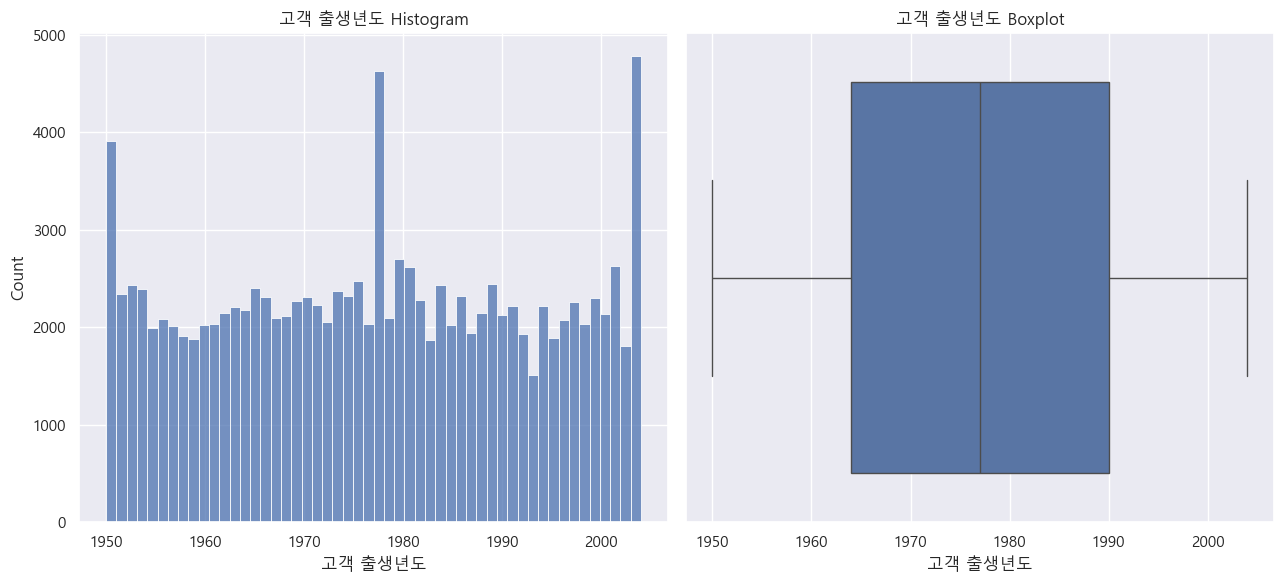

count    120000.000000
mean       1977.101658
std          15.773059
min        1950.000000
25%        1964.000000
50%        1977.000000
75%        1990.000000
max        2004.000000
Name: 고객 출생년도, dtype: float64

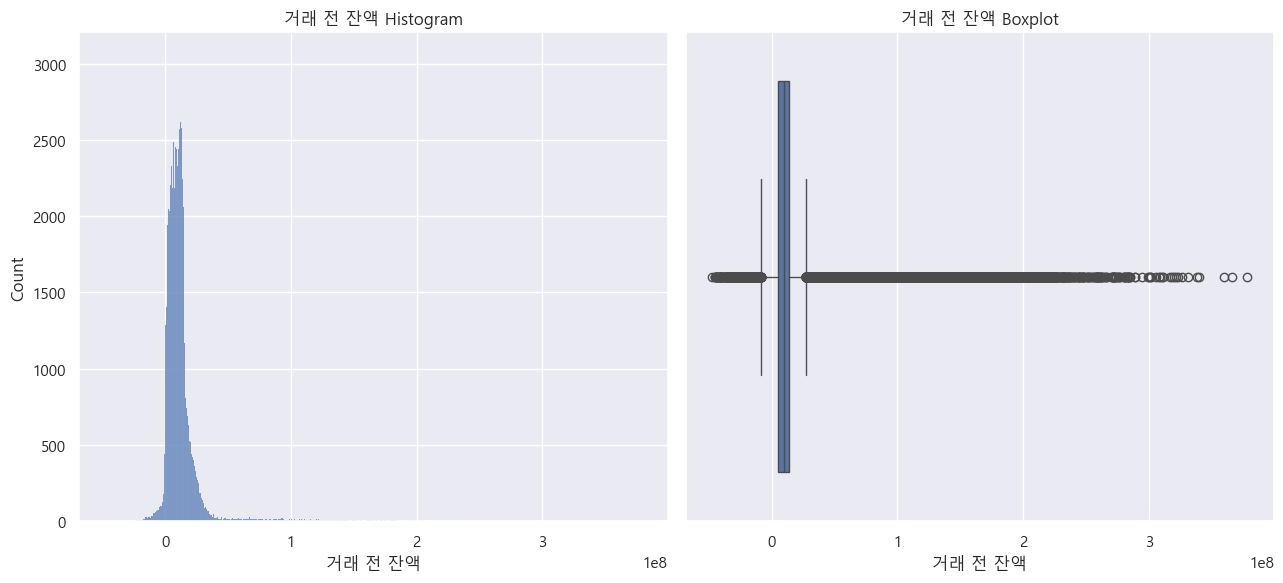

count    1.200000e+05
mean     1.330240e+07
std      2.199931e+07
min     -4.700236e+07
25%      4.981042e+06
50%      9.684951e+06
75%      1.406795e+07
max      3.782943e+08
Name: 거래 전 잔액, dtype: float64

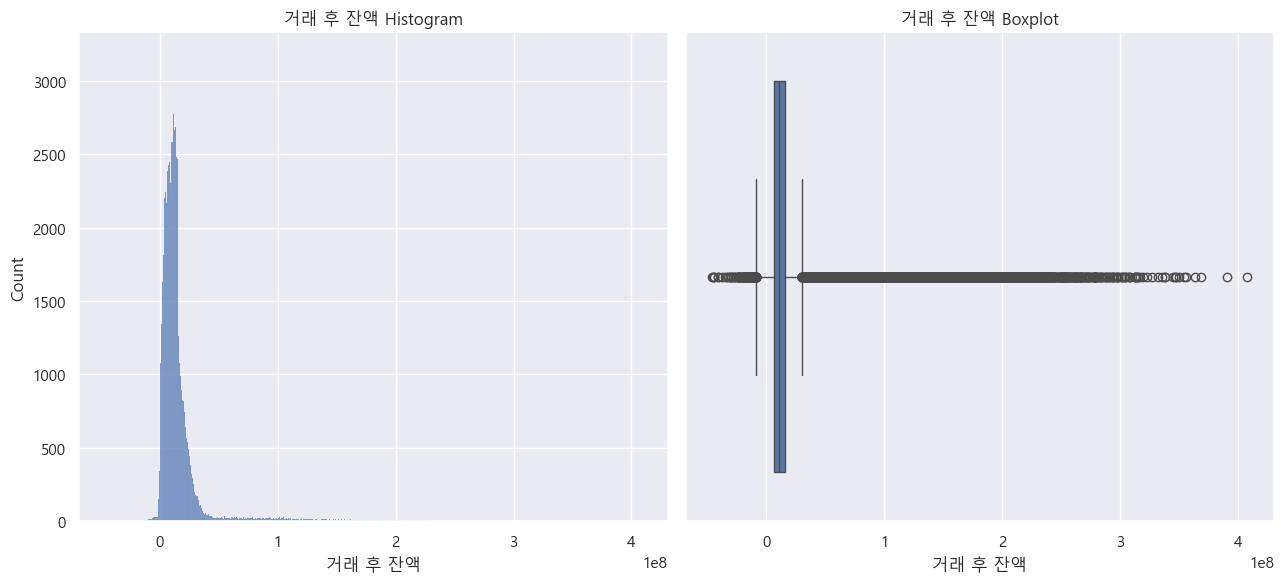

count    1.200000e+05
mean     1.660326e+07
std      2.693023e+07
min     -4.575656e+07
25%      6.161446e+06
50%      1.102199e+07
75%      1.592773e+07
max      4.080248e+08
Name: 거래 후 잔액, dtype: float64

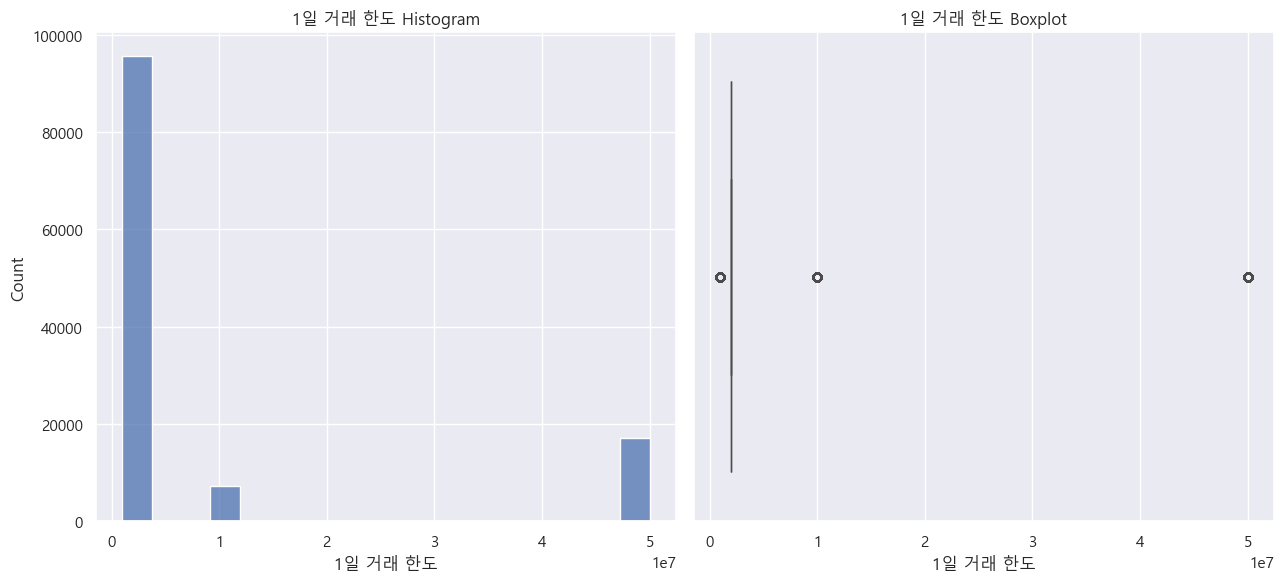

count    1.200000e+05
mean     9.053250e+06
std      1.677538e+07
min      1.000000e+06
25%      2.000000e+06
50%      2.000000e+06
75%      2.000000e+06
max      5.000000e+07
Name: 1일 거래 한도, dtype: float64

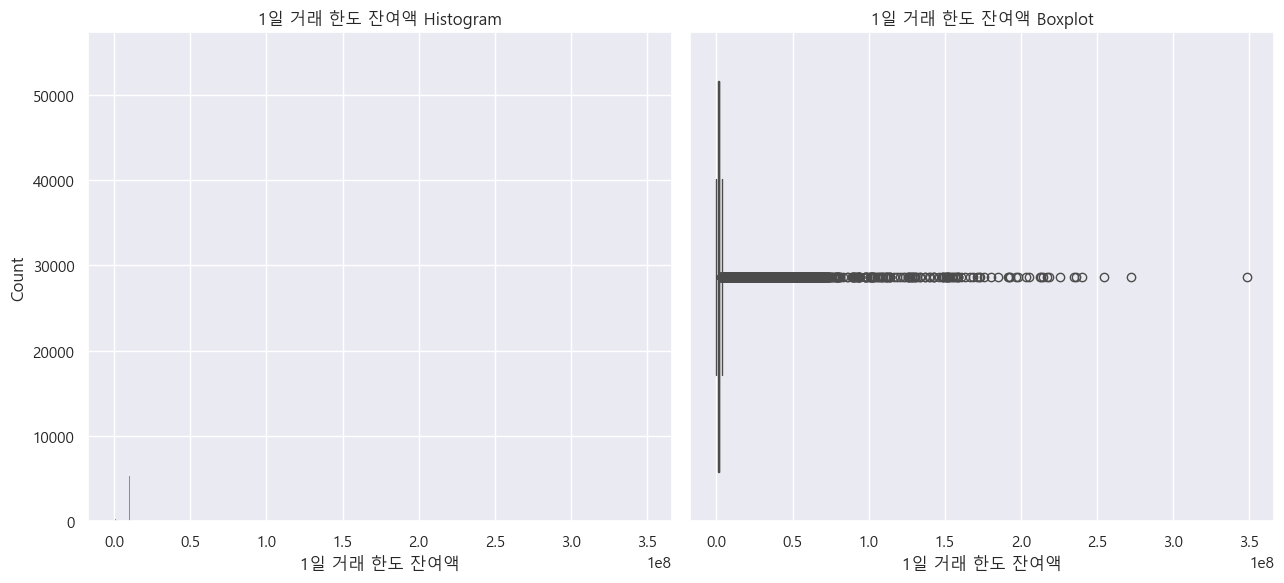

count    1.200000e+05
mean     8.911532e+06
std      1.698785e+07
min      0.000000e+00
25%      1.000000e+06
50%      2.000000e+06
75%      2.000000e+06
max      3.489200e+08
Name: 1일 거래 한도 잔여액, dtype: float64

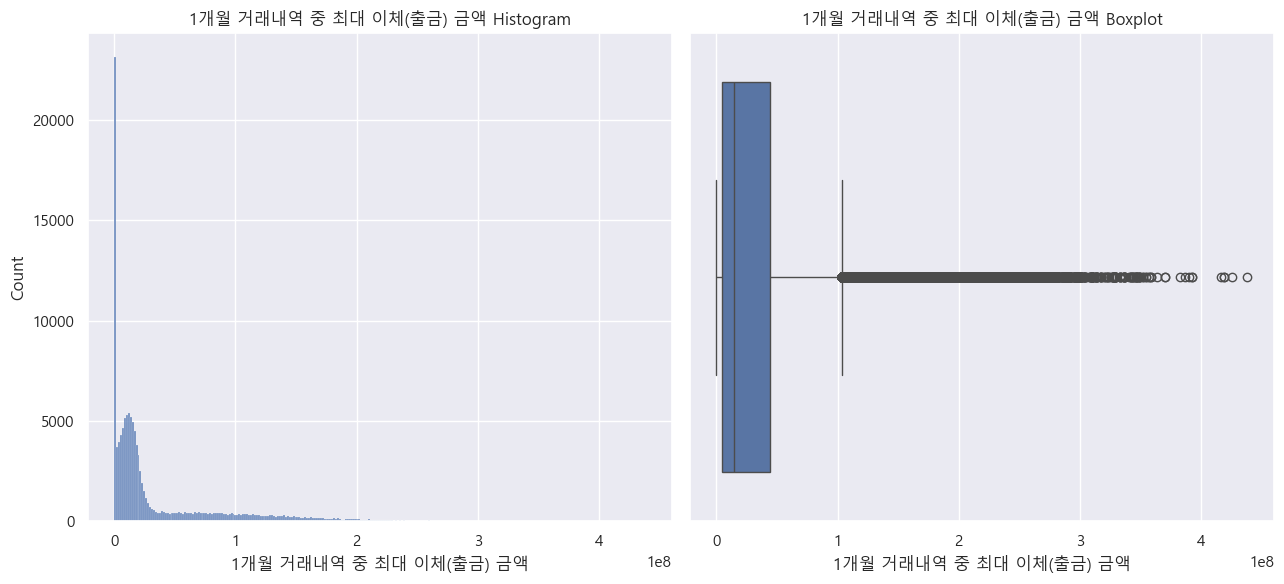

count    1.200000e+05
mean     3.694527e+07
std      5.350791e+07
min      0.000000e+00
25%      4.510000e+06
50%      1.415000e+07
75%      4.404500e+07
max      4.382600e+08
Name: 1개월 거래내역 중 최대 이체(출금) 금액, dtype: float64

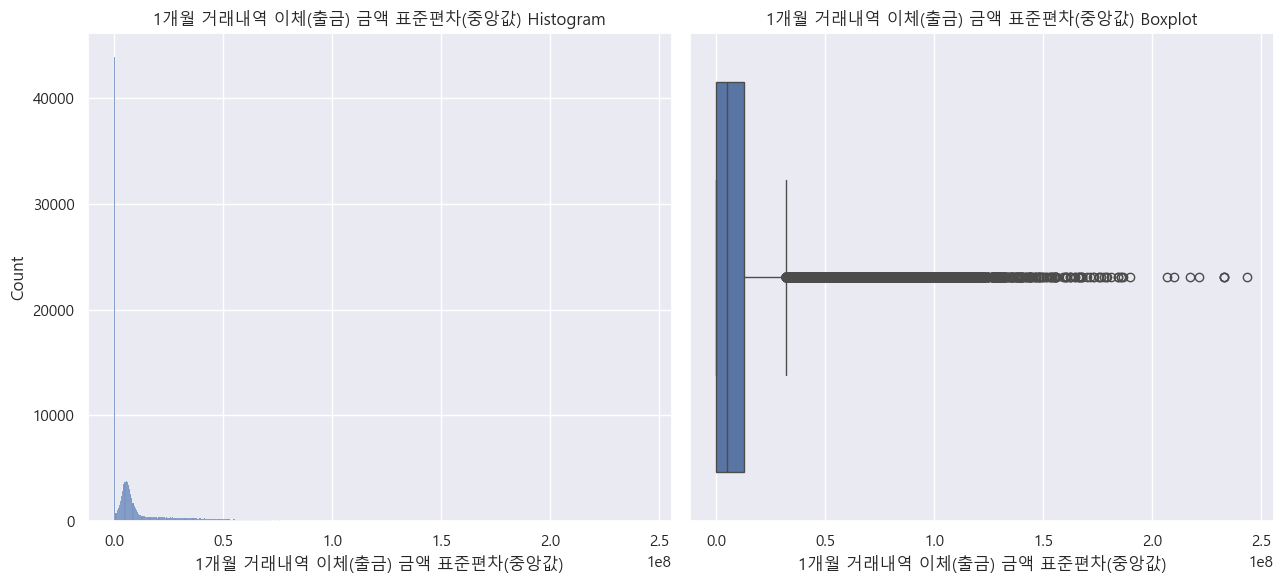

count    1.200000e+05
mean     1.217271e+07
std      1.966096e+07
min      0.000000e+00
25%      0.000000e+00
50%      4.802289e+06
75%      1.282296e+07
max      2.435700e+08
Name: 1개월 거래내역 이체(출금) 금액 표준편차(중앙값), dtype: float64

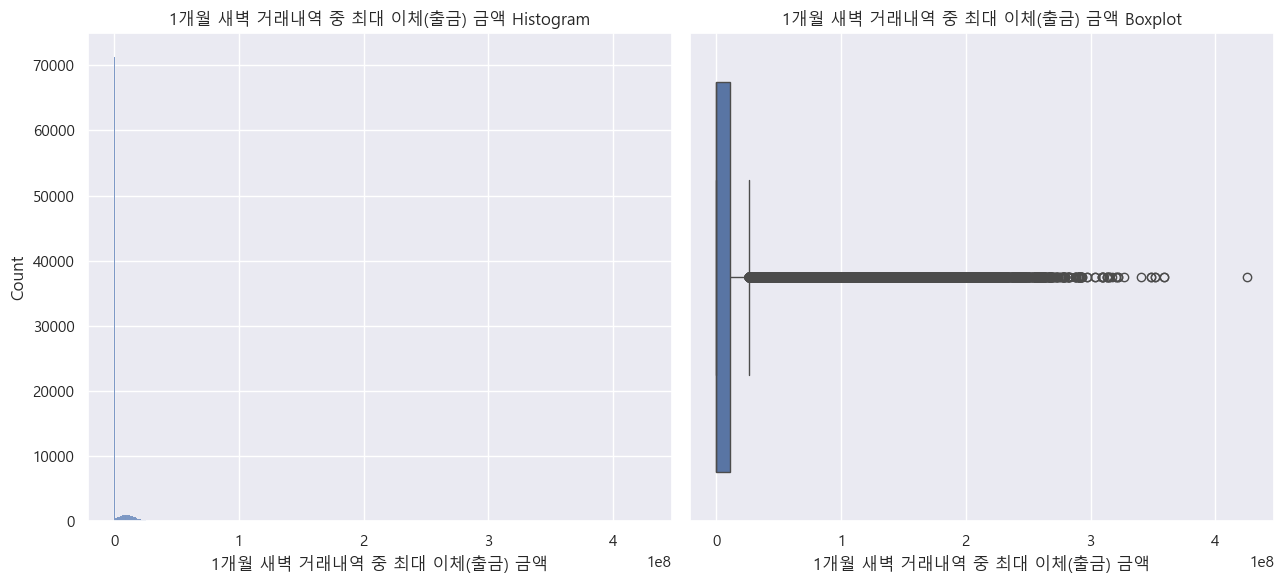

count    1.200000e+05
mean     1.242324e+07
std      3.242350e+07
min      0.000000e+00
25%      0.000000e+00
50%      0.000000e+00
75%      1.051000e+07
max      4.257800e+08
Name: 1개월 새벽 거래내역 중 최대 이체(출금) 금액, dtype: float64

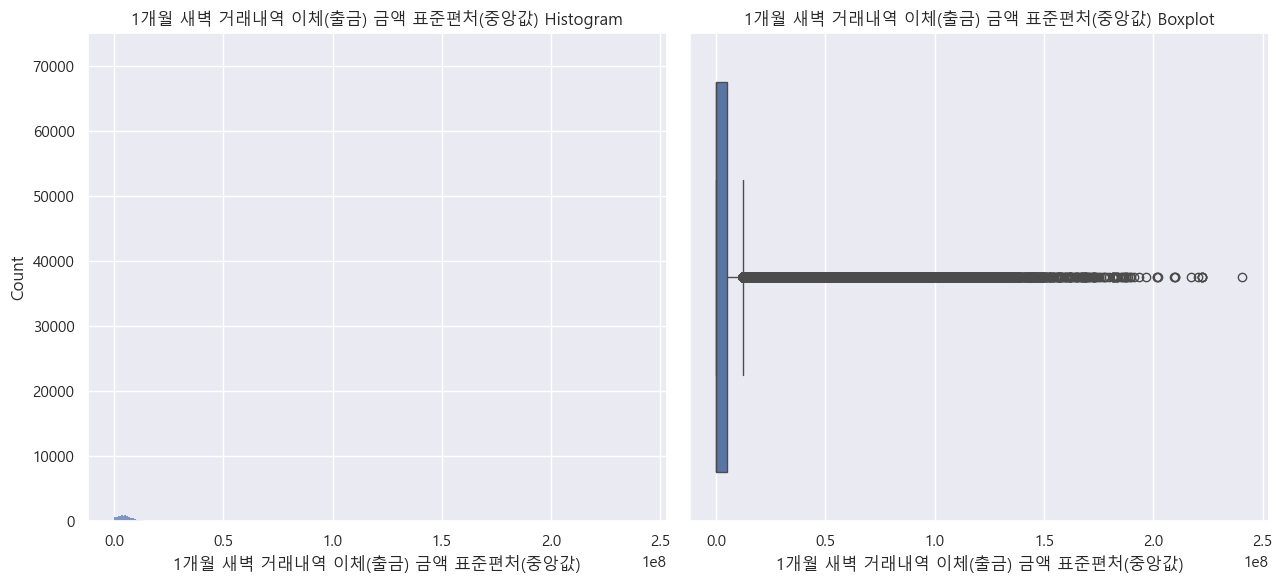

count    1.200000e+05
mean     6.326643e+06
std      1.745005e+07
min      0.000000e+00
25%      0.000000e+00
50%      0.000000e+00
75%      4.877202e+06
max      2.408052e+08
Name: 1개월 새벽 거래내역 이체(출금) 금액 표준편처(중앙값), dtype: float64

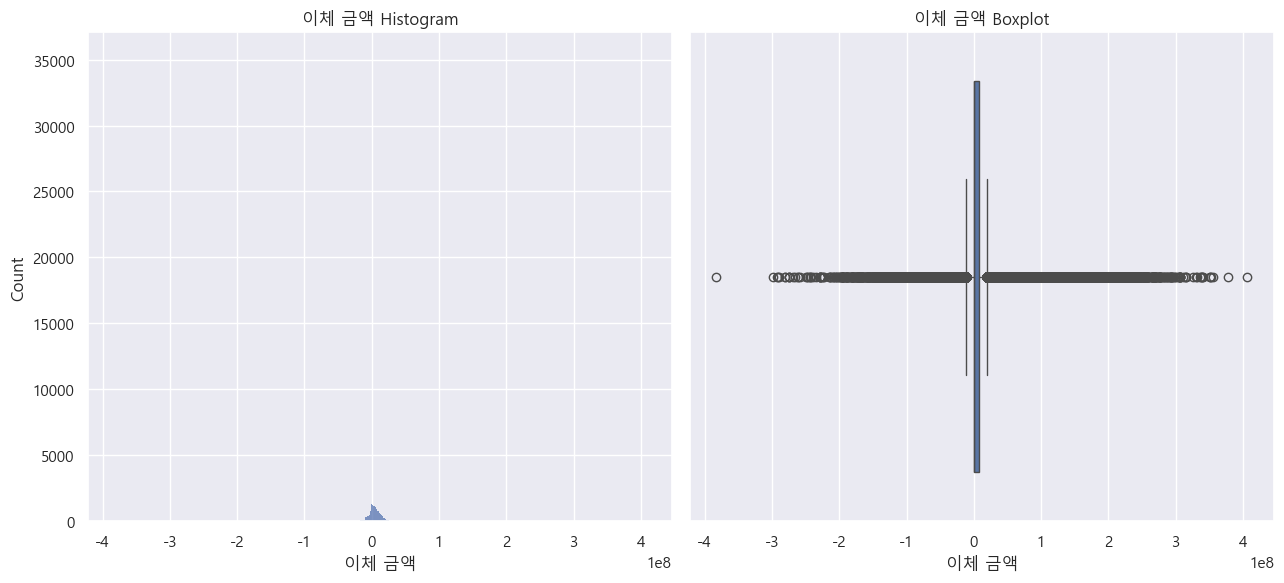

count    1.200000e+05
mean     7.506120e+06
std      2.891830e+07
min     -3.824800e+08
25%     -5.000000e+04
50%      1.600000e+05
75%      7.640000e+06
max      4.066900e+08
Name: 이체 금액, dtype: float64

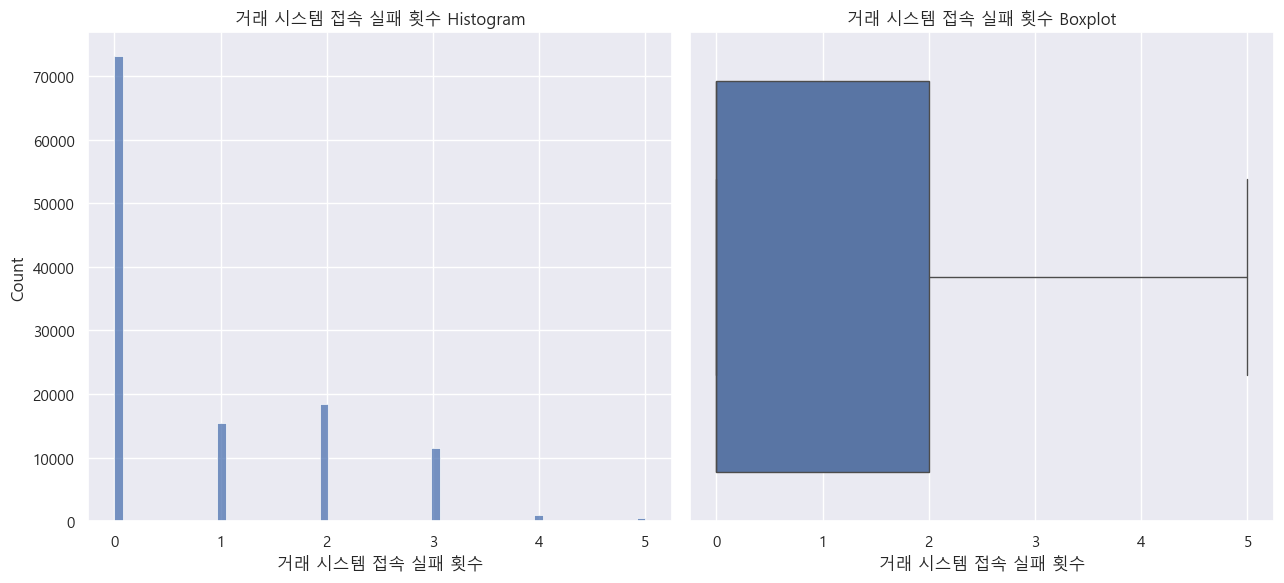

count    120000.000000
mean          0.776125
std           1.112938
min           0.000000
25%           0.000000
50%           0.000000
75%           2.000000
max           5.000000
Name: 거래 시스템 접속 실패 횟수, dtype: float64

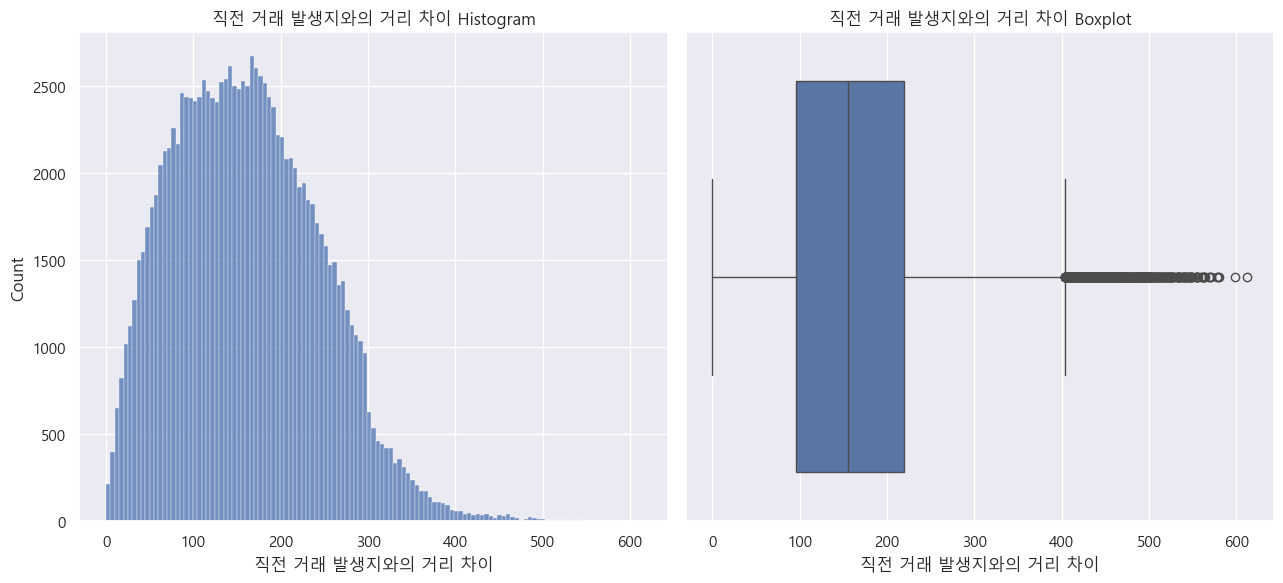

count    120000.000000
mean        161.156262
std          84.087296
min           0.000000
25%          95.530110
50%         155.802819
75%         218.893869
max         612.485680
Name: 직전 거래 발생지와의 거리 차이, dtype: float64

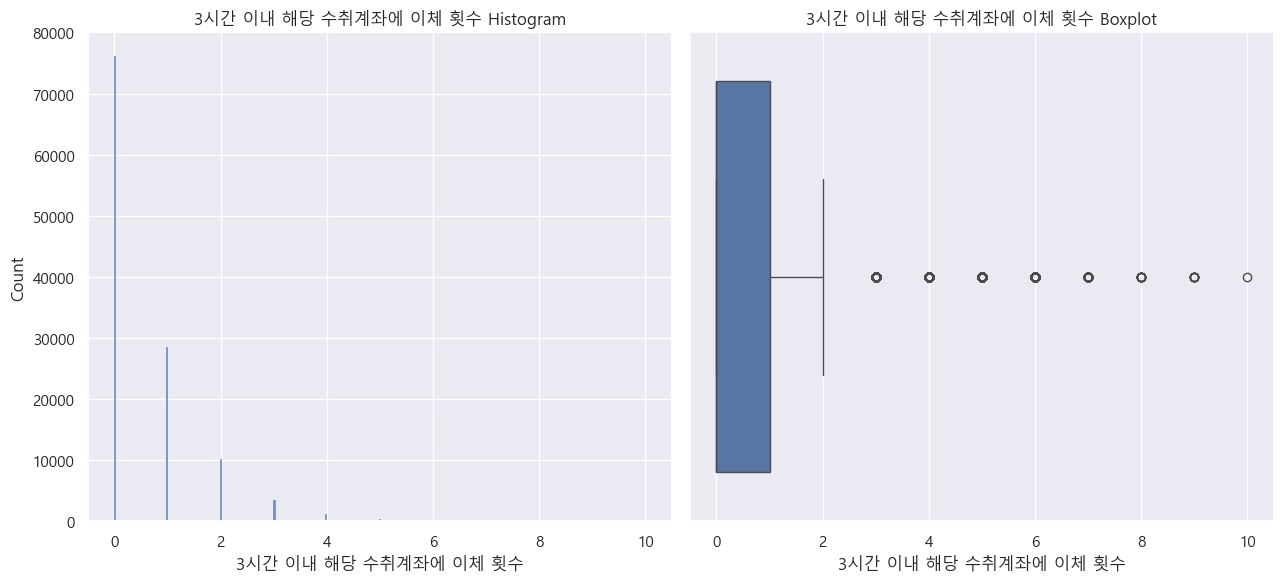

count    120000.000000
mean          0.557517
std           0.909211
min           0.000000
25%           0.000000
50%           0.000000
75%           1.000000
max          10.000000
Name: 3시간 이내 해당 수취계좌에 이체 횟수, dtype: float64

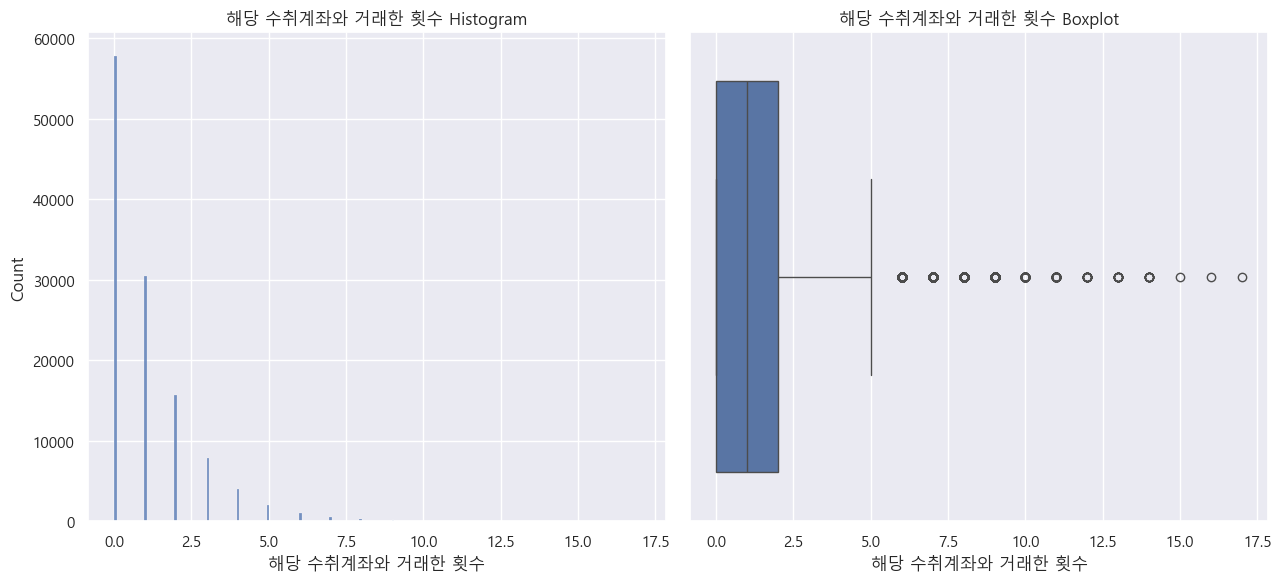

count    120000.000000
mean          1.053767
std           1.457519
min           0.000000
25%           0.000000
50%           1.000000
75%           2.000000
max          17.000000
Name: 해당 수취계좌와 거래한 횟수, dtype: float64

In [113]:
for column, col_type in zip(cond_all['항목 설명'], cond_all['데이터 형태']):

    if col_type == '수치형' and column != '직전 거래와의 시간 차이':

       fig, ax = plt.subplots(ncols=2, figsize=(13, 6))

       sns.histplot(data=train_all_re,
                    x=column,
                    ax=ax[0])
       ax[0].set_title(f'{column} Histogram')

       sns.boxplot(data=train_all_re,
                   x=column,
                   ax=ax[1])
       ax[1].set_title(f'{column} Boxplot')

       plt.tight_layout()
       plt.show()

       print()
       display(train_all_re[column].describe())
       print()

### 시간형 변수

In [22]:
train_all_re = pd.read_csv(base_path+"/train_renamed.csv")

In [26]:
def date_tempo(start_date, end_date, tempo):

    start_date = datetime.strptime(start_date, '%Y-%m-%d')
    end_date = datetime.strptime(end_date, '%Y-%m-%d')

    date_list = []
    current_date = start_date
    while current_date <= end_date:
        date_list.append(str(current_date.strftime("%Y-%m-%d")))
        current_date += timedelta(days=1)

    date_list = pd.to_datetime(date_list)
    return date_list[::tempo]

- Customer_registration_datetime : 2013Y ~ 2023Y 데이터 없음
- Account_creation_datetime : 2013Y ~ 2023Y 데이터 없음
- Transaction_Datetime : 2050Y 이후 데이터 수 극소수 (2018Y 부근으로 데이터 수 증가)
- Last_atm_transaction_datetime : 2050Y 이후 데이터 수 극소수 (2018Y 부근으로 데이터 수 증가)
- Last_bank_branch_transaction_datetime : 2050Y 이후 데이터 수 극소수 (2018Y 부근으로 데이터 수 증가)
- Transaction_resumed_date : 2050Y 이후 데이터 수 극소수 (2018Y 부근으로 데이터 수 증가)

- Transaction_Datetime : 00시 기준으로 데이터 수가 점차 증가 (00시 기준으로 데이터 수가 급감)

In [ ]:
train_all.columns

Index(['샘플 식별자 번호', '고객 출생년도', '고객 성별', '고객명', '주민번호', '고객 등록일자', '고객 등급',
       '3개월 이내 금융/공동인증서 발급 여부', '3개월 이내 사설인증서 발급 여부',
       '3개월 이내 보안카드 및 OTP 발급 여부', '3개월 이내 개인정보 수정 여부', '탈옥 및 루팅 여부',
       '모바일 로밍 여부', 'VPN 사용 여부',
       '대출 신청 유형(a: 없음, b: 신용대출, c: 담보대출, d: 할부금융, e: 기타)', '전화번호 조작 여부',
       '원격제어 여부', '템퍼링 여부', '피싱 여부', '신뢰할 수 없는 인증서 사용 여부', '키로깅 여부',
       '7일 이내 ATM 한도 문의 여부', '7일 이내 ATM 한도 증액 여부', '암호화된 계좌번호',
       '계좌유형(a: 입출금계좌, b: CMA, c: ISA, d: 저축계좌)', '계좌 개설 일자', '거래 전 잔액',
       '거래 후 잔액', '거래한도 증가 여부', '1일 거래 한도', '오픈뱅킹 사용 여부', '1일 거래 한도 잔여액',
       '30일 이내 계좌 정지 해제 여부', '1개월 거래내역 중 최대 이체(출금) 금액',
       '1개월 거래내역 이체(출금) 금액 표준편차(중앙값)', '1개월 새벽 거래내역 중 최대 이체(출금) 금액',
       '1개월 새벽 거래내역 이체(출금) 금액 표준편처(중앙값)', '거래일자', '이체 금액', '거래 채널',
       '거래에 사용한 단말기 OS',
       '에러코드(a: 에러없음, b: 시스템 오류, c: 잔액부족, d: 이체한도초과, e: 계좌정보 오류, f: 계좌이체 거부)',
       '거래 성공/실패 여부', '자동이체(automatic) 또는 일반거래(general)', '거래에 사용한 단말기 IP주소',
       '거래에 사용한 단말기 MAC주소',
       '거래 시

In [23]:
train_all_re.columns

Index(['거래_ID', '고객_출생년도', '고객_성별', '고객_개인식별자', '고객_식별번호', '고객_등록일시',
       '고객_신용등급', '인증수단_변경플래그1', '인증수단_변경플래그2', '인증수단_변경플래그3', '인증수단_변경플래그4',
       '루팅_탈옥여부', '모바일_로밍여부', 'VPN_사용여부', '고객_대출유형', '단말기_악성행동플래그1',
       '단말기_악성행동플래그2', '단말기_악성행동플래그3', '단말기_악성행동플래그4', '단말기_악성행동플래그5',
       '단말기_악성행동플래그6', 'ATM_한도조회횟수', 'ATM_한도증가요청', '계좌_번호', '계좌_종류', '계좌_개설일시',
       '계좌_최초잔액', '현재_계좌잔액', '한도초과여부', '하루이체한도금액', '오픈뱅킹등록여부', '하루한도초과후남은금액',
       '출금정지여부', '1개월최대거래금액', '1개월거래금액표준편차', '1개월새벽최대거래금액', '1개월새벽거래금액표준편차',
       '거래_일시', '거래_금액', '거래_채널', '사용_OS', '오류코드', '거래_실패_여부', '자동이체_거래_구분',
       'IP_주소', 'MAC_주소', '접속_매체', '거래_위치', '수취인_계좌번호', '거래_접속_실패_횟수',
       '타인_계좌_여부', '거리', '거래시간_차이', '미사용_단말기_상태', '마지막_ATM_거래_시간',
       '마지막_은행지점_거래_시간', '천만원초과_입금_플래그', '미사용_계좌_상태', '수취인_계좌_정지여부',
       '계좌별_거래건수', '계좌_거래내역지수', '취약사용자의_iOS첫사용', '사기_유형', '거래_재개일시'],
      dtype='object')

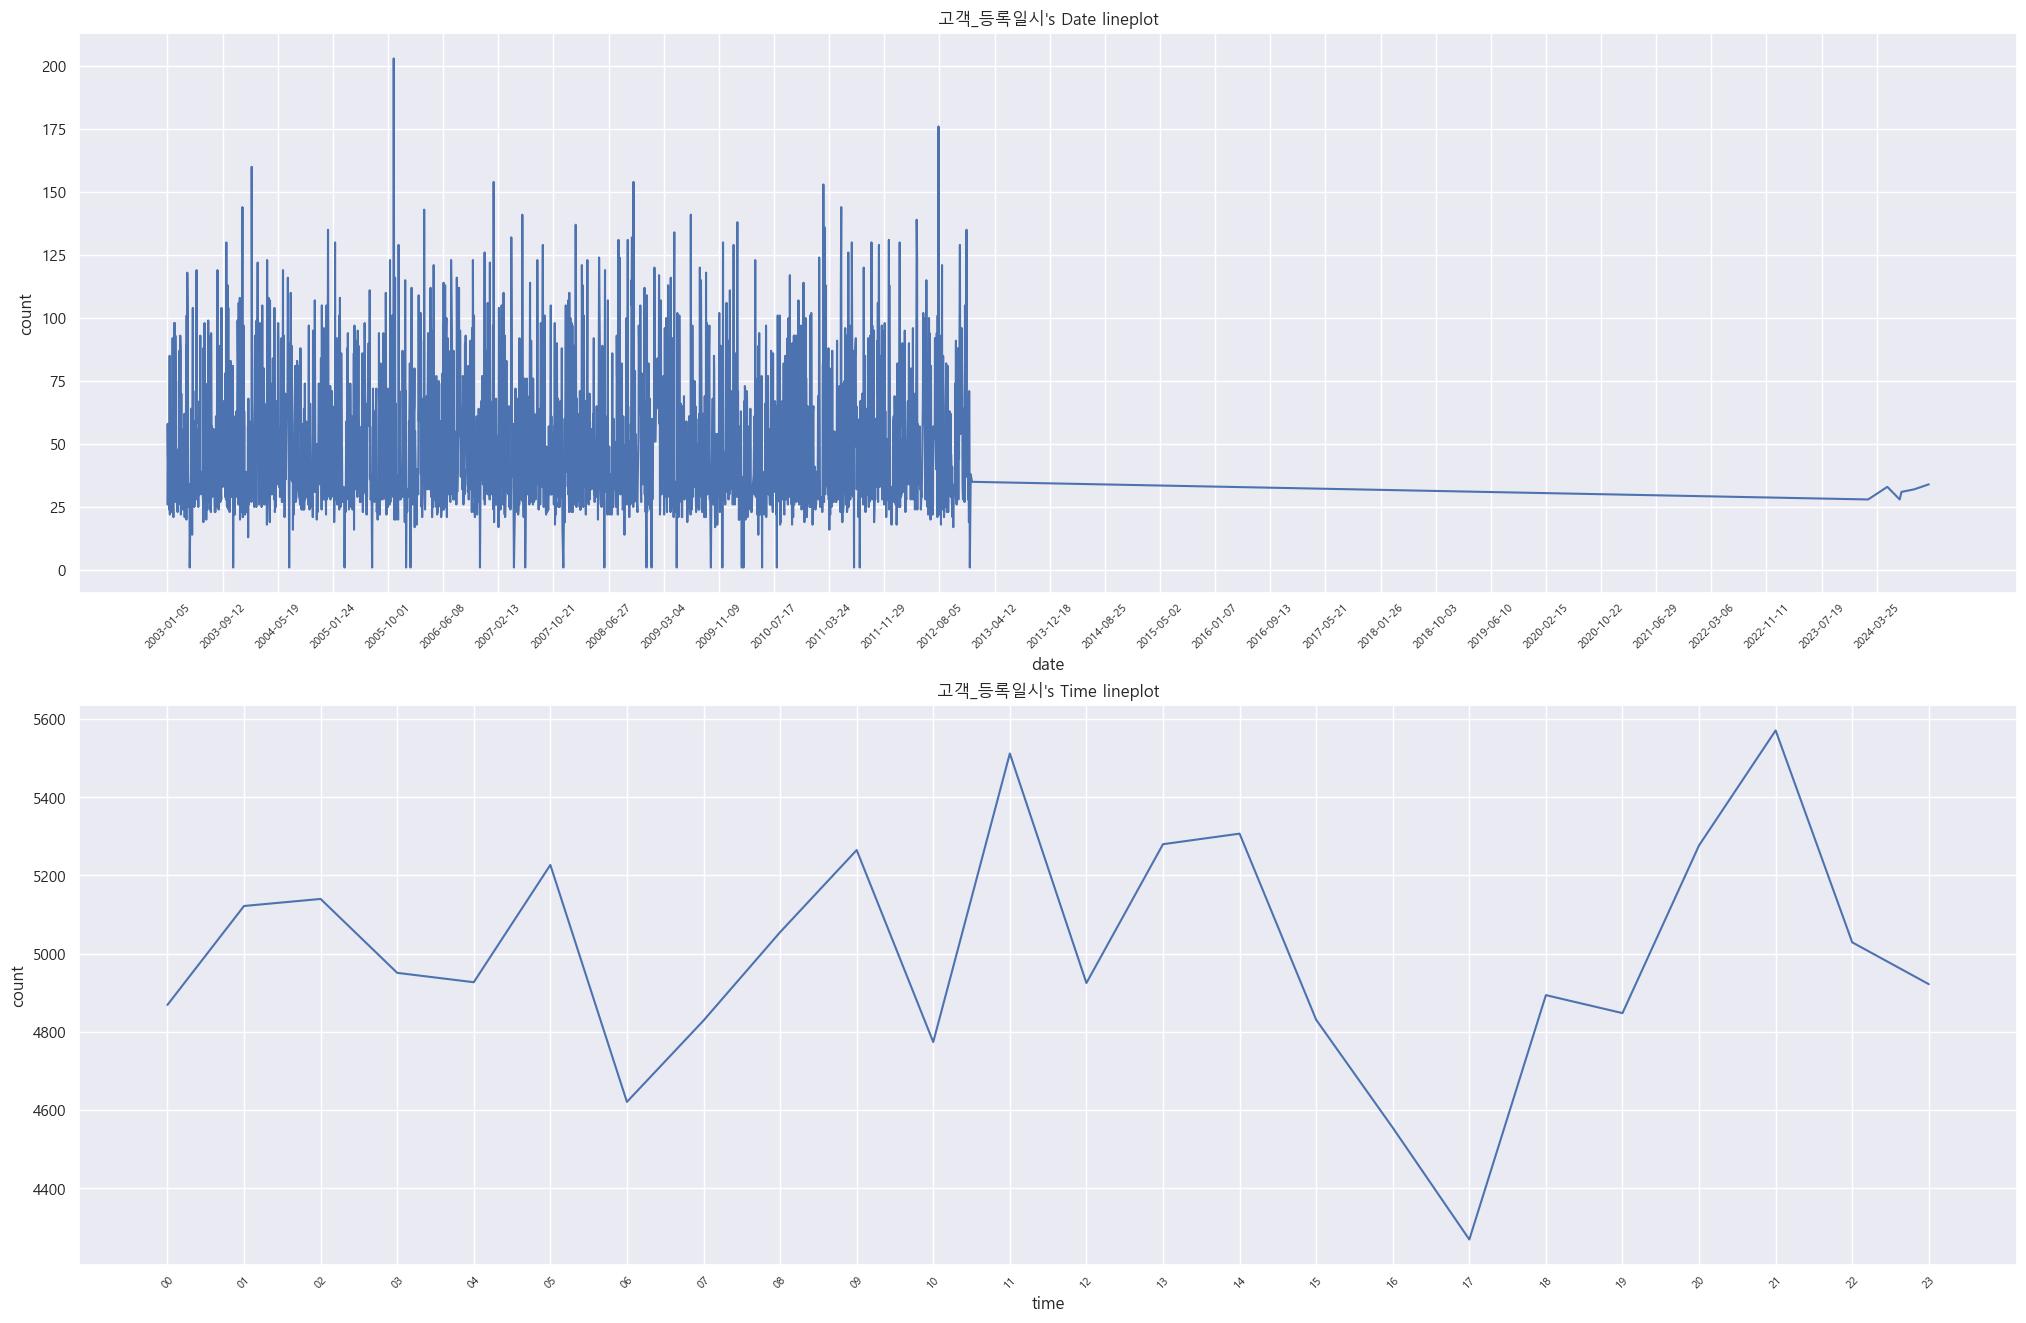

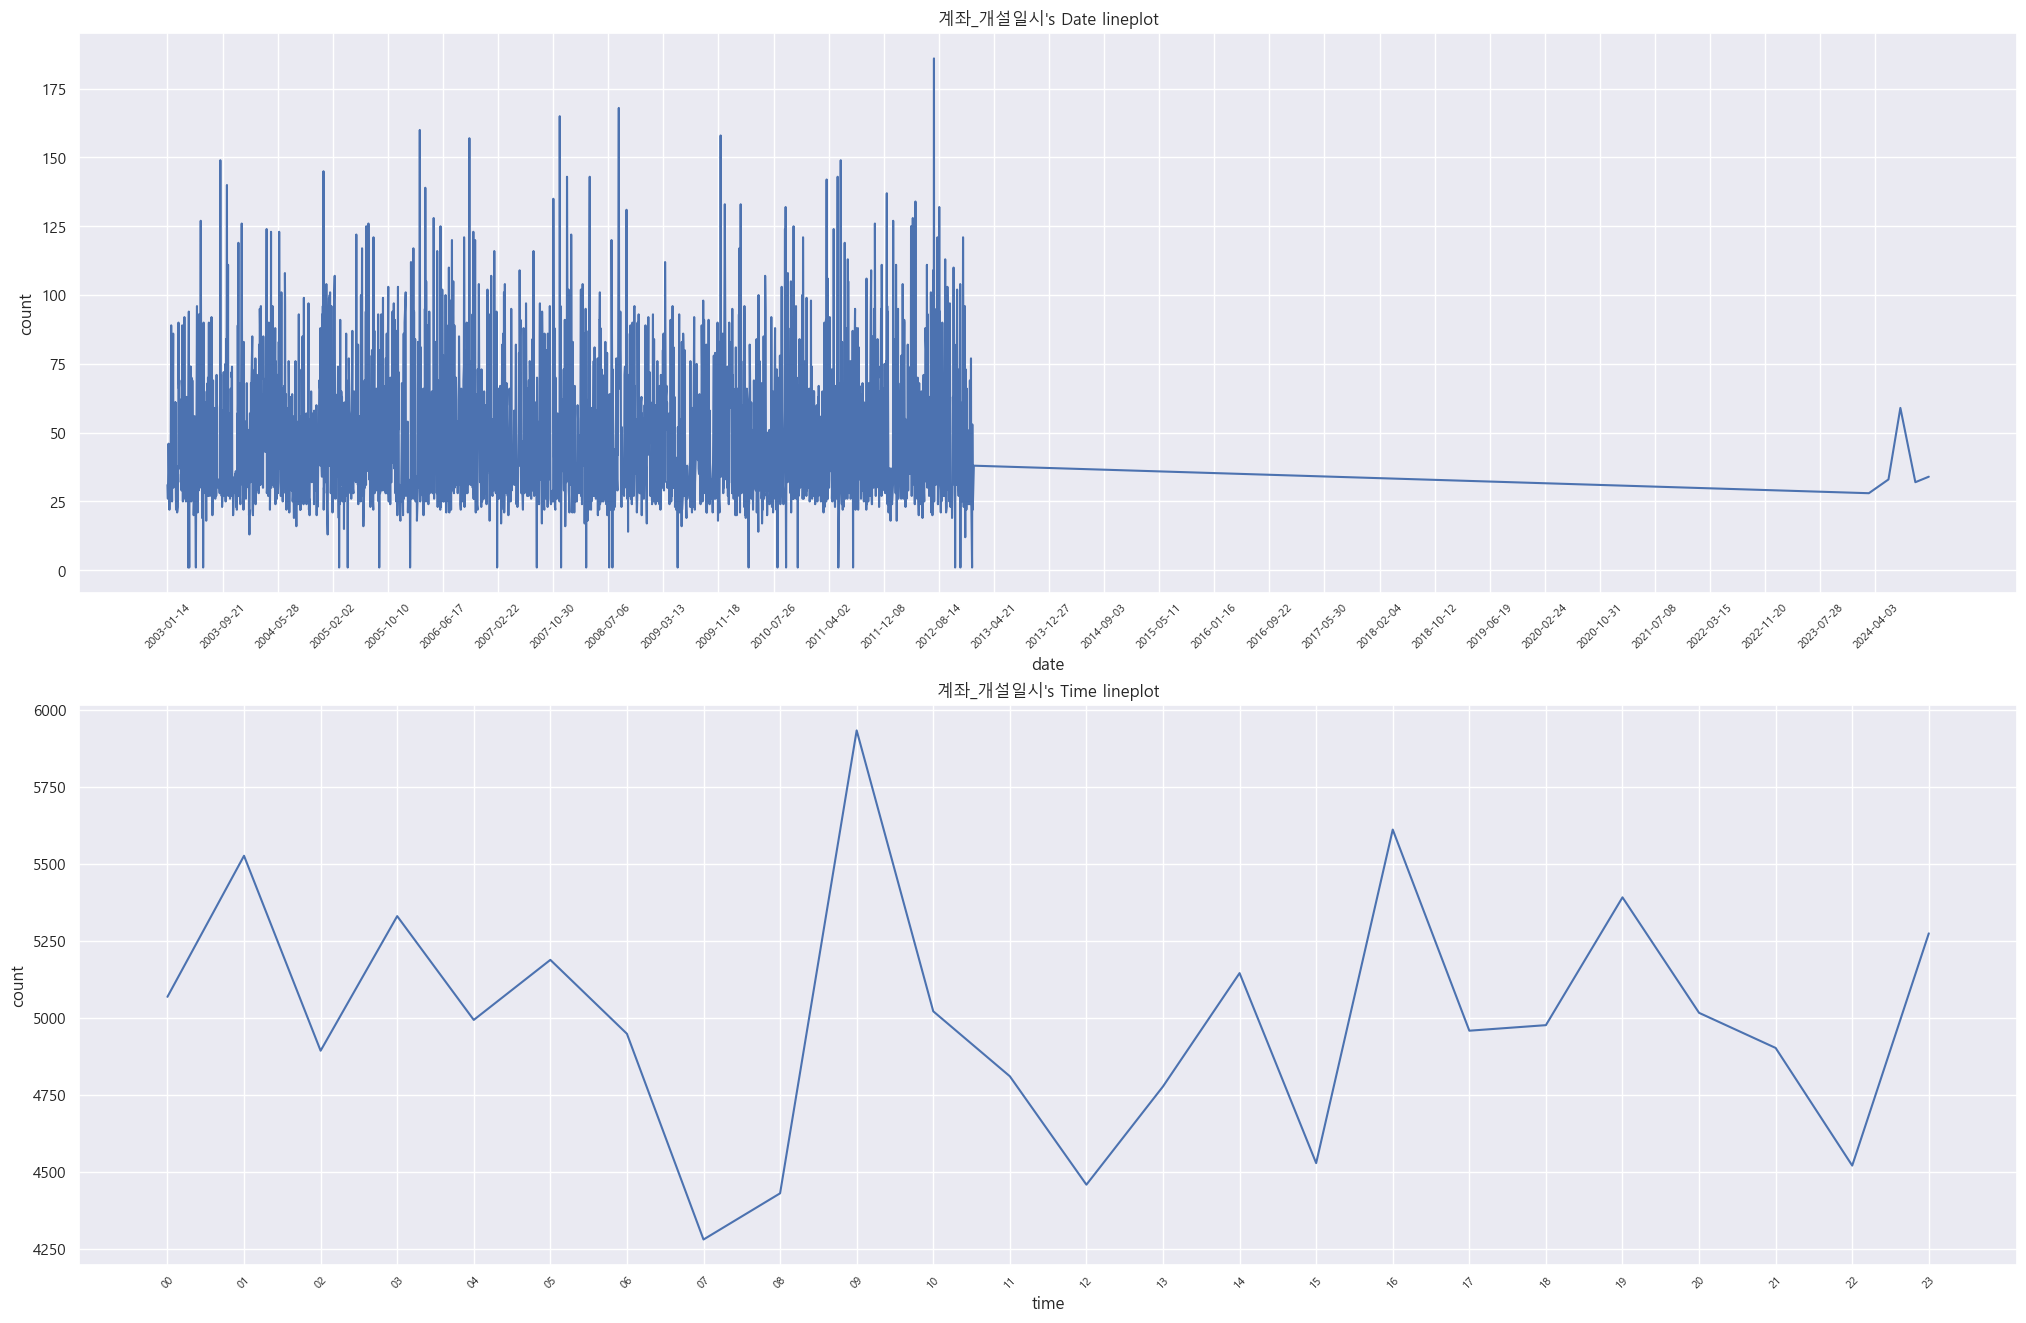

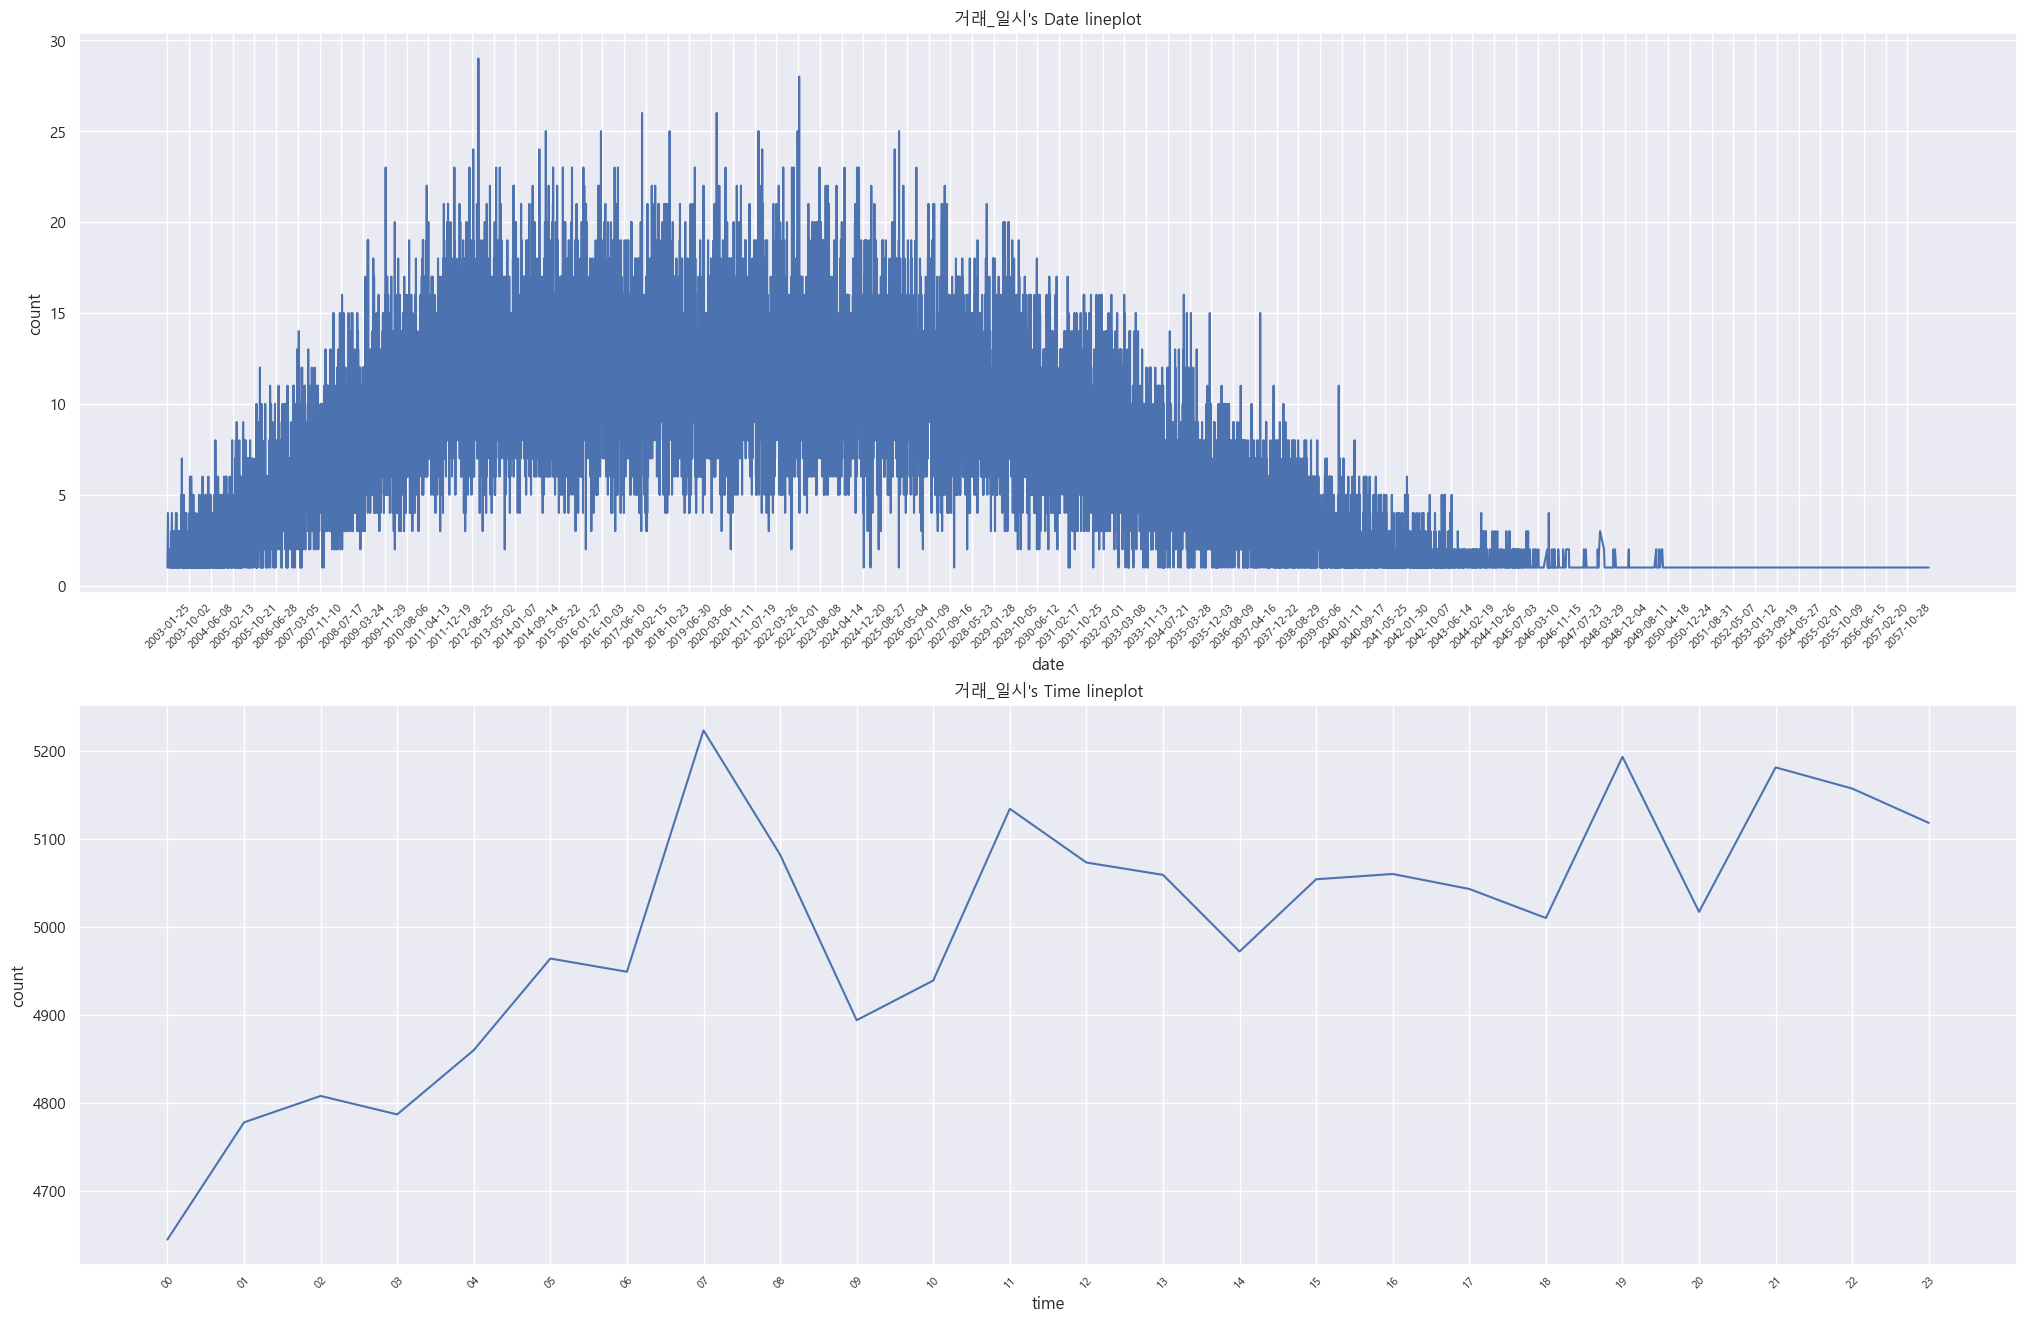

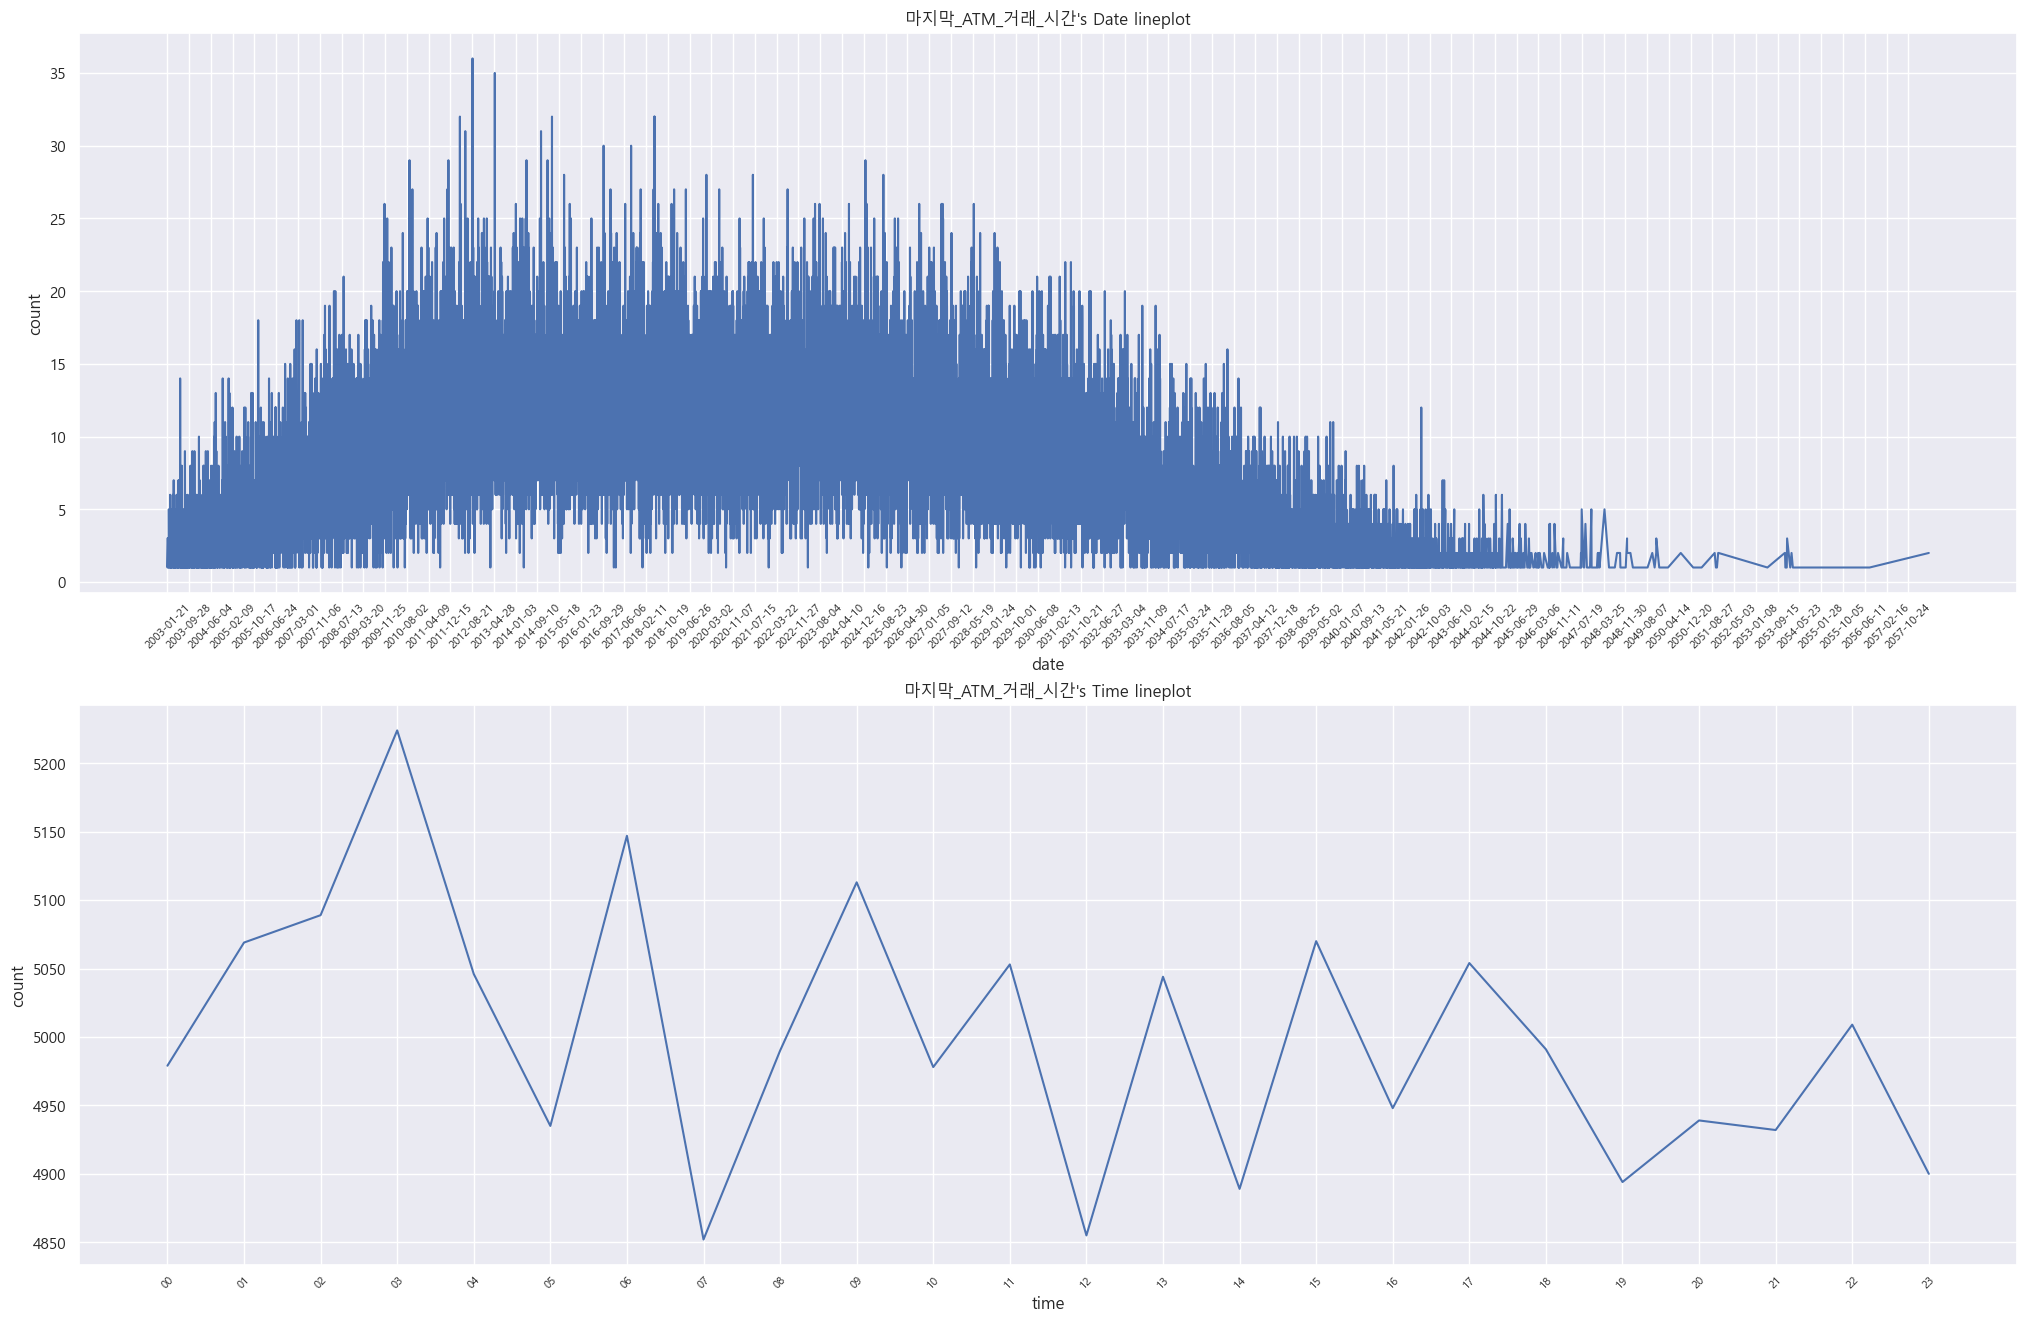

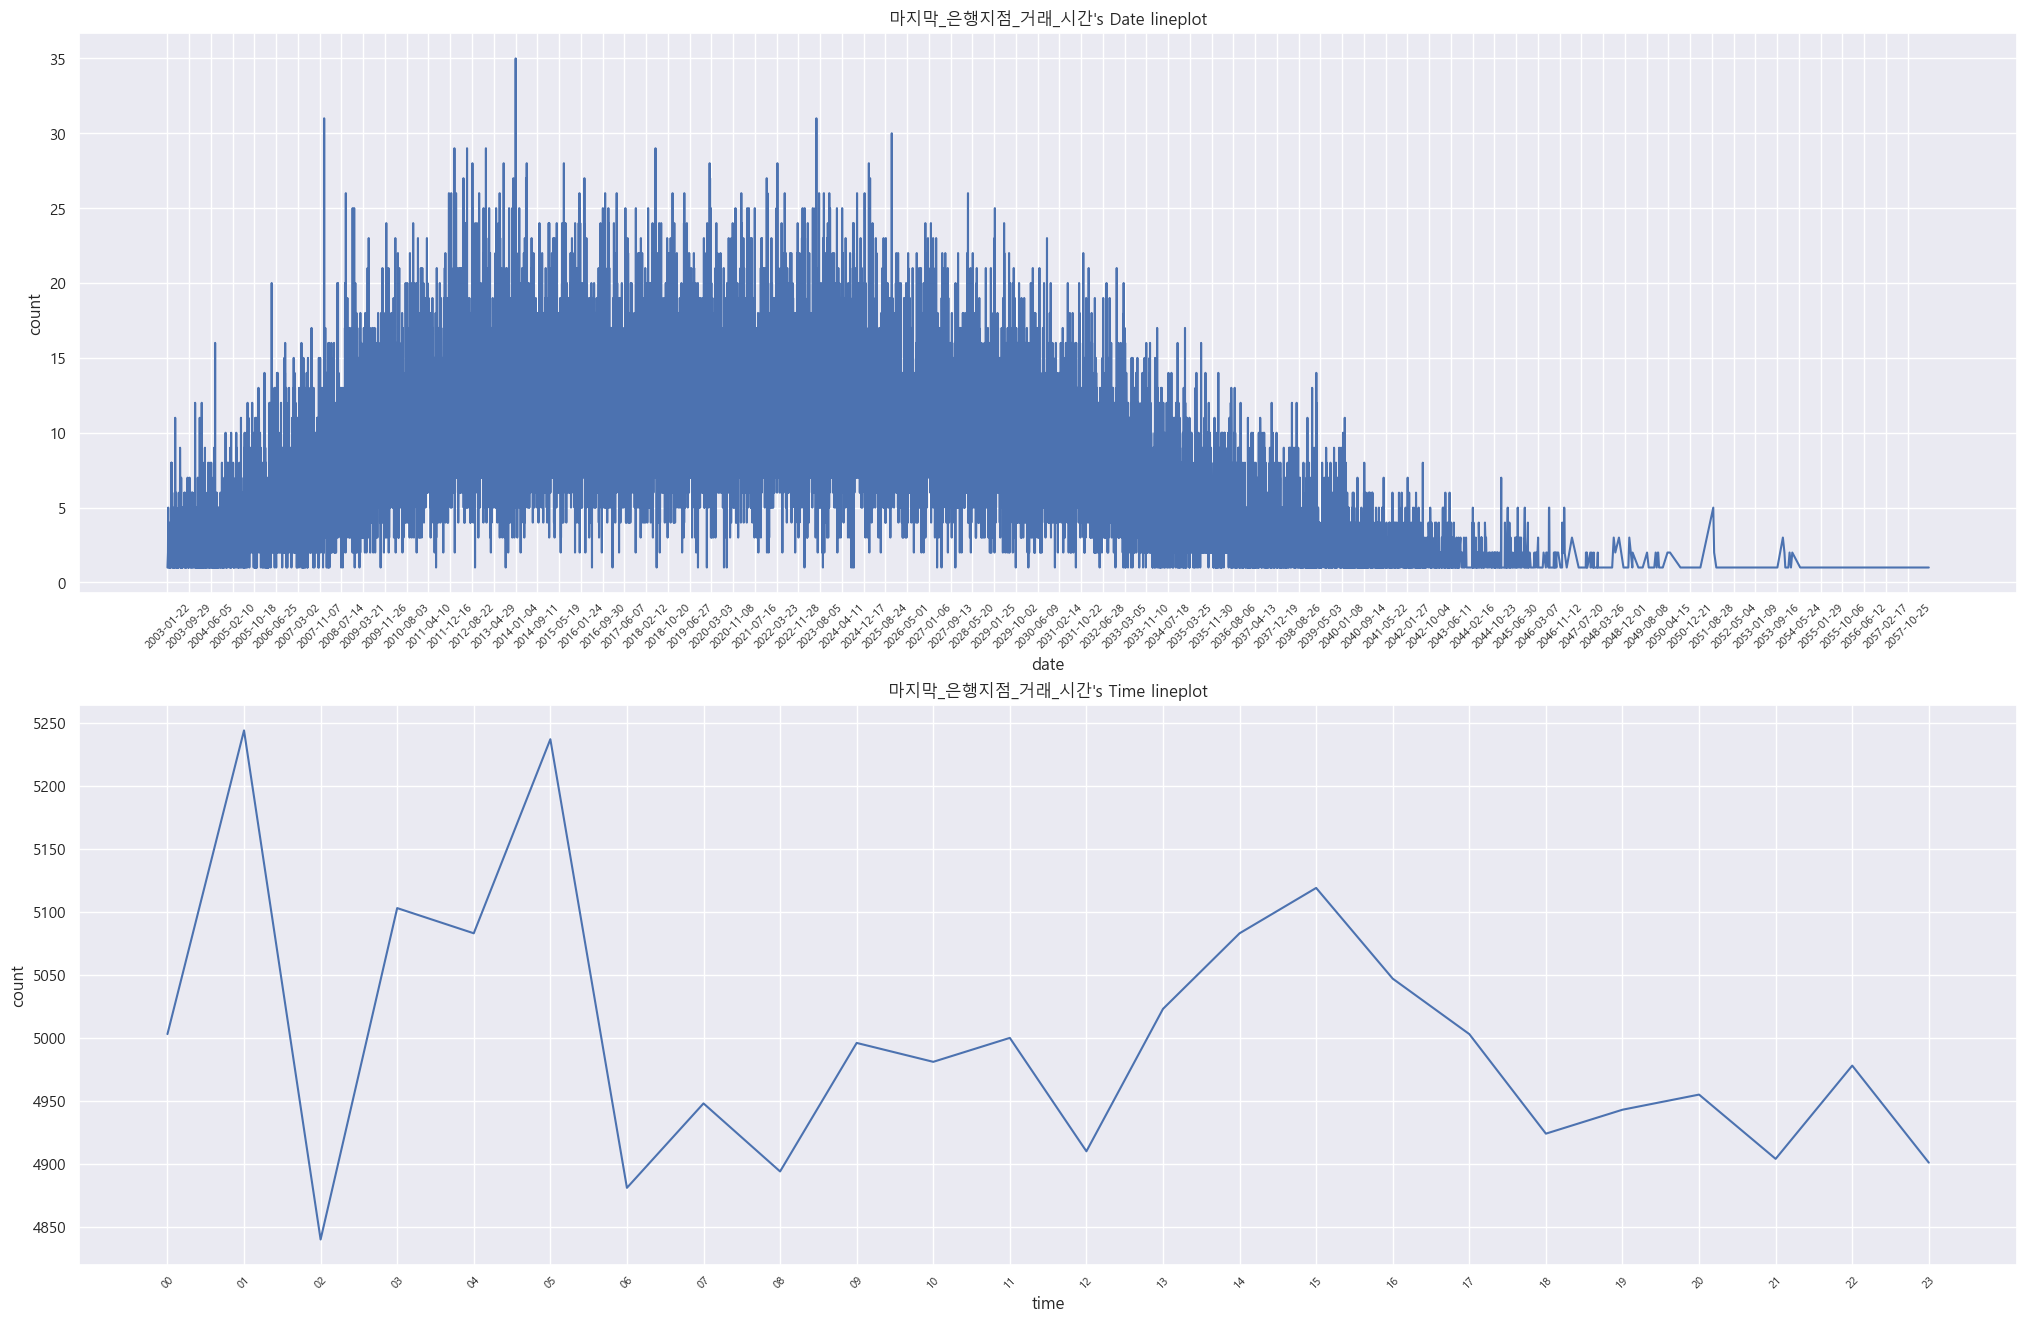

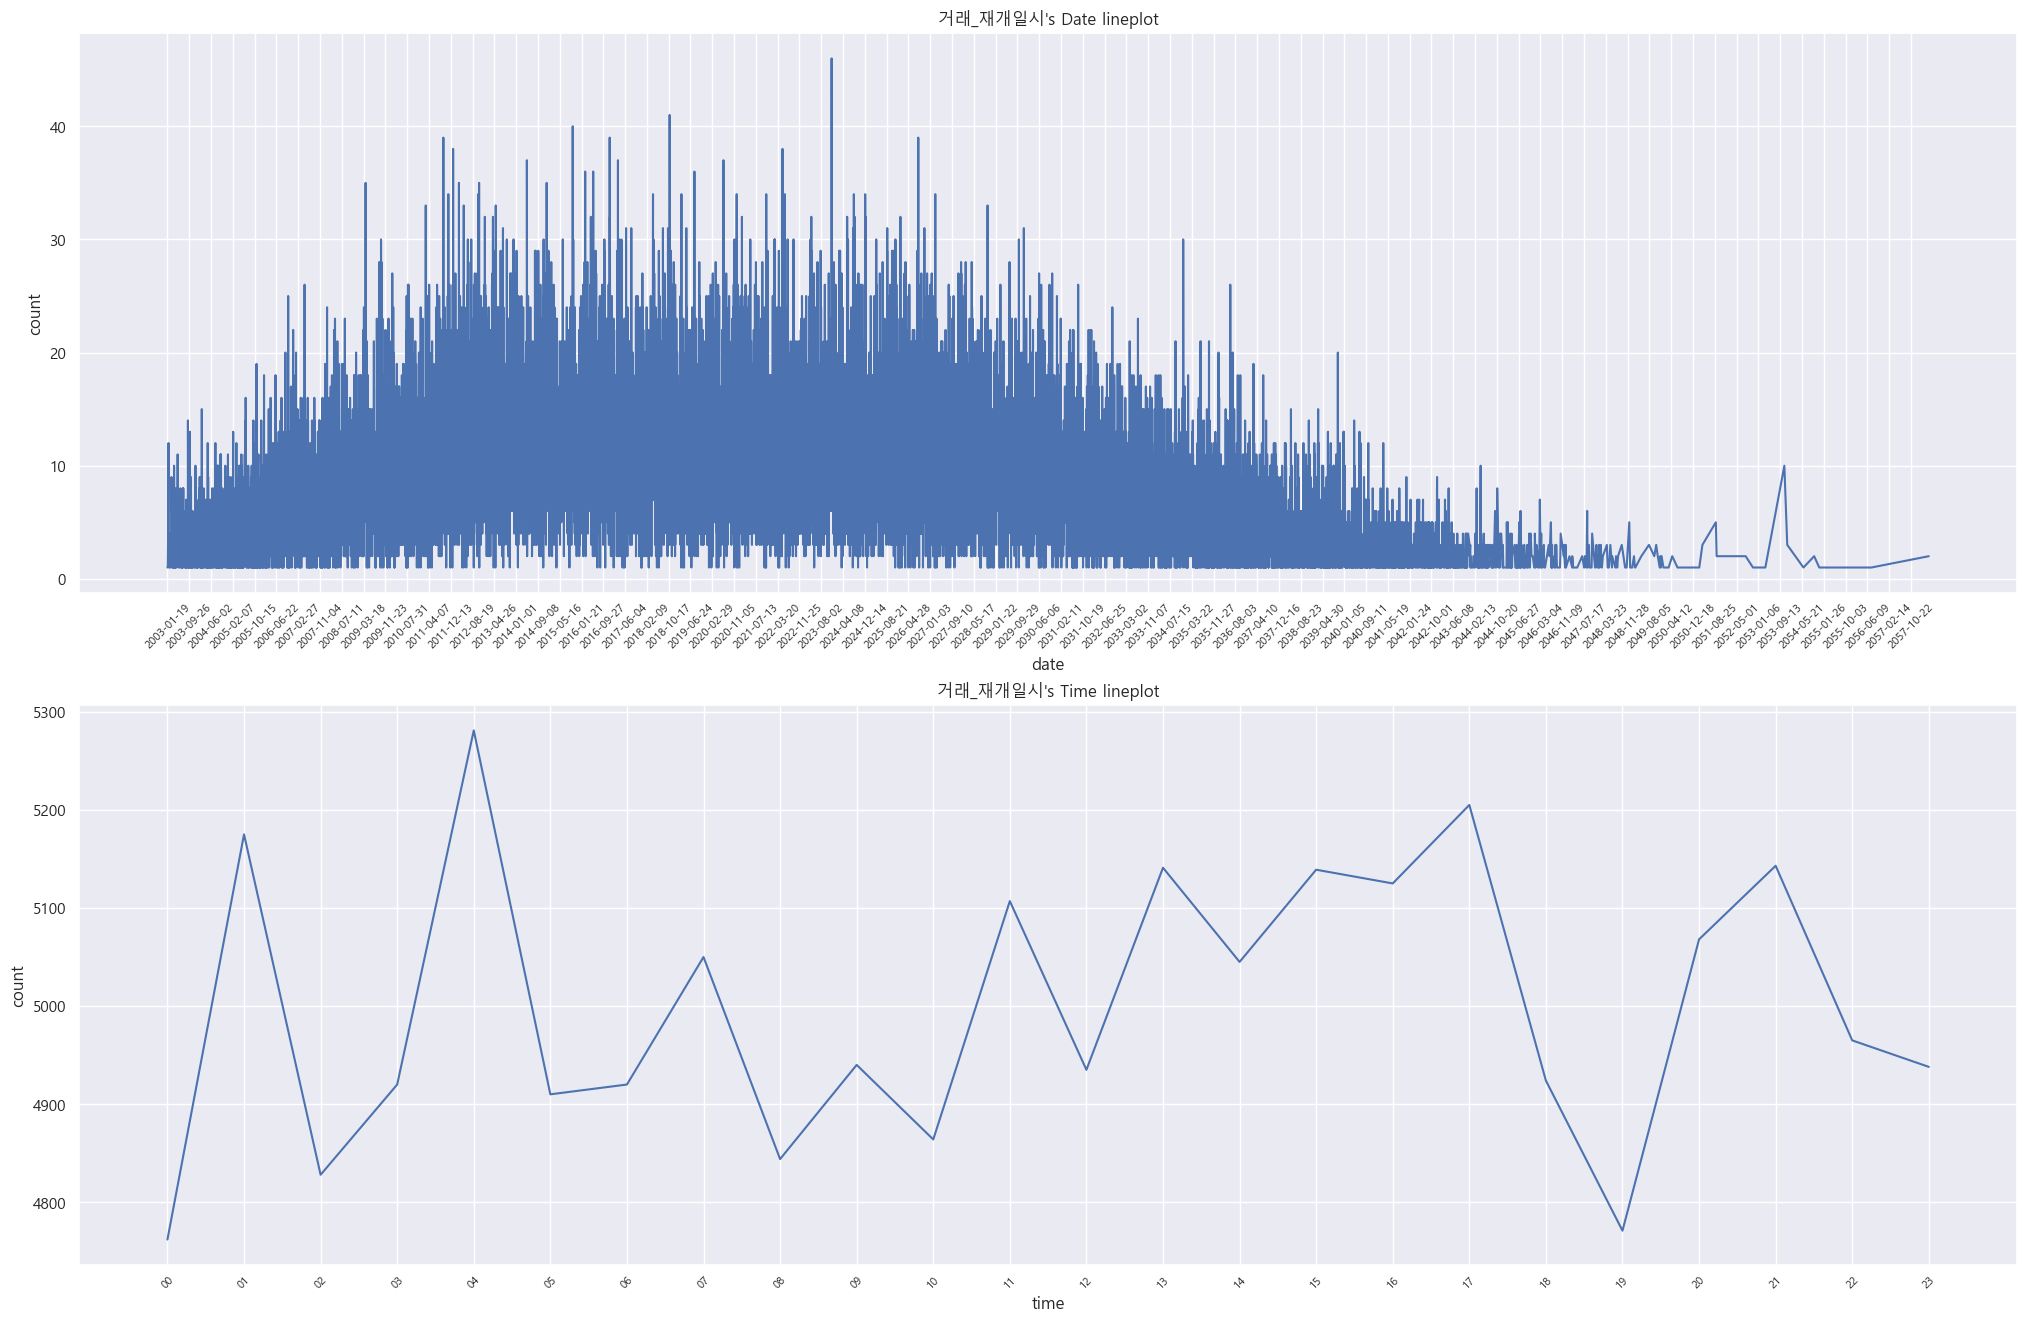

In [30]:
list_time_columns = ['Customer_registration_datetime',
                     'Account_creation_datetime',
                     'Transaction_Datetime',
                     'Last_atm_transaction_datetime',
                     'Last_bank_branch_transaction_datetime',
                     'Transaction_resumed_date']
# list_time_columns를 한글 변수명으로 변경
list_time_columns2 = ['고객_등록일시',
                     '계좌_개설일시',
                        '거래_일시',
                        '마지막_ATM_거래_시간',
                        '마지막_은행지점_거래_시간',
                        '거래_재개일시']

for column in list_time_columns2:

    train_all_re['date'] = train_all_re[column].apply(lambda x : x.split(' ')[0])
    train_all_re['time'] = train_all_re[column].apply(lambda x : x.split(' ')[-1].split(':')[0])

    date_count = train_all_re['date'].value_counts().sort_index()
    time_count = train_all_re['time'].value_counts().sort_index()

    date_count = pd.DataFrame(date_count)
    time_count = pd.DataFrame(time_count)

    list_date = date_tempo(date_count.index[0], date_count.index[-1], 250)

    fig, ax = plt.subplots(nrows=2, figsize=(25, 16))

    sns.lineplot(data=date_count,
                x=pd.to_datetime(date_count.index),
                y='count',
                ax=ax[0])

    ax[0].set_xticks(list_date)

    ax[0].tick_params(axis='x',
                  direction='out',
                  labelrotation=45,
                  length=1,
                  pad=5,
                  labelsize=8,
                  width=5)
    ax[0].set_title(f"{column}'s Date lineplot")

    sns.lineplot(data=time_count,
                x=time_count.index,
                y='count',
                ax=ax[1])

    ax[1].tick_params(axis='x',
                  direction='out',
                  labelrotation=45,
                  length=1,
                  pad=5,
                  labelsize=8,
                  width=5)
    ax[1].set_title(f"{column}'s Time lineplot")

    plt.show()
    print()

    train_all_re.drop(columns=['date', 'time'], inplace=True)

In [32]:
for column in list_time_columns2:
    train_all_re['year'] = train_all_re[column].apply(lambda x : x.split('-')[0])
    print(f'{column}')
    print(train_all_re['year'].value_counts().sort_index())
    print()

    train_all_re.drop(columns=['year'], inplace=True)

고객_등록일시
year
2003    11842
2004    11957
2005    11795
2006    13141
2007    11311
2008    12214
2009    10836
2010    12021
2011    12637
2012    12060
2024      186
Name: count, dtype: int64

계좌_개설일시
year
2003    11548
2004    11586
2005    12102
2006    12889
2007    11413
2008    12123
2009    10889
2010    12185
2011    12596
2012    12030
2013      453
2024      186
Name: count, dtype: int64

거래_일시
year
2003     487
2004     813
2005    1292
2006    1688
2007    2149
2008    2670
2009    3144
2010    3448
2011    4041
2012    4458
2013    4470
2014    4416
2015    4437
2016    4479
2017    4224
2018    4460
2019    4247
2020    4313
2021    4368
2022    4421
2023    4308
2024    4297
2025    4237
2026    4039
2027    3963
2028    3785
2029    3619
2030    3383
2031    3083
2032    2862
2033    2570
2034    2082
2035    1913
2036    1636
2037    1443
2038    1190
2039     954
2040     767
2041     509
2042     432
2043     284
2044     200
2045     162
2046      92
2047      47
20

In [75]:
train_all_re['직전 거래와의 시간 차이'] = pd.to_timedelta(train_all_re['직전 거래와의 시간 차이']).dt.total_seconds()
train_all_re['직전 거래와의 시간 차이'] = train_all_re['직전 거래와의 시간 차이'].astype(int)

train_all_re_positive = train_all_re[train_all_re['직전 거래와의 시간 차이'] > 0]
train_all_re_negative = train_all_re[train_all_re['직전 거래와의 시간 차이'] < 0]

- Time_difference : 극단적인 양의 값들을 가지고 있음

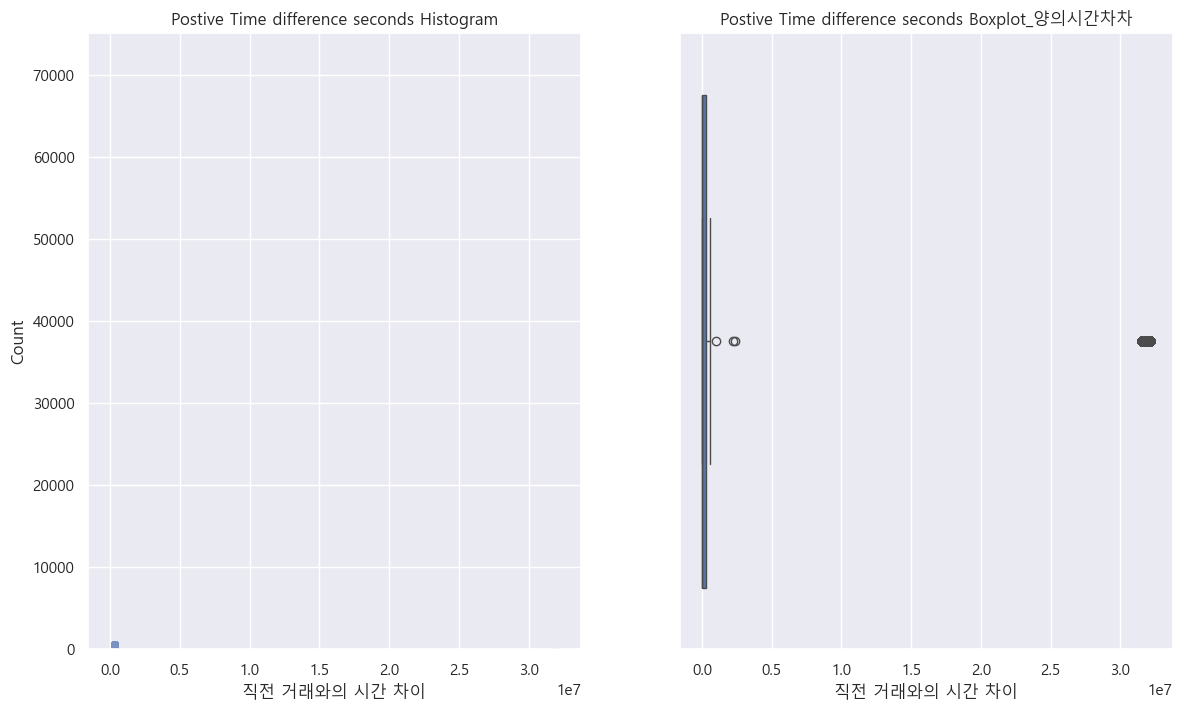

,직전 거래와의 시간 차이
count,1.198440e+05
mean,1.352704e+06
std,6.096397e+06
min,6.000000e+01
25%,4.700000e+03
50%,9.181500e+03
75%,3.038180e+05
max,3.214080e+07


In [80]:
fig, ax = plt.subplots(ncols=2, figsize=(14, 8))

sns.histplot(data=train_all_re_positive,
             x='직전 거래와의 시간 차이',
             ax=ax[0])

ax[0].set_title(f"Postive Time difference seconds Histogram")

sns.boxplot(data=train_all_re_positive,
             x='직전 거래와의 시간 차이',
             ax=ax[1])

ax[1].set_title(f"Postive Time difference seconds Boxplot_양의시간차차")

plt.show()

display(train_all_re_positive[['직전 거래와의 시간 차이']].describe())

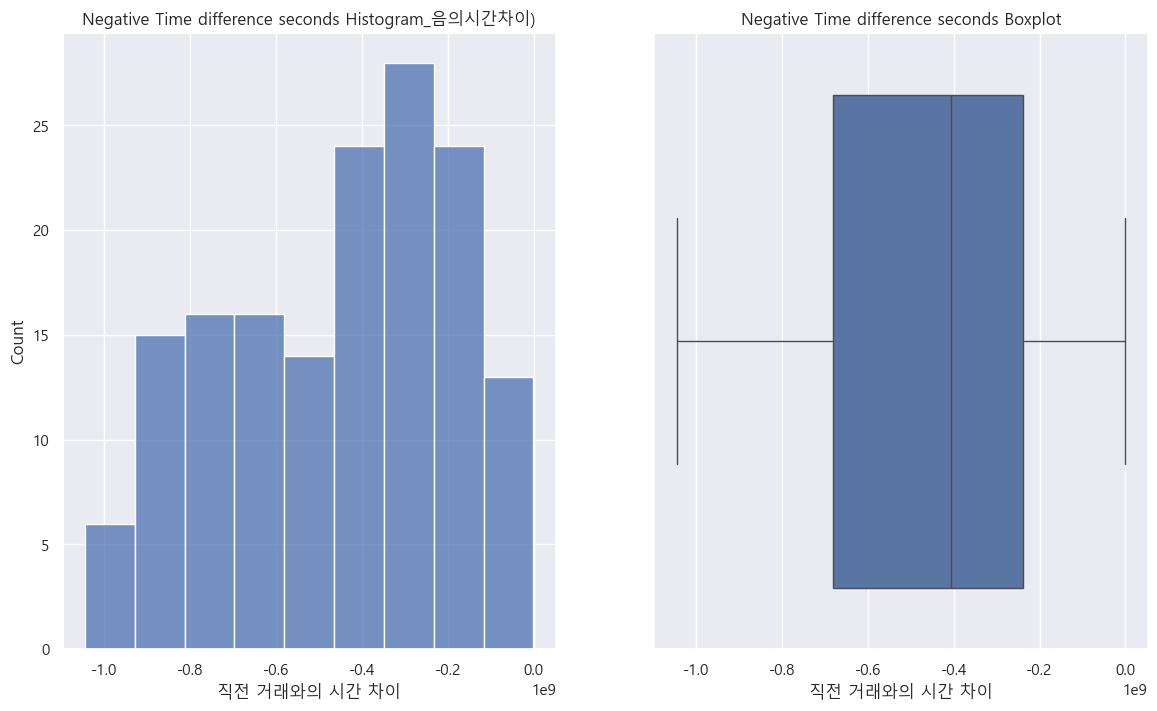

,직전 거래와의 시간 차이
count,1.560000e+02
mean,-4.562225e+08
std,2.677275e+08
min,-1.045256e+09
25%,-6.816409e+08
50%,-4.072373e+08
75%,-2.378106e+08
max,-3.671010e+05


In [79]:
fig, ax = plt.subplots(ncols=2, figsize=(14, 8))

sns.histplot(data=train_all_re_negative,
             x='직전 거래와의 시간 차이',
             ax=ax[0])

ax[0].set_title(f"Negative Time difference seconds Histogram_음의시간차이)")

sns.boxplot(data=train_all_re_negative,
             x='직전 거래와의 시간 차이',
             ax=ax[1])

ax[1].set_title(f"Negative Time difference seconds Boxplot")

plt.show()

display(train_all_re_negative[['직전 거래와의 시간 차이']].describe())

In [82]:
q3 = train_all_re_positive['직전 거래와의 시간 차이'].quantile(0.75)
q1 = train_all_re_positive['직전 거래와의 시간 차이'].quantile(0.25)

iqr = q3 - q1

upper_bound = q3 + 1.5 * iqr
lower_bound = q1 - 1.5 * iqr

train_all_positive_outlier = train_all_re_positive[(train_all_re_positive['직전 거래와의 시간 차이'] >= upper_bound)]
print(train_all_positive_outlier.shape[0])

4607


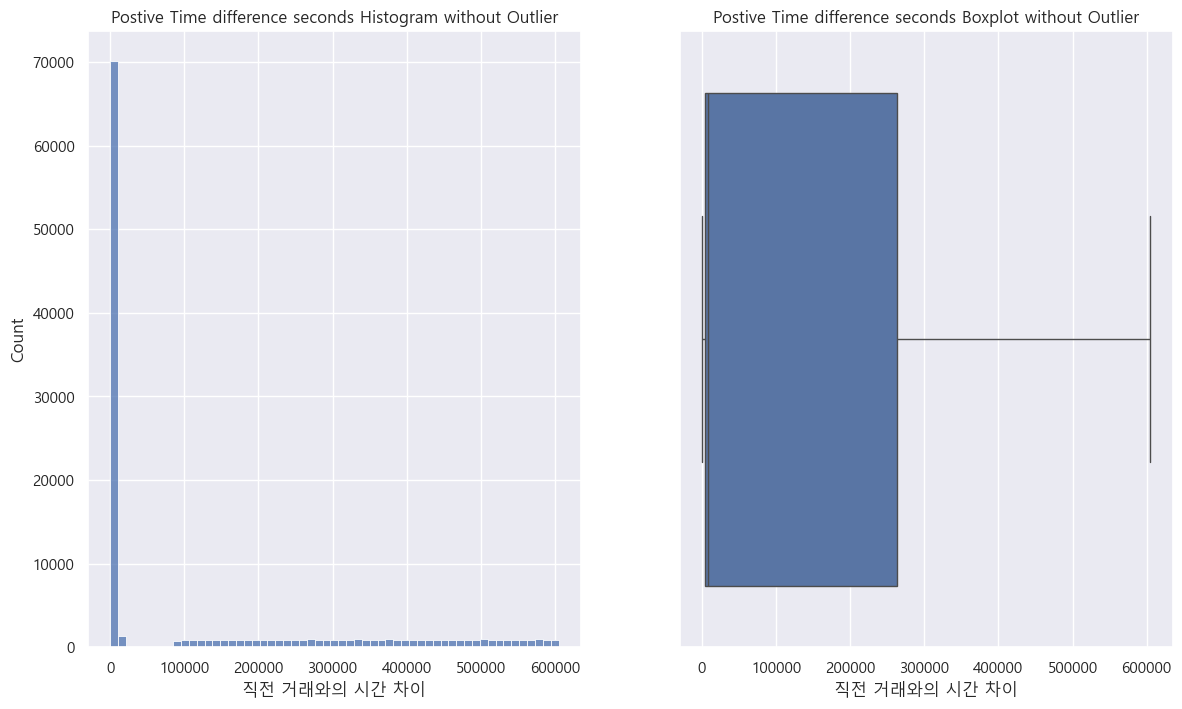

count    115237.000000
mean     134710.382629
std      189071.815258
min          60.000000
25%        4534.000000
50%        8845.000000
75%      263133.000000
max      604849.000000
Name: 직전 거래와의 시간 차이, dtype: float64

In [85]:
train_all_re_positive_normality = train_all_re_positive[(train_all_re_positive['직전 거래와의 시간 차이'] < upper_bound)]

fig, ax = plt.subplots(ncols=2, figsize=(14, 8))

sns.histplot(data=train_all_re_positive_normality,
             x='직전 거래와의 시간 차이',
             ax=ax[0])

ax[0].set_title(f"Postive Time difference seconds Histogram without Outlier")

sns.boxplot(data=train_all_re_positive_normality,
             x='직전 거래와의 시간 차이',
             ax=ax[1])

ax[1].set_title(f"Postive Time difference seconds Boxplot without Outlier")

plt.show()

display(train_all_re_positive_normality['직전 거래와의 시간 차이'].describe())

In [86]:
train_all_re.drop(columns=['직전 거래와의 시간 차이'], inplace=True)

## 이상 거래 변수

In [92]:
train_all['Fraud_Type'].value_counts().sort_index()

Fraud_Type
a       100
b       100
c       100
d       100
e       100
f       100
g       100
h       100
i       100
j       100
k       100
l       100
m    118800
Name: count, dtype: int64

In [96]:
train_all_re['사기 시나리오 (예측 목표)'] = train_all['Fraud_Type']

In [100]:
train_all_re_m = train_all_re[(train_all_re['사기 시나리오 (예측 목표)'] == 'm')]
train_all_re_non_m = train_all_re[(train_all_re['사기 시나리오 (예측 목표)'] != 'm')]

In [101]:
hue_order = ['a', 'b', 'c', 'd', 'e', 'f', 'g', 'h', 'i', 'j', 'k', 'l']

In [102]:
train_all_re['사기 시나리오 (예측 목표)']

0         m
1         m
2         m
3         m
4         m
         ..
119995    m
119996    m
119997    m
119998    m
119999    m
Name: 사기 시나리오 (예측 목표), Length: 120000, dtype: object

**사기 유형이 M인 경우** (아에 없는 데이터도 함께 고려할 것)
- Customer_credit_rating : S, D, E 경우가 상대적으로 적음
- Customer_flag_change_of_authentication_1 : 0인 경우가 상대적으로 적음
- Customer_flag_change_of_authentication_2 : 0인 경우가 상대적으로 적음
- Customer_flag_change_of_authentication_3 : 0인 경우가 상대적으로 적음
- Customer_flag_change_of_authentication_4 : 0인 경우가 상대적으로 적음
- Customer_rooting_jailbreak_indicator : 1인 경우가 상대적으로 적음
- Customer_mobile_roaming_indicator : 1인 경우가 상대적으로 적음
- Customer_VPN_Indicator : 1인 경우가 상대적으로 적음
- Customer_loan_type : e, d인 경우가 상대적으로 적음
- Customer_flag_terminal_malicious_behavior_1 : 1인 경우가 상대적으로 적음
- Customer_flag_terminal_malicious_behavior_2 : 1인 경우가 상대적으로 적음
- Customer_flag_terminal_malicious_behavior_3 : 1인 경우가 상대적으로 적음
- Customer_flag_terminal_malicious_behavior_4 : 1인 경우가 상대적으로 적음
- Customer_flag_terminal_malicious_behavior_5 : 1인 경우가 상대적으로 적음
- Customer_flag_terminal_malicious_behavior_6 : 1인 경우가 상대적으로 적음
- Customer_inquery_atm_limit : 0인 경우가 상대적으로 적음
- Customer_increase_atm_limit : 0인 경우가 상대적으로 적음
- Account_indicator_release_limit_excess : 1인 경우가 상대적으로 적음
- Account_indicator_Openbanking : 0인 경우가 상대적으로 적음
- Operating_System : Android, Linux, iOS, macOS인 경우가 상대적으로 적음
- Error_Code : c인 경우가 상대적으로 적음
-Transaction_Failure_Status : 1인 경우가 상대적으로 적음
- Type_General_Automatic : automatic인 경우가 상대적으로 적음
- Access_Medium : c, d, e, f, g인 경우가 상대적으로 적음
- Unused_terminal_status : 0인 경우가 상대적으로 적음
- First_time_iOS_by_vulnerable_user : 1인 경우가 상대적으로 적음


변수 명 : 고객 성별


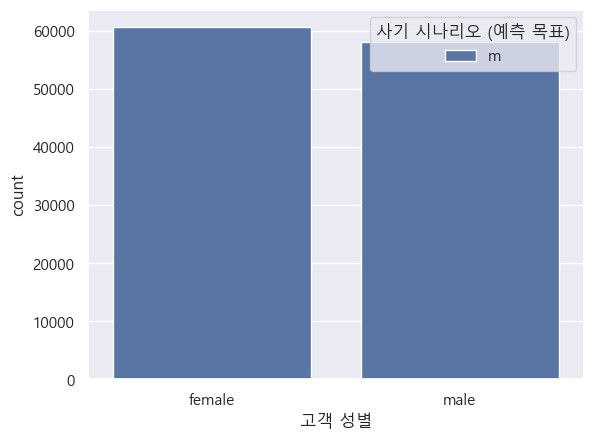


변수 명 : 고객 등급


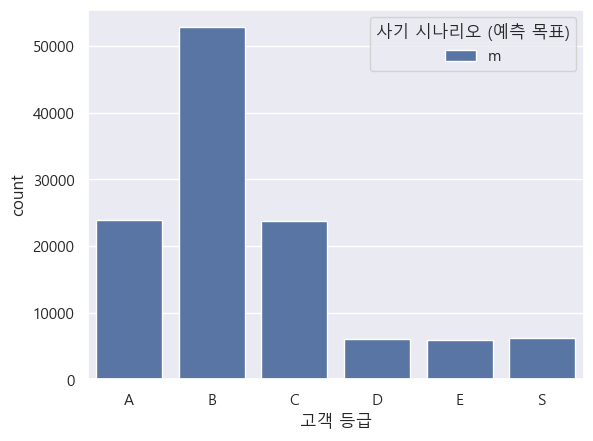


변수 명 : 3개월 이내 금융/공동인증서 발급 여부


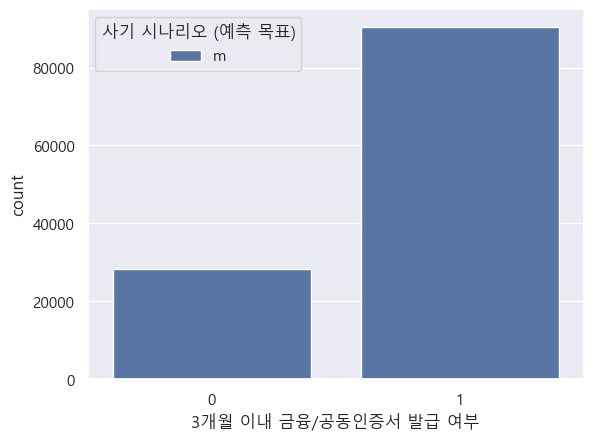


변수 명 : 3개월 이내 사설인증서 발급 여부


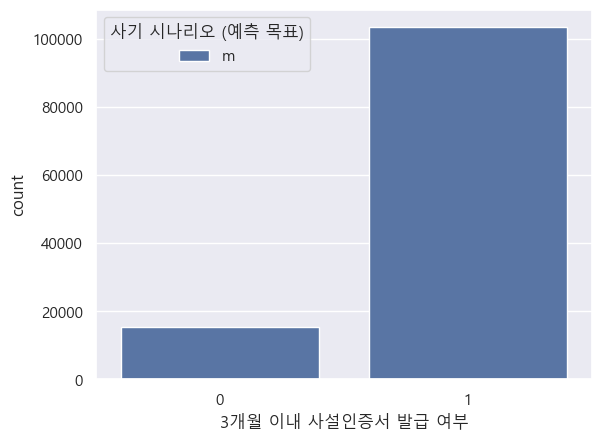


변수 명 : 3개월 이내 보안카드 및 OTP 발급 여부


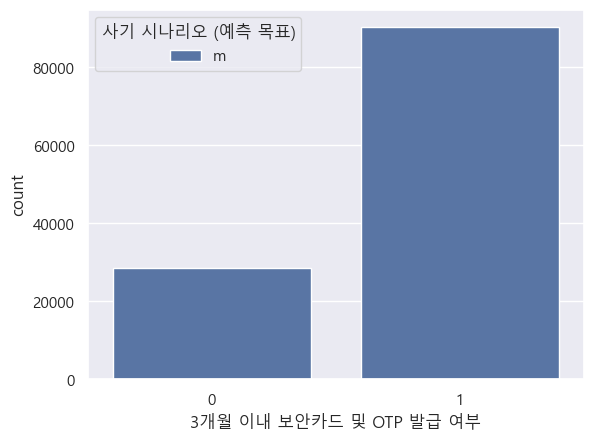


변수 명 : 3개월 이내 개인정보 수정 여부


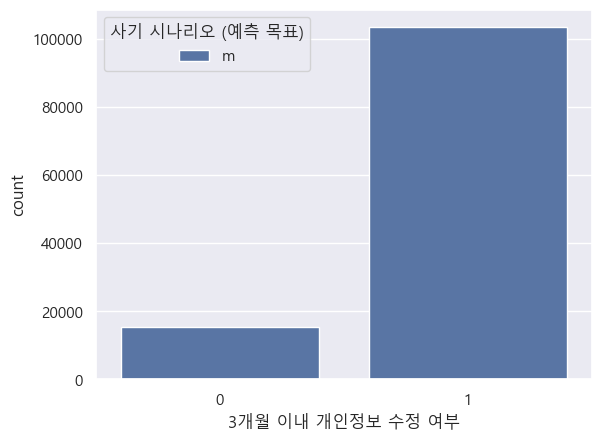


변수 명 : 탈옥 및 루팅 여부


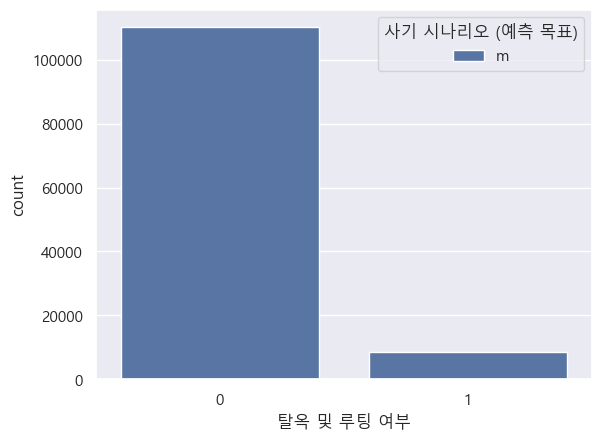


변수 명 : 모바일 로밍 여부


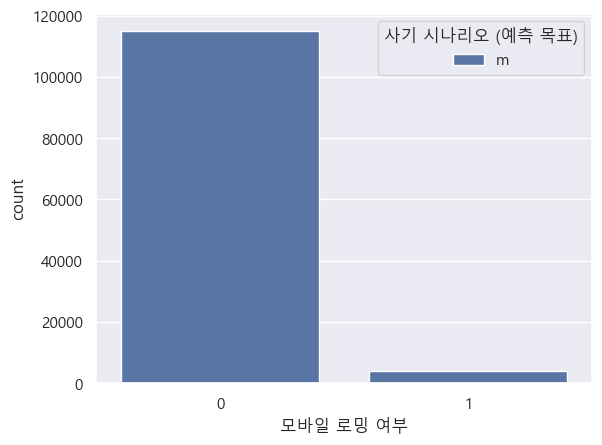


변수 명 : VPN 사용 여부


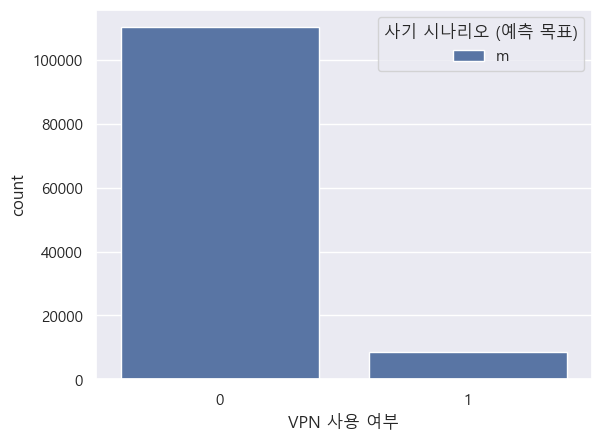


변수 명 : 대출 신청 유형(a: 없음, b: 신용대출, c: 담보대출, d: 할부금융, e: 기타)


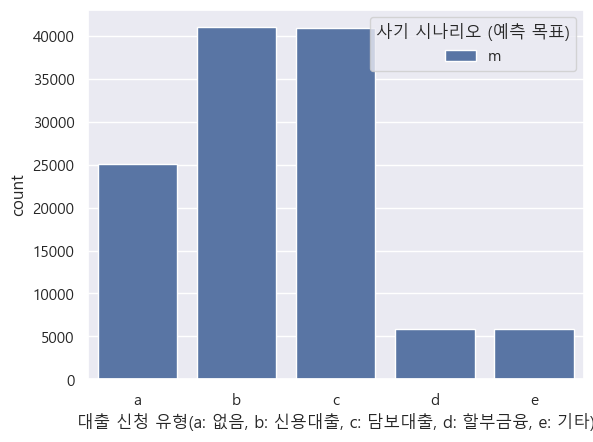


변수 명 : 전화번호 조작 여부


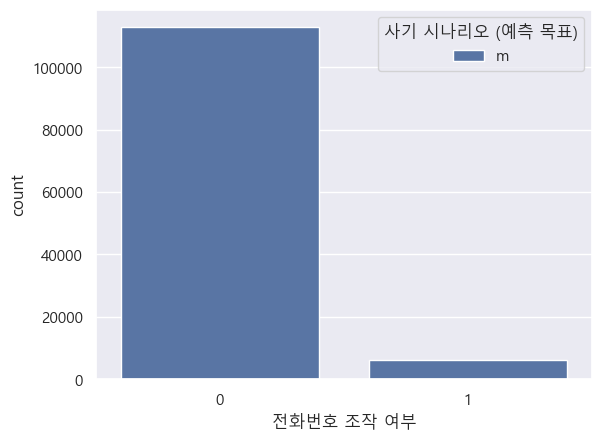


변수 명 : 원격제어 여부


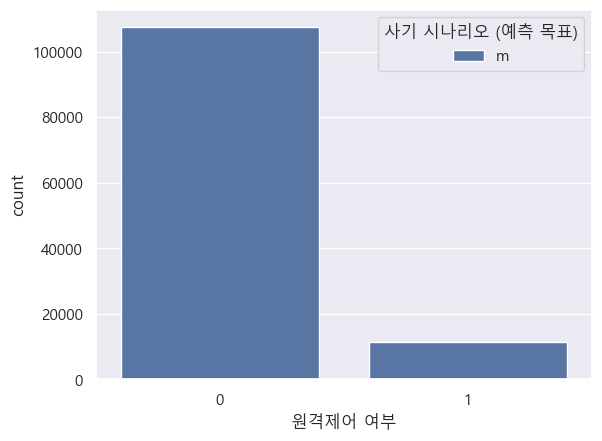


변수 명 : 템퍼링 여부


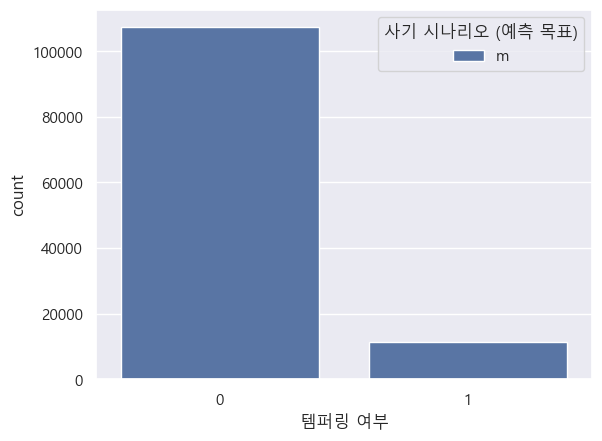


변수 명 : 피싱 여부


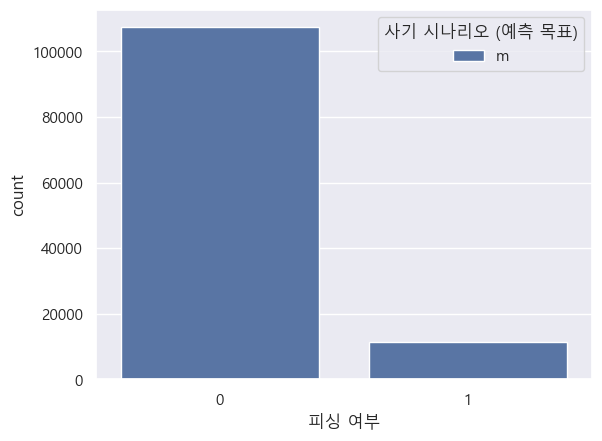


변수 명 : 신뢰할 수 없는 인증서 사용 여부


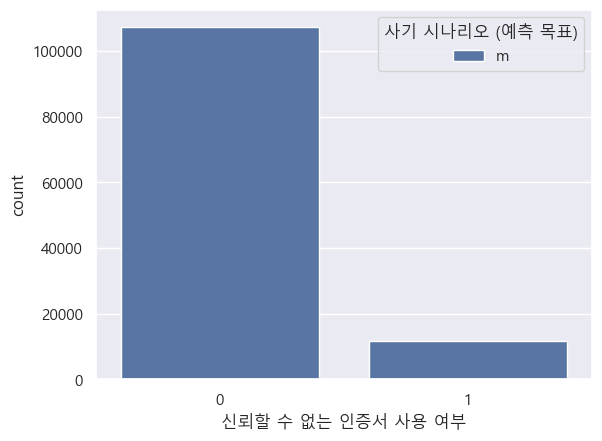


변수 명 : 키로깅 여부


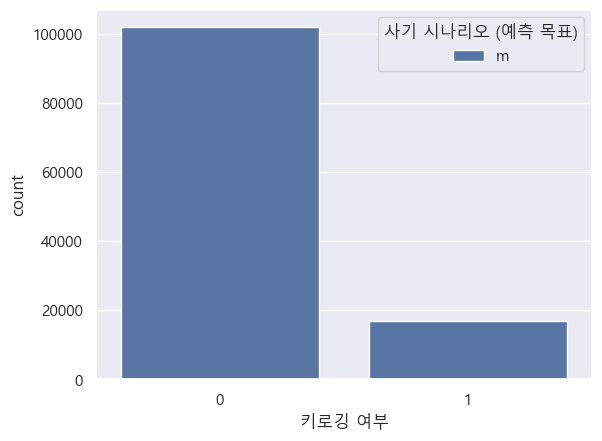


변수 명 : 7일 이내 ATM 한도 문의 여부


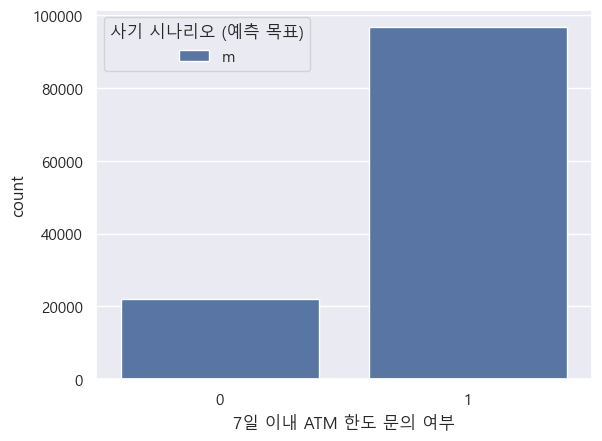


변수 명 : 7일 이내 ATM 한도 증액 여부


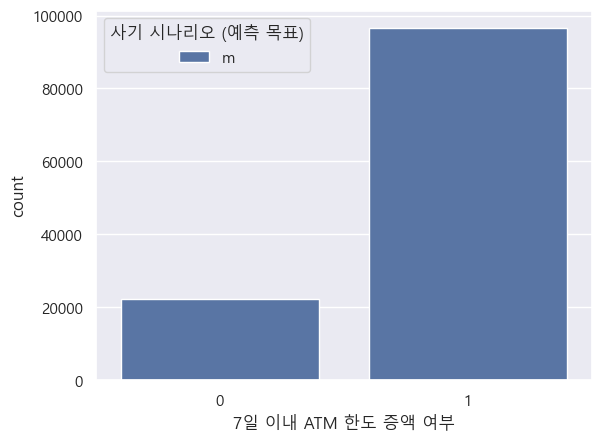


변수 명 : 계좌유형(a: 입출금계좌, b: CMA, c: ISA, d: 저축계좌)


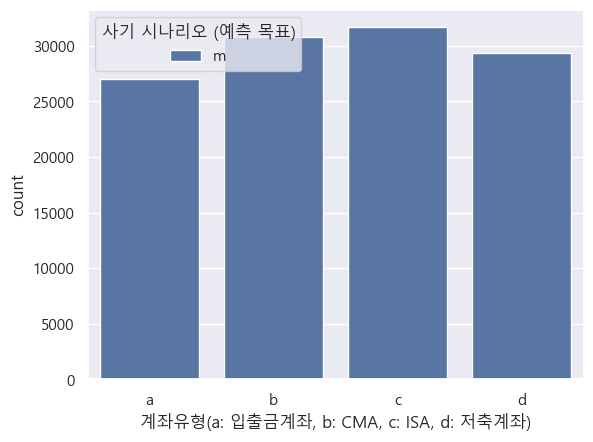


변수 명 : 거래한도 증가 여부


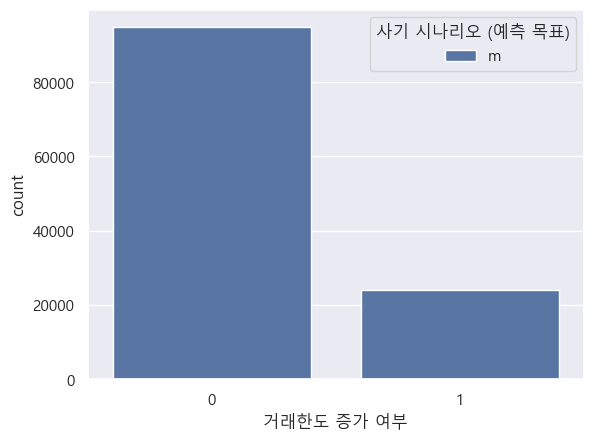


변수 명 : 오픈뱅킹 사용 여부


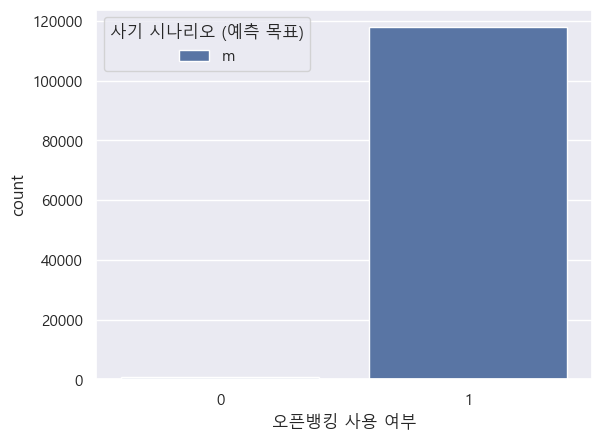


변수 명 : 30일 이내 계좌 정지 해제 여부


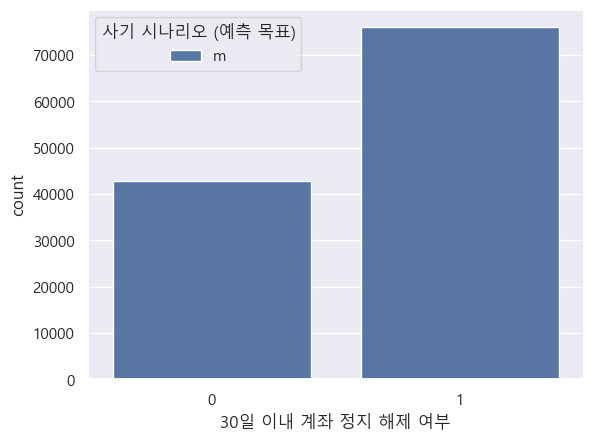


변수 명 : 거래 채널


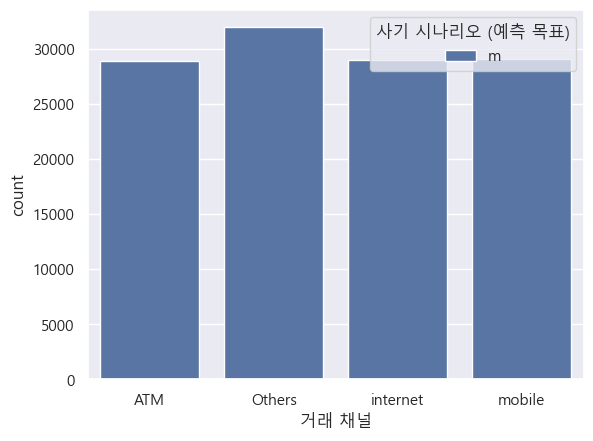


변수 명 : 거래에 사용한 단말기 OS


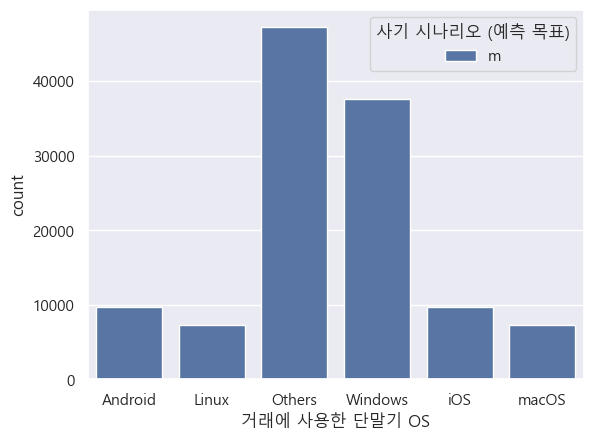


변수 명 : 에러코드(a: 에러없음, b: 시스템 오류, c: 잔액부족, d: 이체한도초과, e: 계좌정보 오류, f: 계좌이체 거부)


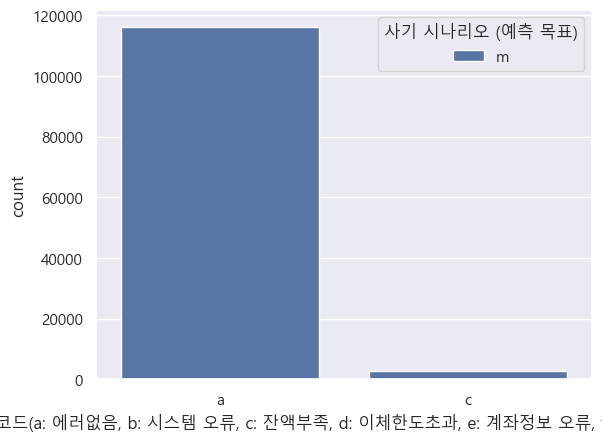


변수 명 : 거래 성공/실패 여부


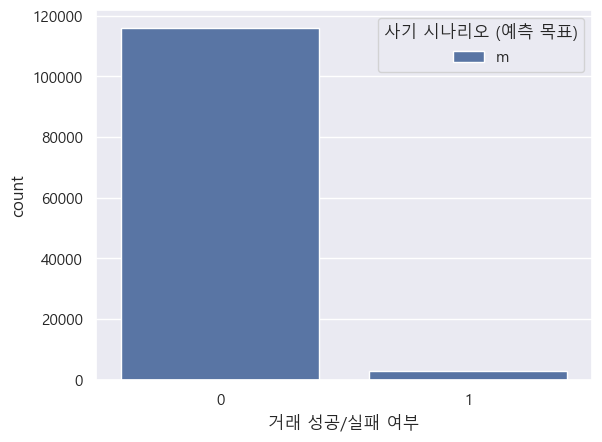


변수 명 : 자동이체(automatic) 또는 일반거래(general)


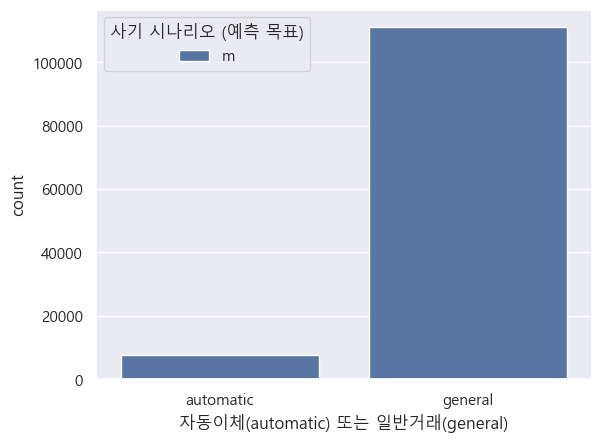


변수 명 : 거래 시스템 접근 매체(a: ID/PW 로그인, b: 패턴, c: 생체로그인, d: 금융/공동 인증서, e: 사설인증서, f: 보안카드, g: OTP, h: 보안카드+OTP)


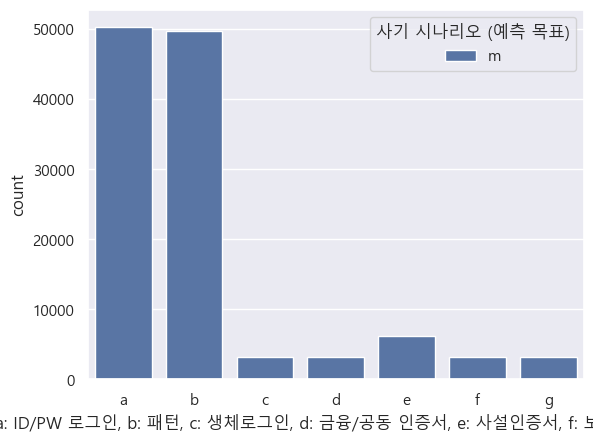


변수 명 : 타계좌 여부


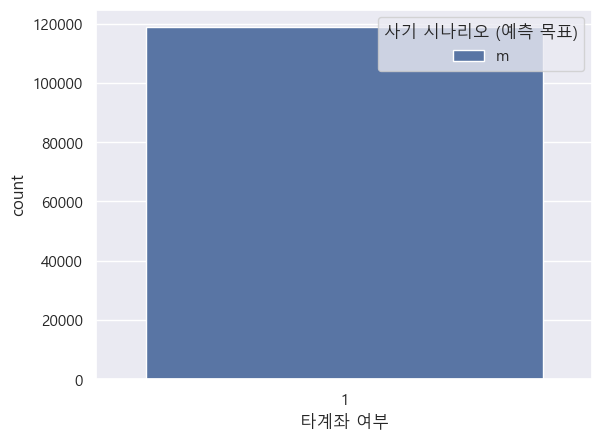


변수 명 : 7일 거래내역 중 미사용 단말 여부


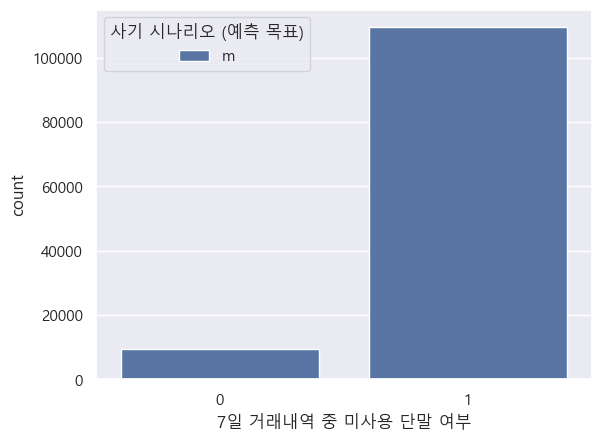


변수 명 : 7일 거래내역 중 1천만원 이상 입금 여부


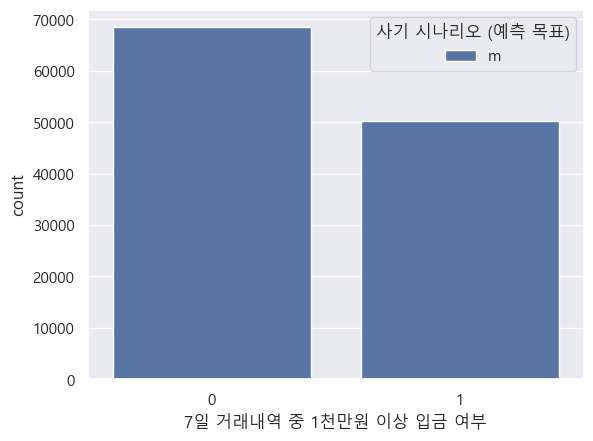


변수 명 : 7일 거래내역 중 미거래 계좌 여부


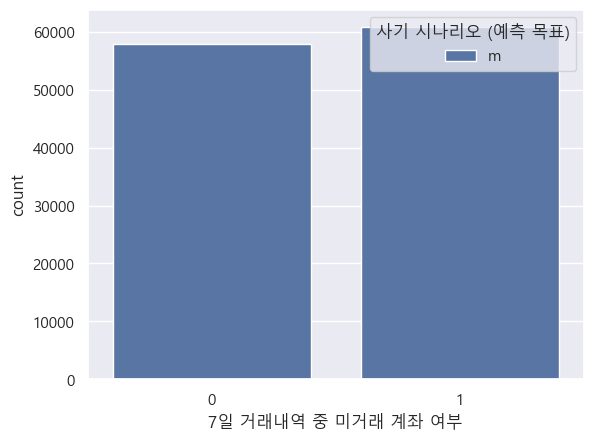


변수 명 : 수취계좌의 거래중지계좌 해당 여부


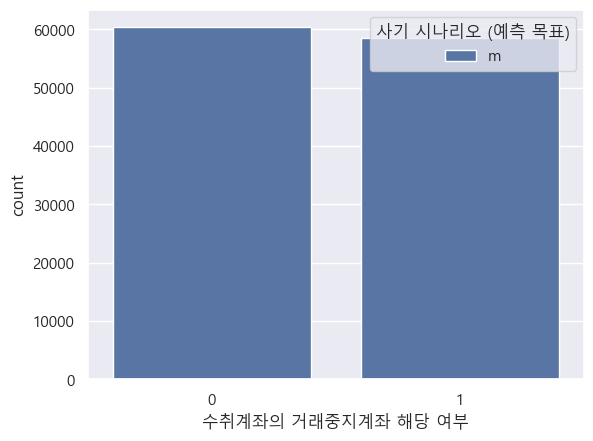


변수 명 : 60세 이후 iOS 첫 사용자


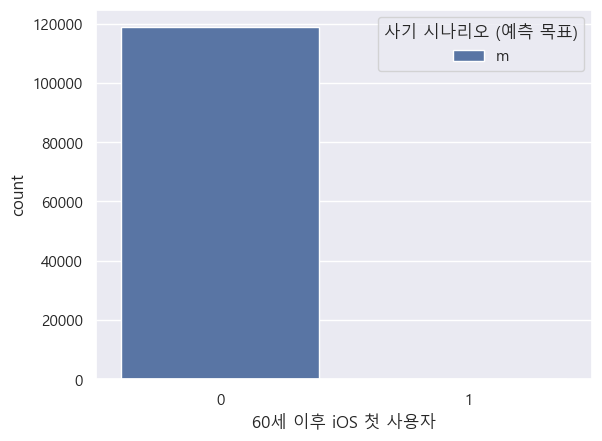


변수 명 : 사기 시나리오 (예측 목표)


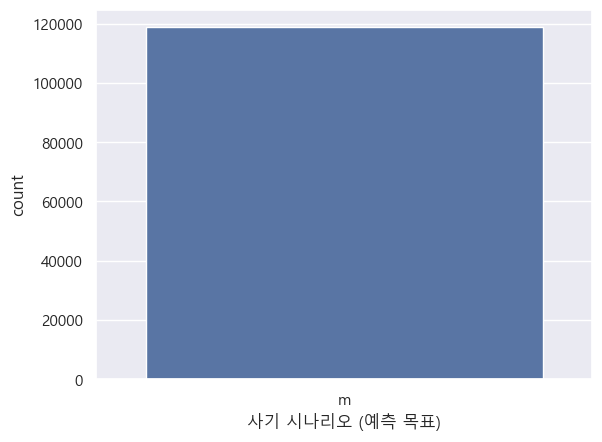

In [106]:
for column, col_type, col_range in zip(cond_all['항목 설명'],
                                       cond_all['데이터 형태'],
                                       cond_all['데이터 범위']):

  if col_type == '범주형' and col_range != '-' and column != 'Fraud_Type':
     print(f'변수 명 : {column}')

     order = list(train_all_re_m[column].unique())
     order = sorted(order)

     sns.countplot(data=train_all_re_m,
                 x=column,
                 hue='사기 시나리오 (예측 목표)',
                 order=order)
     plt.show()

     print()

변수 명 : 고객 성별


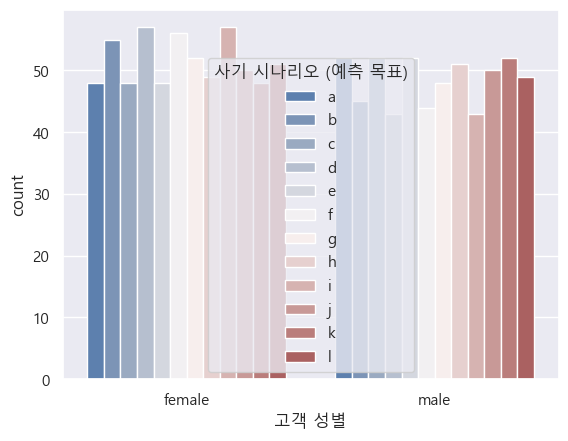


변수 명 : 고객 등급


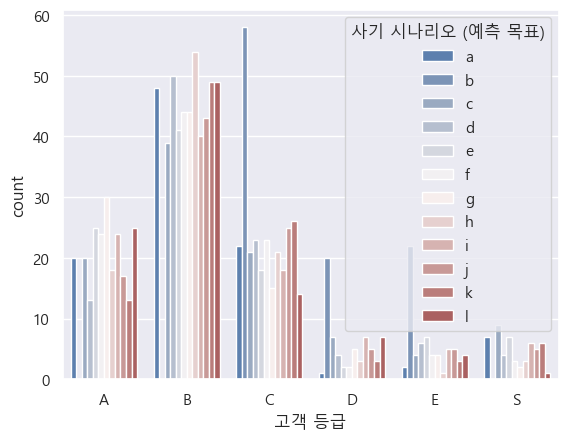


변수 명 : 3개월 이내 금융/공동인증서 발급 여부


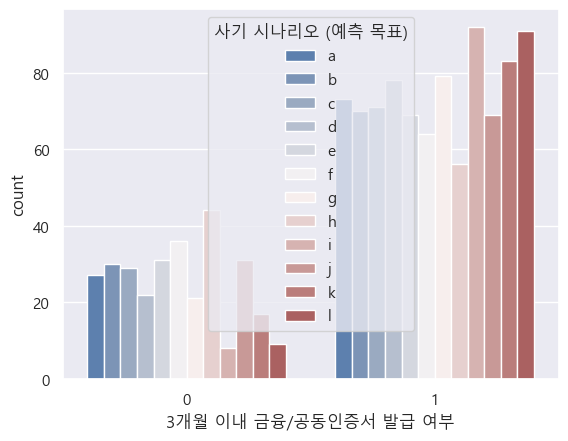


변수 명 : 3개월 이내 사설인증서 발급 여부


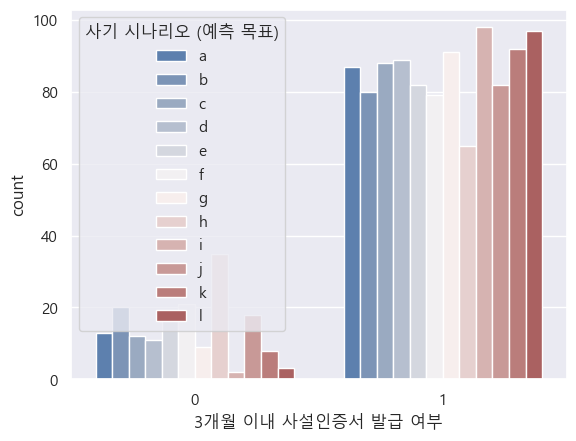


변수 명 : 3개월 이내 보안카드 및 OTP 발급 여부


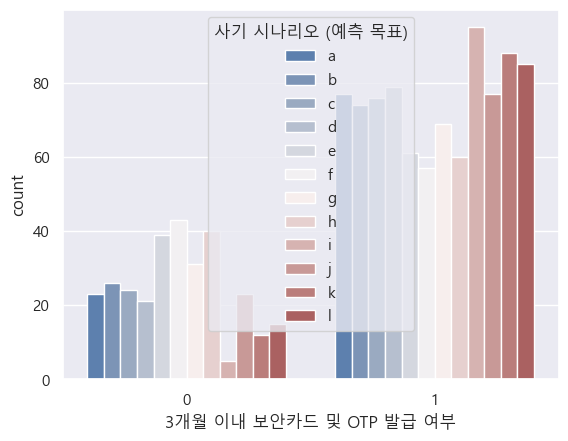


변수 명 : 3개월 이내 개인정보 수정 여부


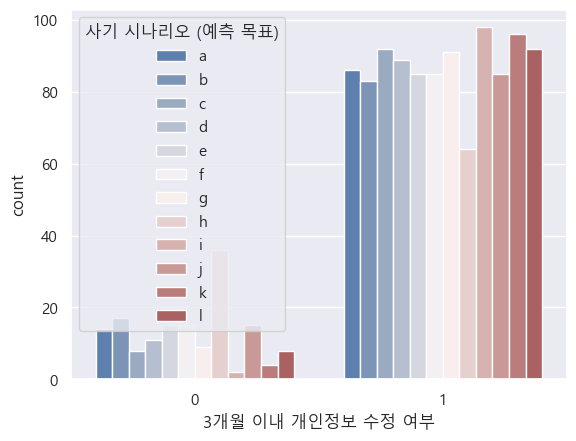


변수 명 : 탈옥 및 루팅 여부


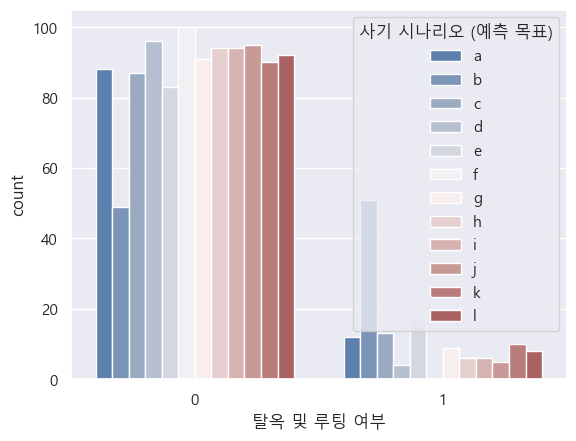


변수 명 : 모바일 로밍 여부


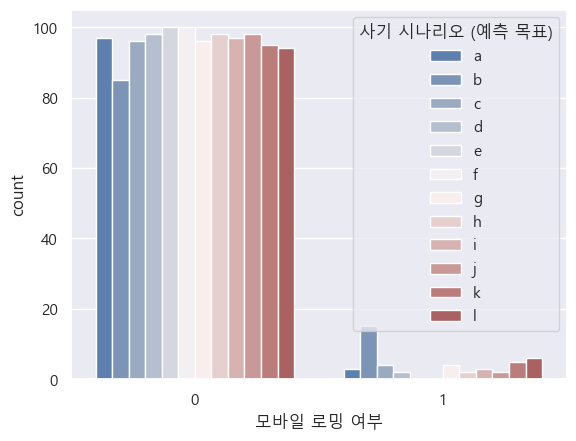


변수 명 : VPN 사용 여부


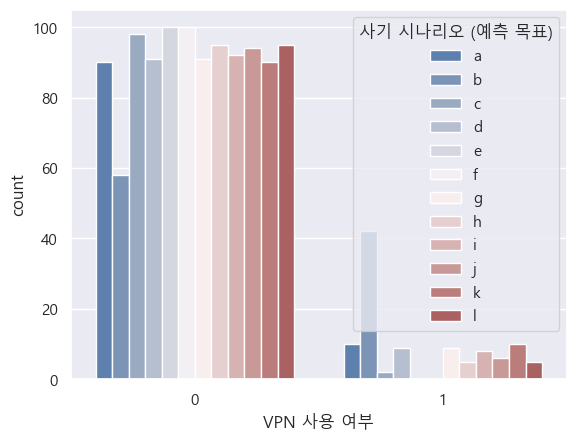


변수 명 : 대출 신청 유형(a: 없음, b: 신용대출, c: 담보대출, d: 할부금융, e: 기타)


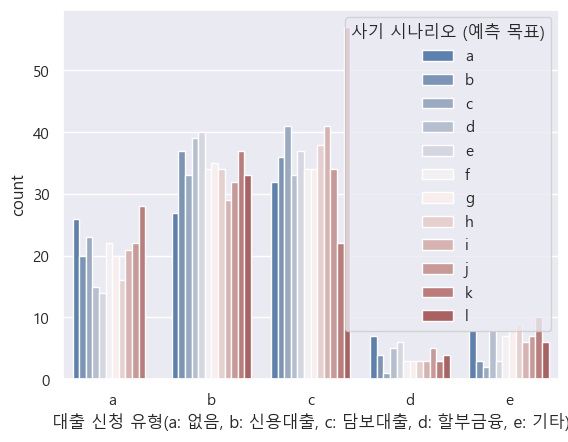


변수 명 : 전화번호 조작 여부


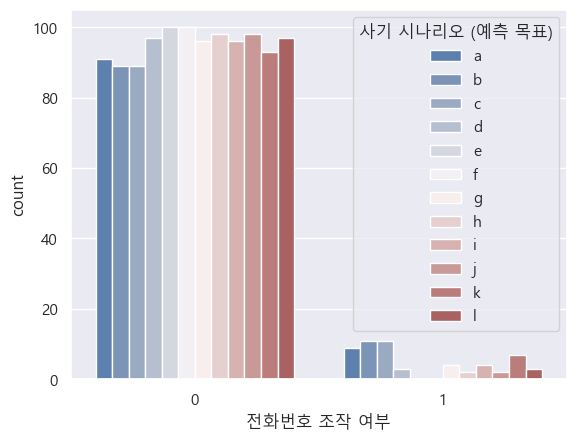


변수 명 : 원격제어 여부


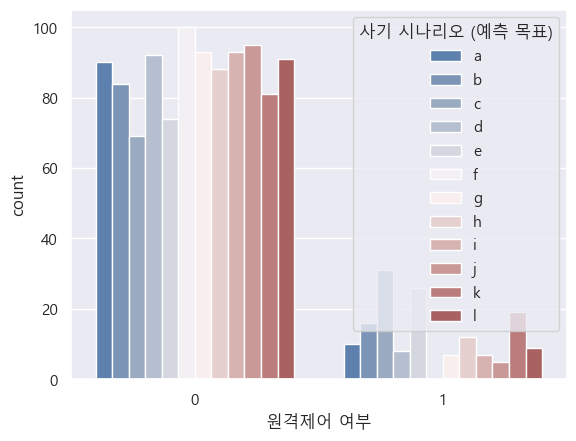


변수 명 : 템퍼링 여부


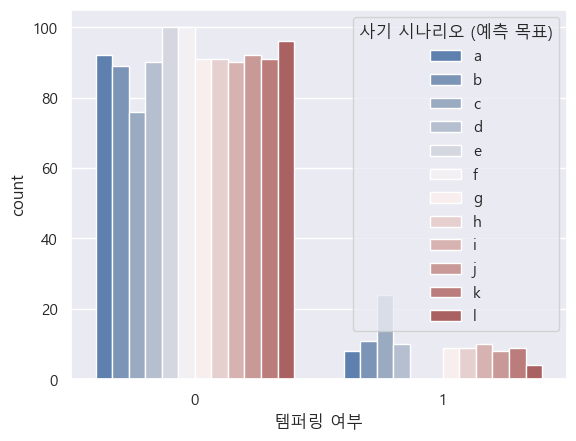


변수 명 : 피싱 여부


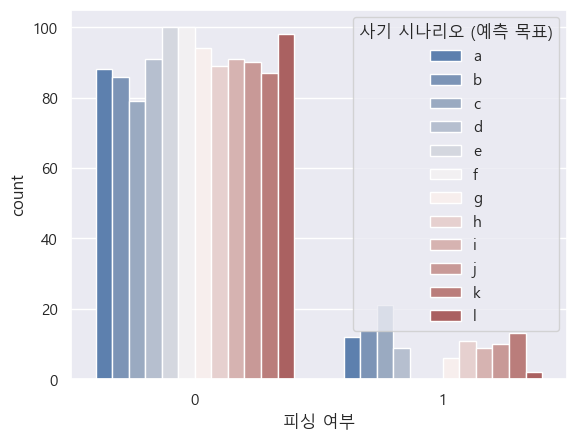


변수 명 : 신뢰할 수 없는 인증서 사용 여부


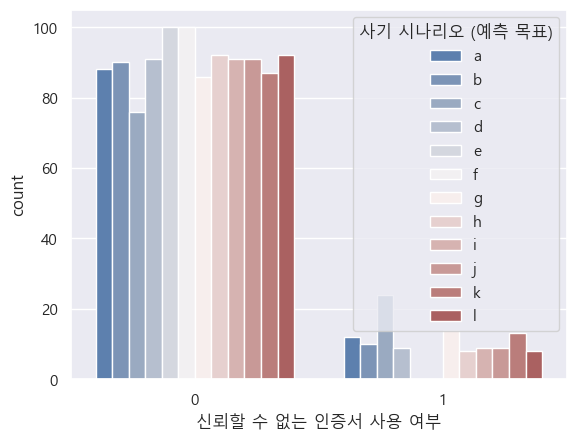


변수 명 : 키로깅 여부


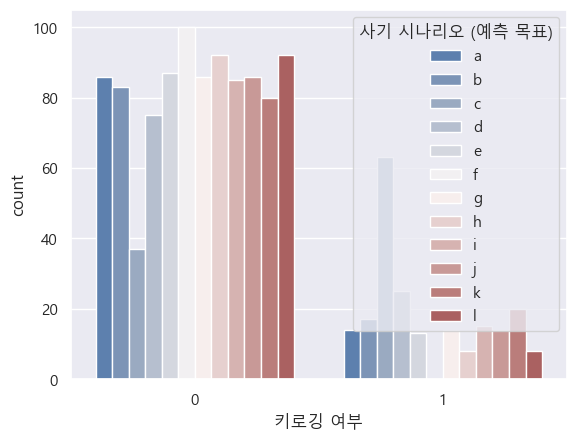


변수 명 : 7일 이내 ATM 한도 문의 여부


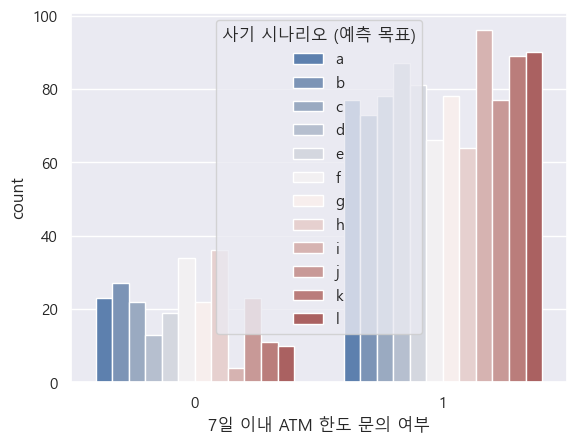


변수 명 : 7일 이내 ATM 한도 증액 여부


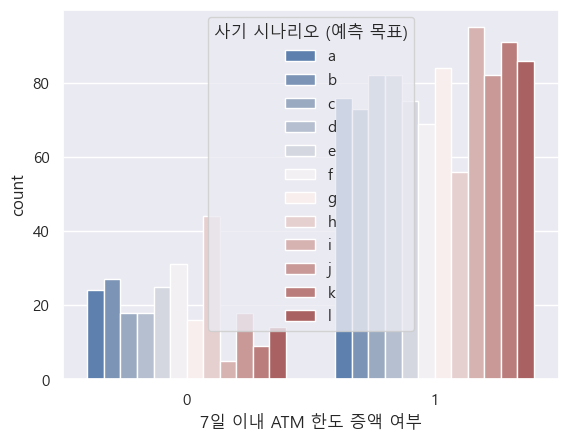


변수 명 : 계좌유형(a: 입출금계좌, b: CMA, c: ISA, d: 저축계좌)


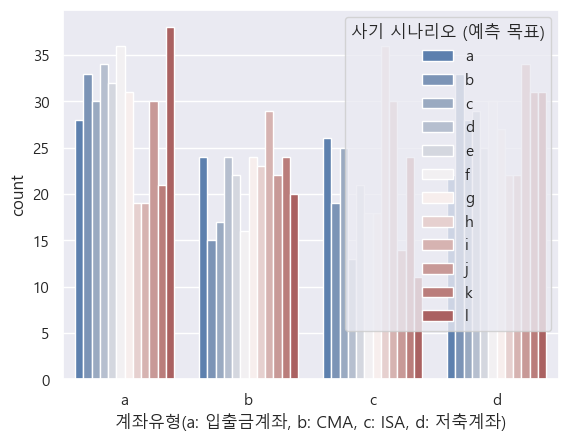


변수 명 : 거래한도 증가 여부


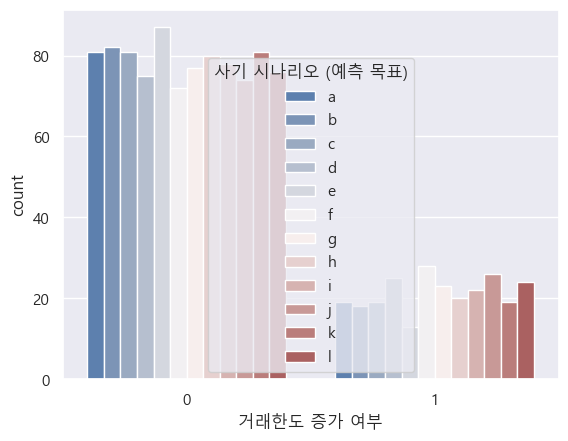


변수 명 : 오픈뱅킹 사용 여부


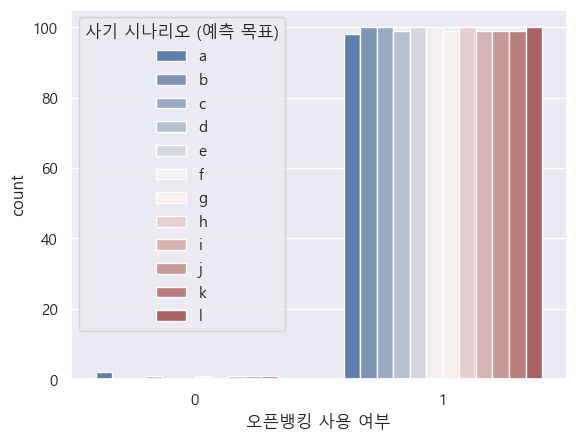


변수 명 : 30일 이내 계좌 정지 해제 여부


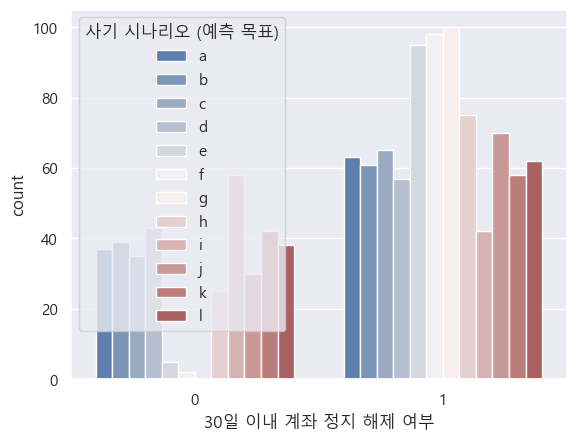


변수 명 : 거래 채널


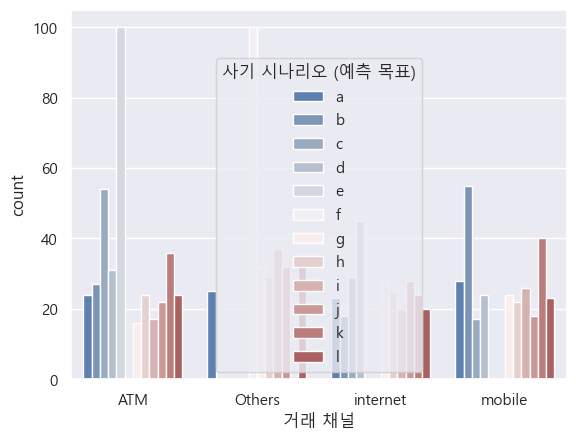


변수 명 : 거래에 사용한 단말기 OS


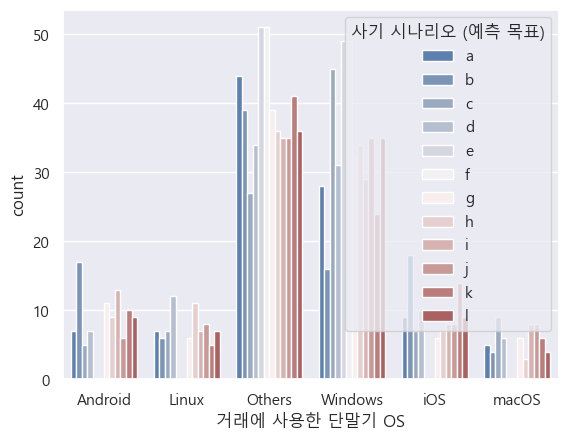


변수 명 : 에러코드(a: 에러없음, b: 시스템 오류, c: 잔액부족, d: 이체한도초과, e: 계좌정보 오류, f: 계좌이체 거부)


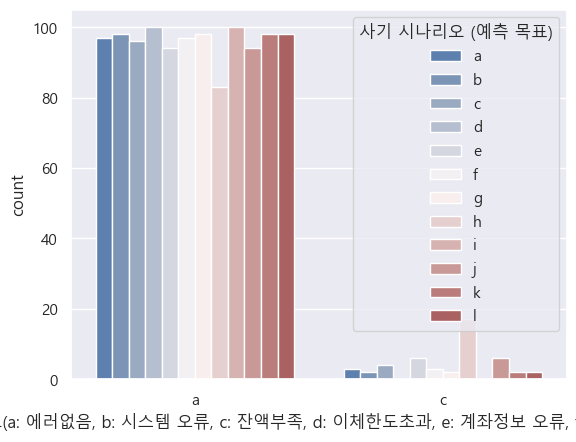


변수 명 : 거래 성공/실패 여부


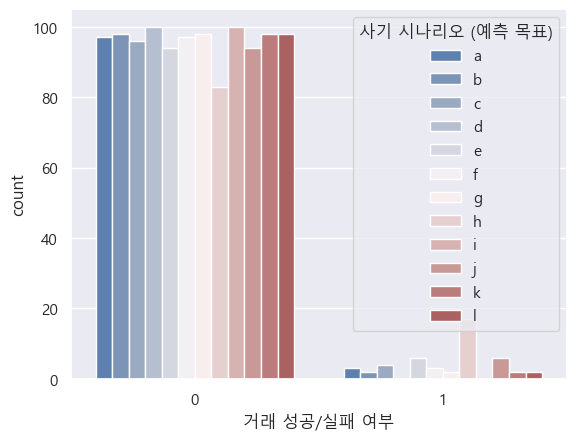


변수 명 : 자동이체(automatic) 또는 일반거래(general)


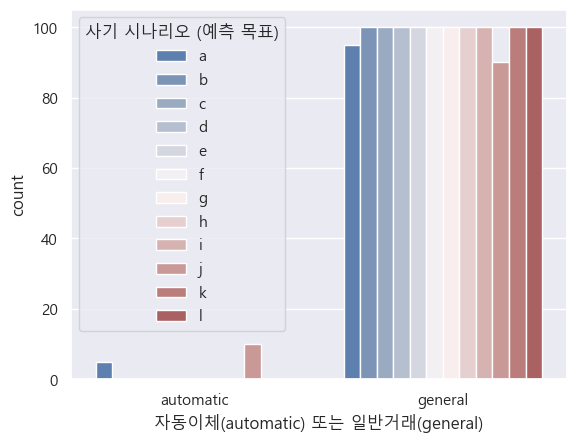


변수 명 : 거래 시스템 접근 매체(a: ID/PW 로그인, b: 패턴, c: 생체로그인, d: 금융/공동 인증서, e: 사설인증서, f: 보안카드, g: OTP, h: 보안카드+OTP)


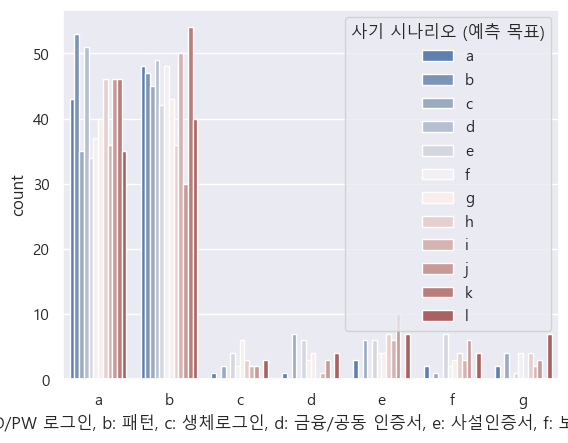


변수 명 : 타계좌 여부


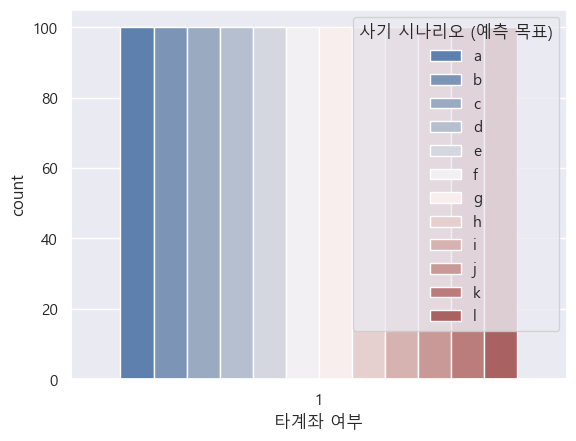


변수 명 : 7일 거래내역 중 미사용 단말 여부


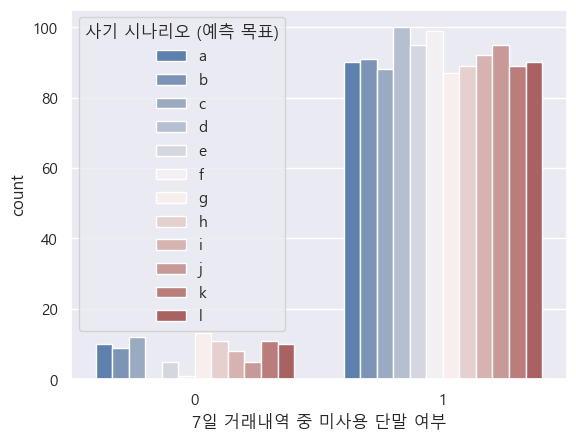


변수 명 : 7일 거래내역 중 1천만원 이상 입금 여부


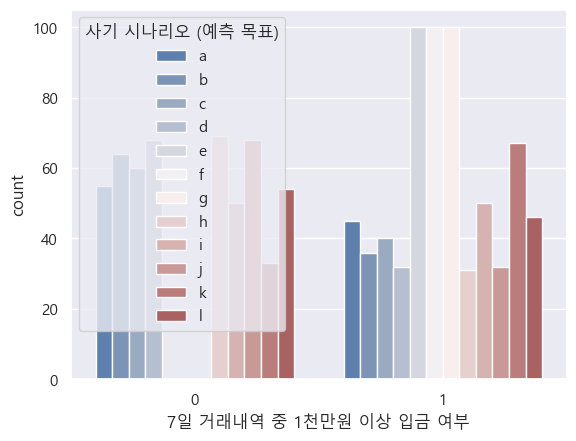


변수 명 : 7일 거래내역 중 미거래 계좌 여부


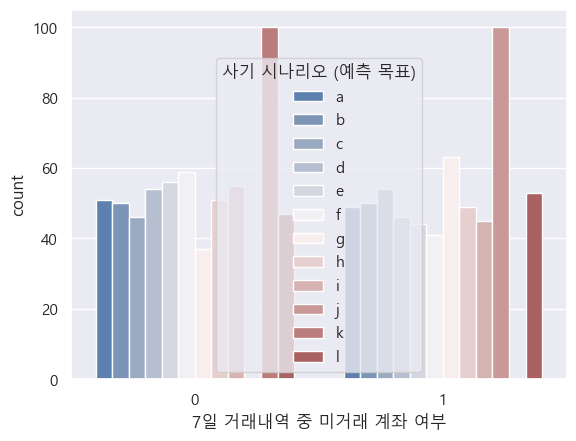


변수 명 : 수취계좌의 거래중지계좌 해당 여부


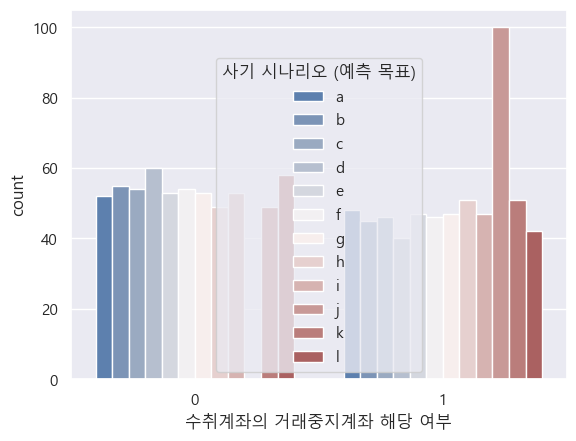


변수 명 : 60세 이후 iOS 첫 사용자


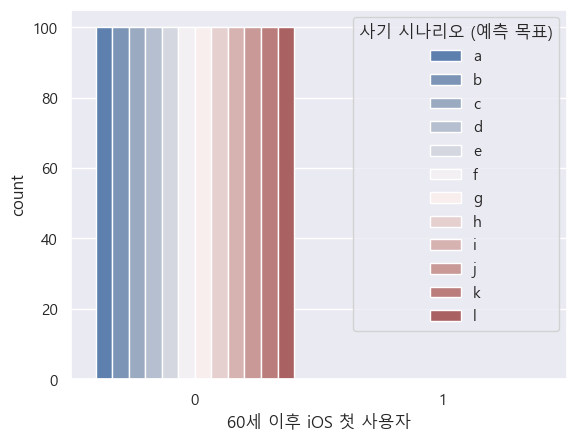

In [108]:
for column, col_type, col_range in zip(cond_all['항목 설명'],
                                       cond_all['데이터 형태'],
                                       cond_all['데이터 범위']):

  if col_type == '범주형' and col_range != '-' and column != '사기 시나리오 (예측 목표)':
     print(f'변수 명 : {column}')

     order = list(train_all_re_m[column].unique())
     order = sorted(order)

     sns.countplot(data=train_all_re_non_m,
                    x=column,
                    hue='사기 시나리오 (예측 목표)',
                    palette='vlag',
                    hue_order=hue_order,
                    order=order)

     plt.show()

     print()

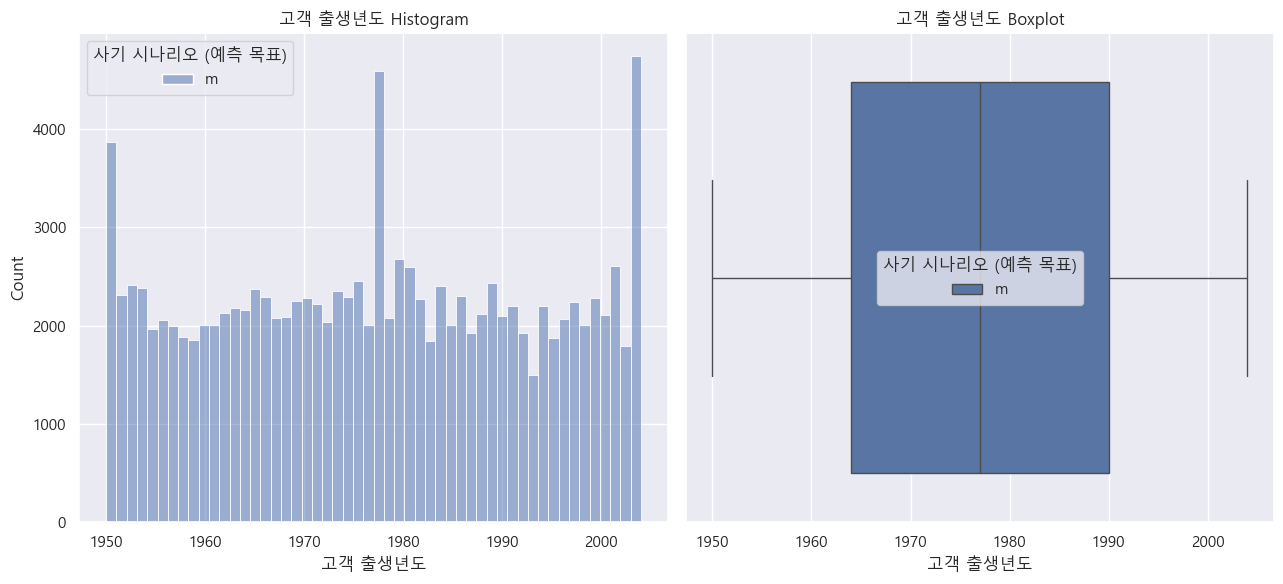

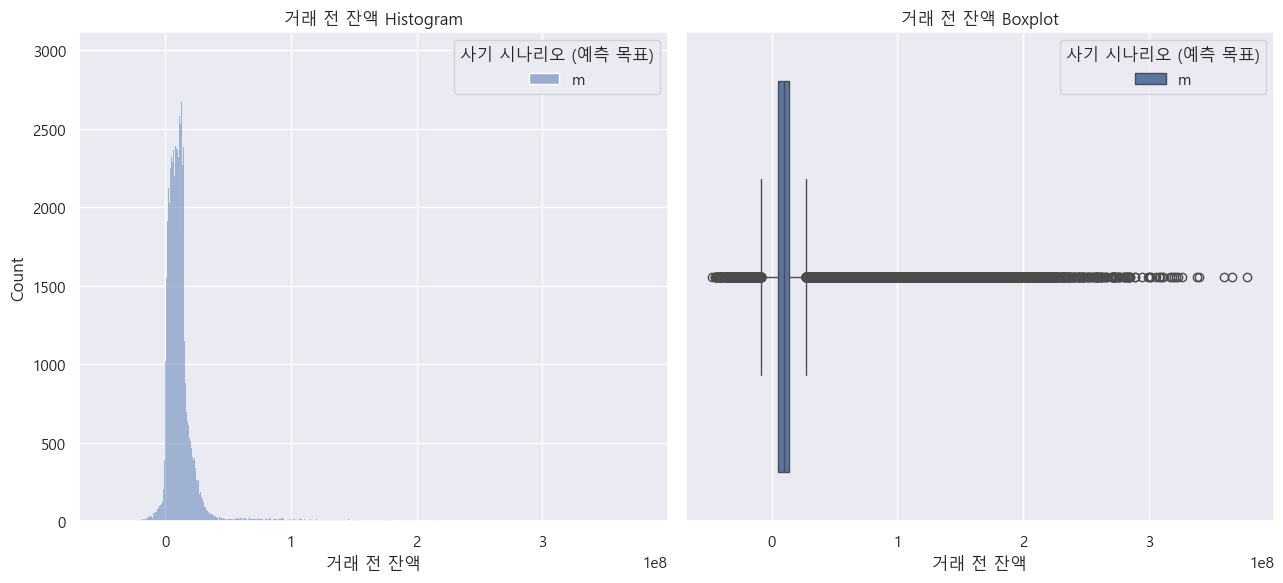

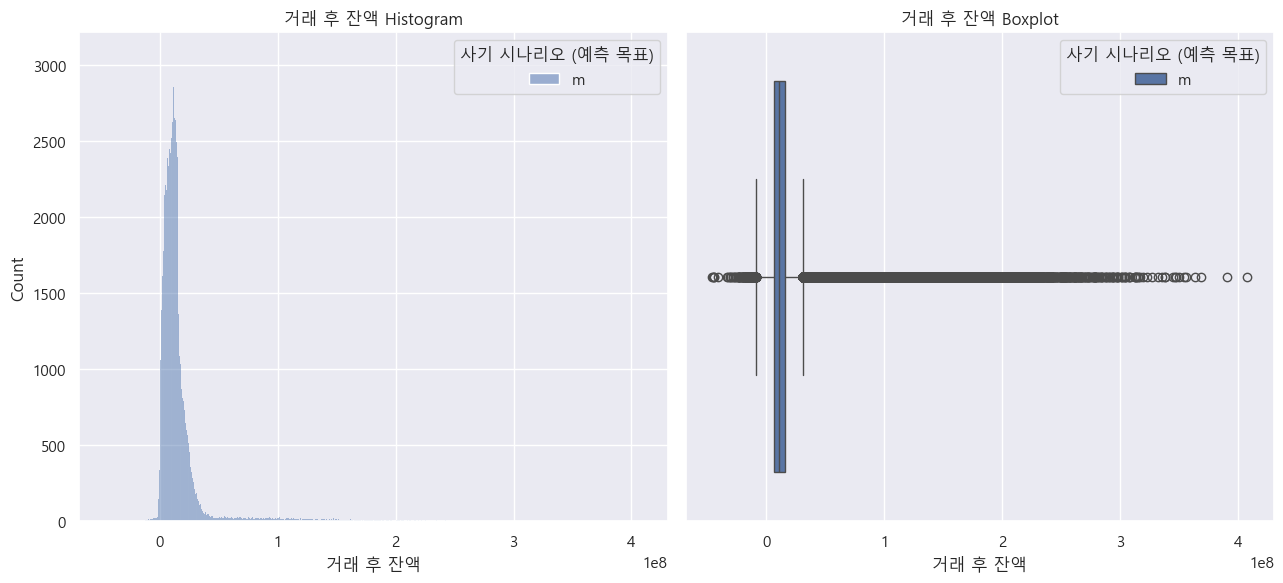

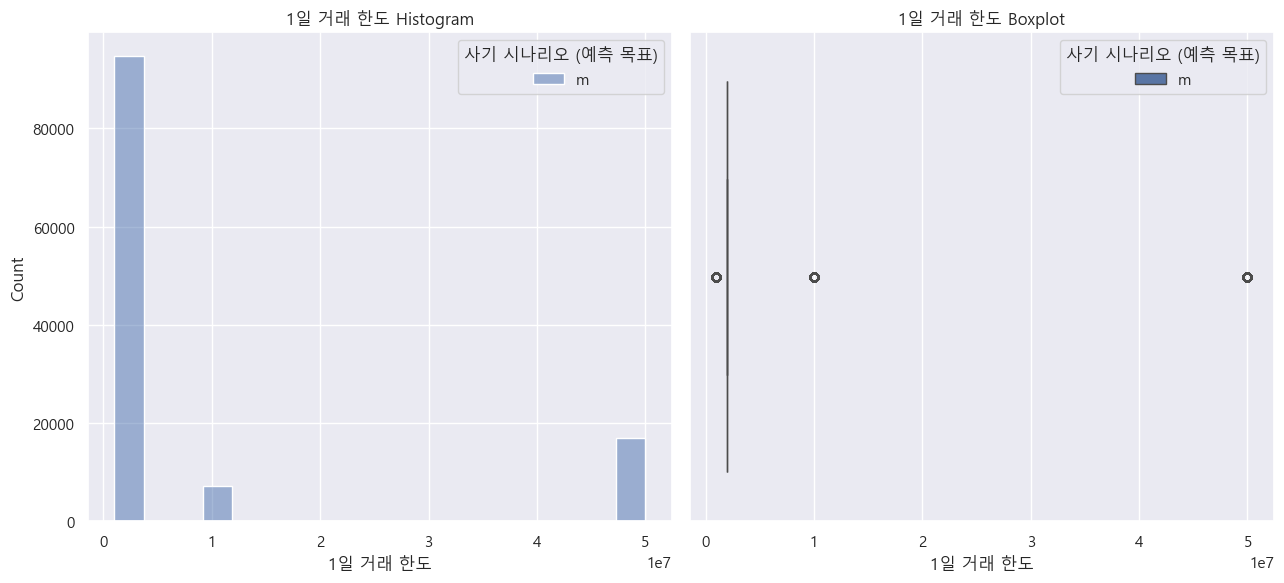

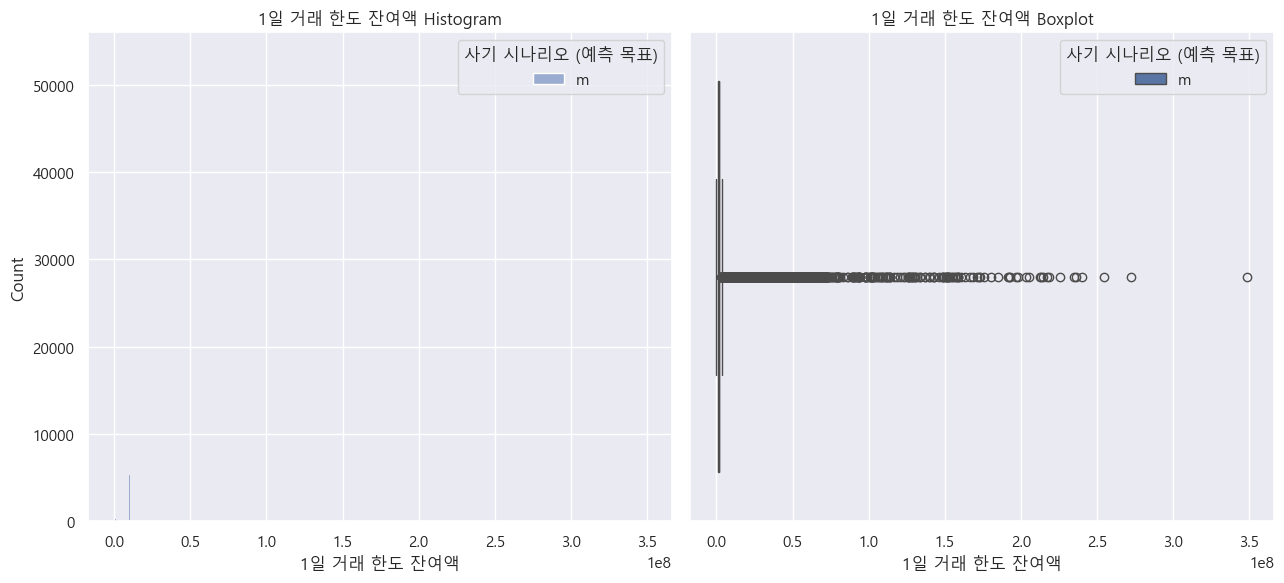

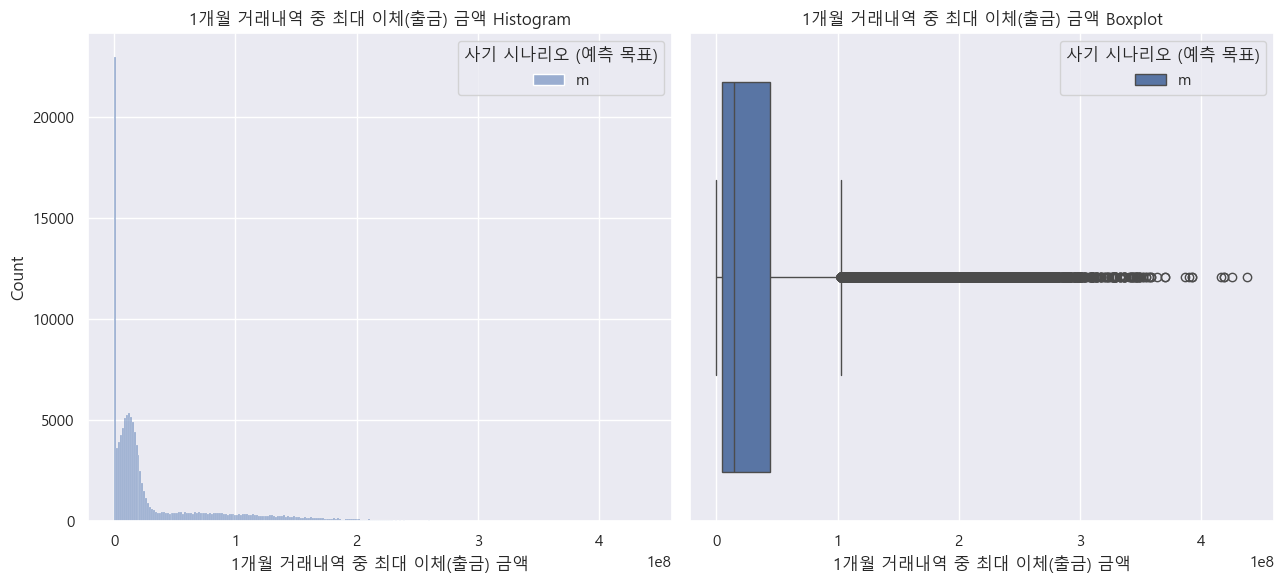

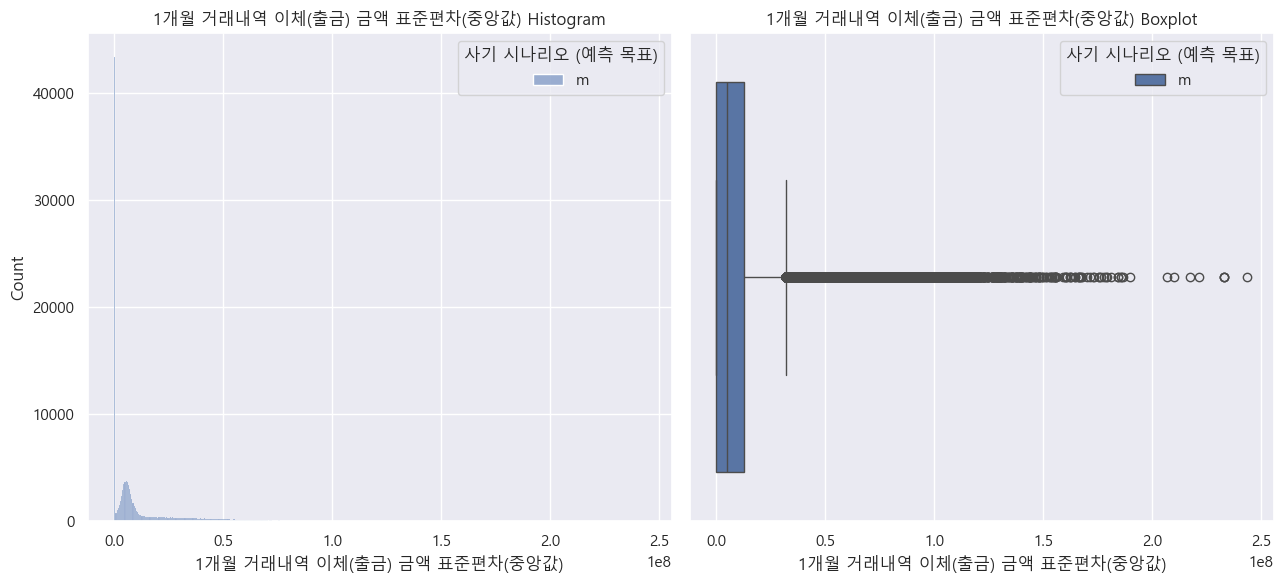

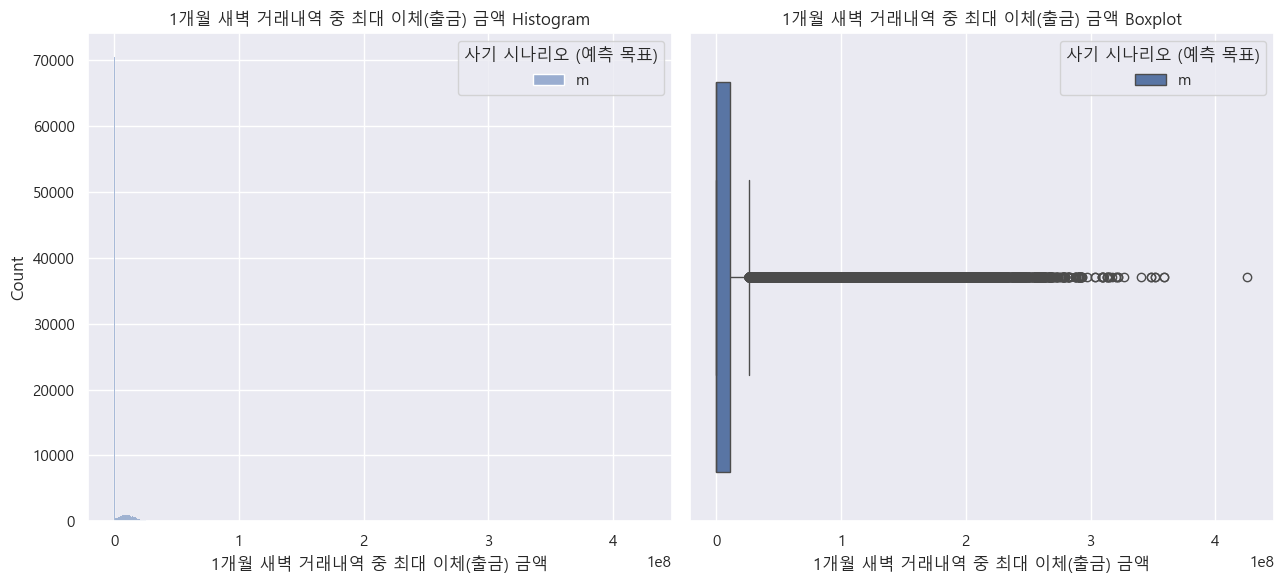

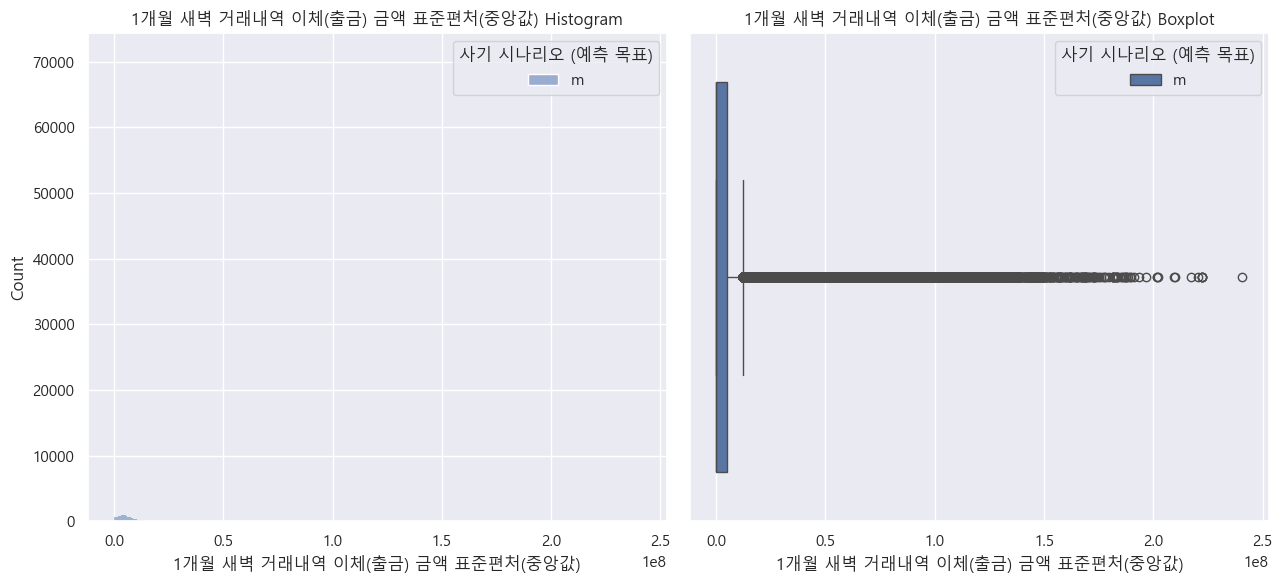

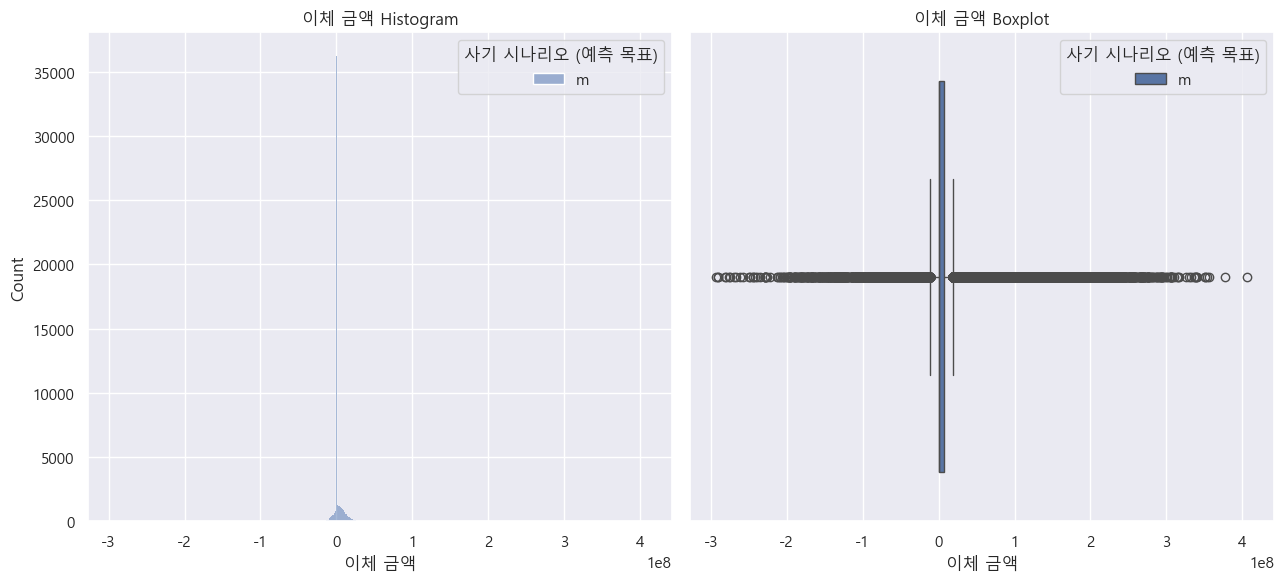

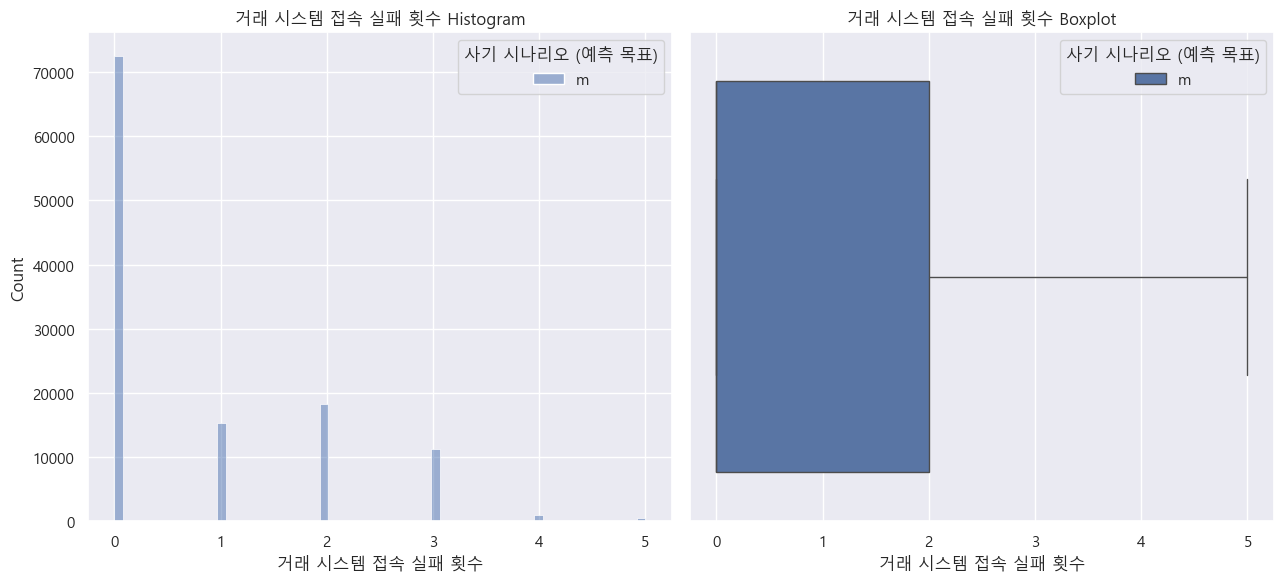

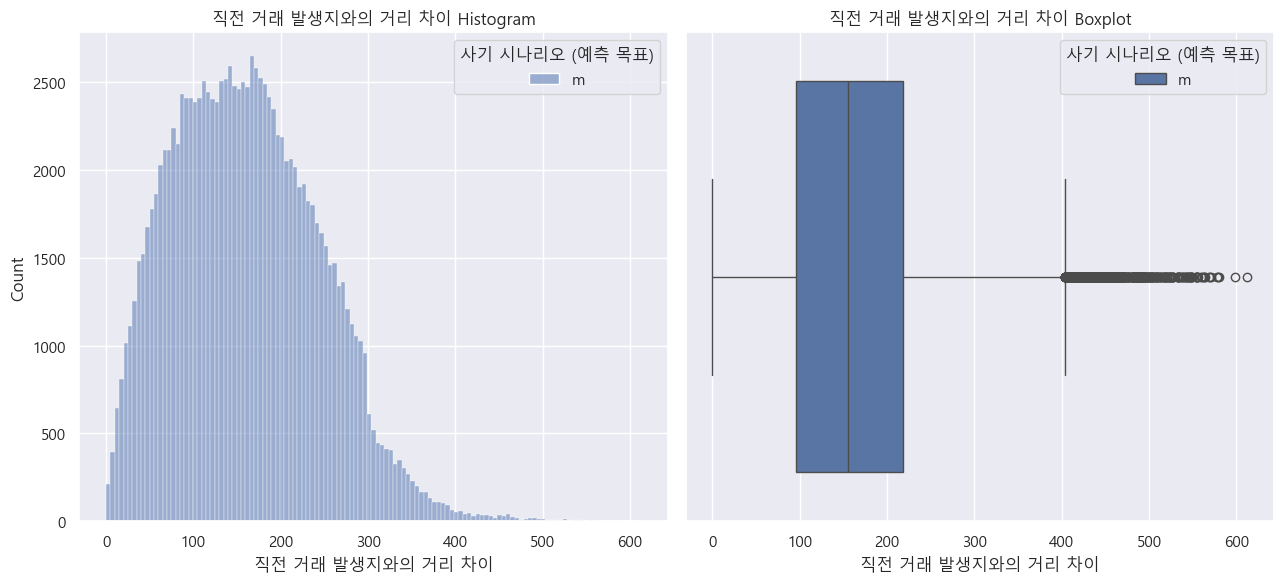

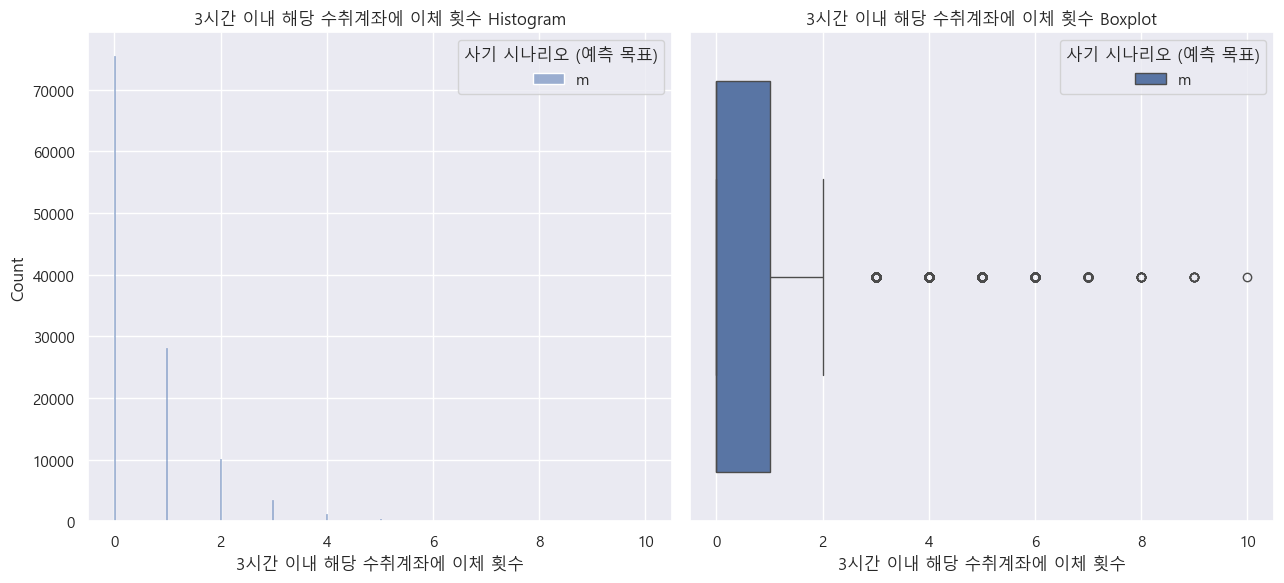

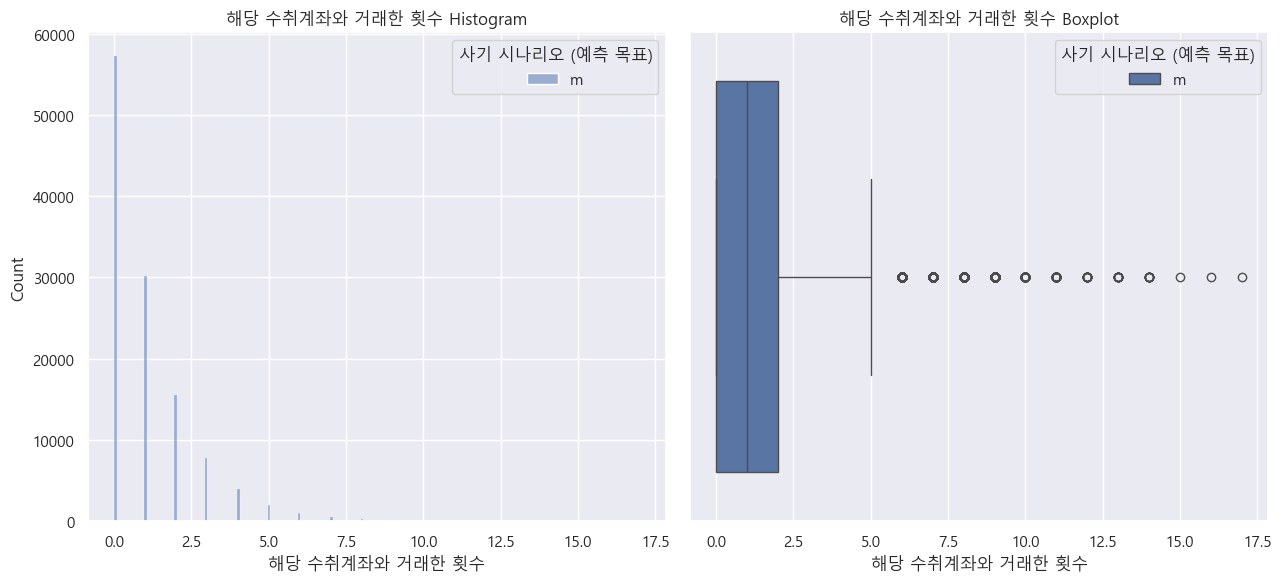

In [109]:
for column, col_type in zip(cond_all['항목 설명'], cond_all['데이터 형태']):

    if col_type == '수치형' and column != '직전 거래와의 시간 차이':

       fig, ax = plt.subplots(ncols=2, figsize=(13, 6))

       sns.histplot(data=train_all_re_m,
                    x=column,
                    hue='사기 시나리오 (예측 목표)',
                    ax=ax[0])
       ax[0].set_title(f'{column} Histogram')

       sns.boxplot(data=train_all_re_m,
                   x=column,
                   hue='사기 시나리오 (예측 목표)',
                   ax=ax[1])
       ax[1].set_title(f'{column} Boxplot')

       plt.tight_layout()
       plt.show()

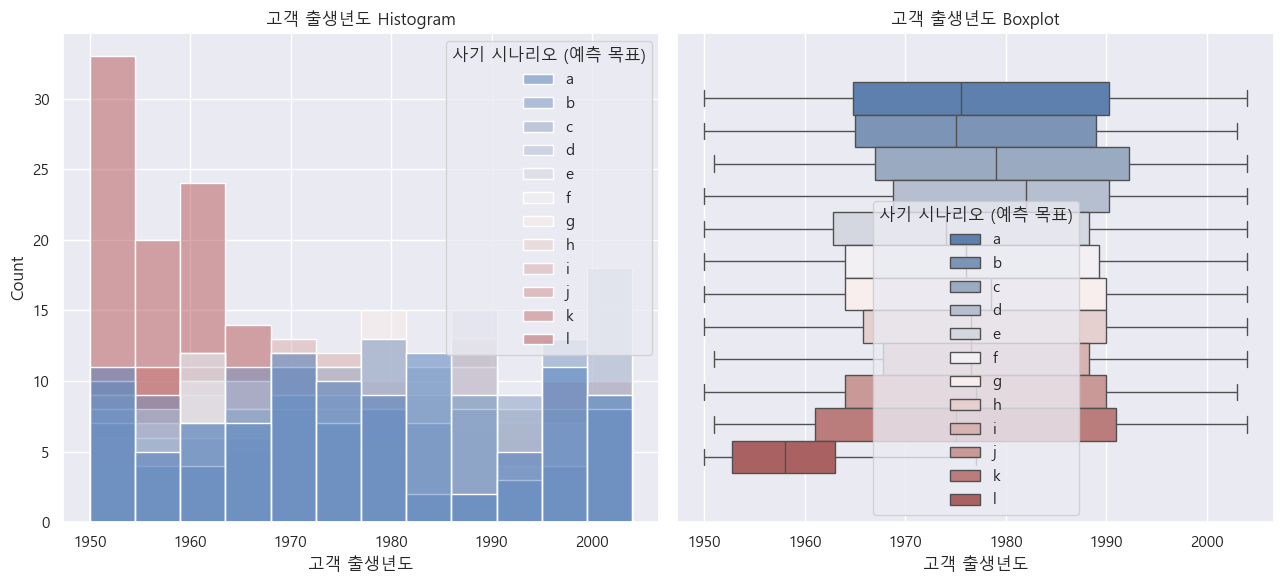

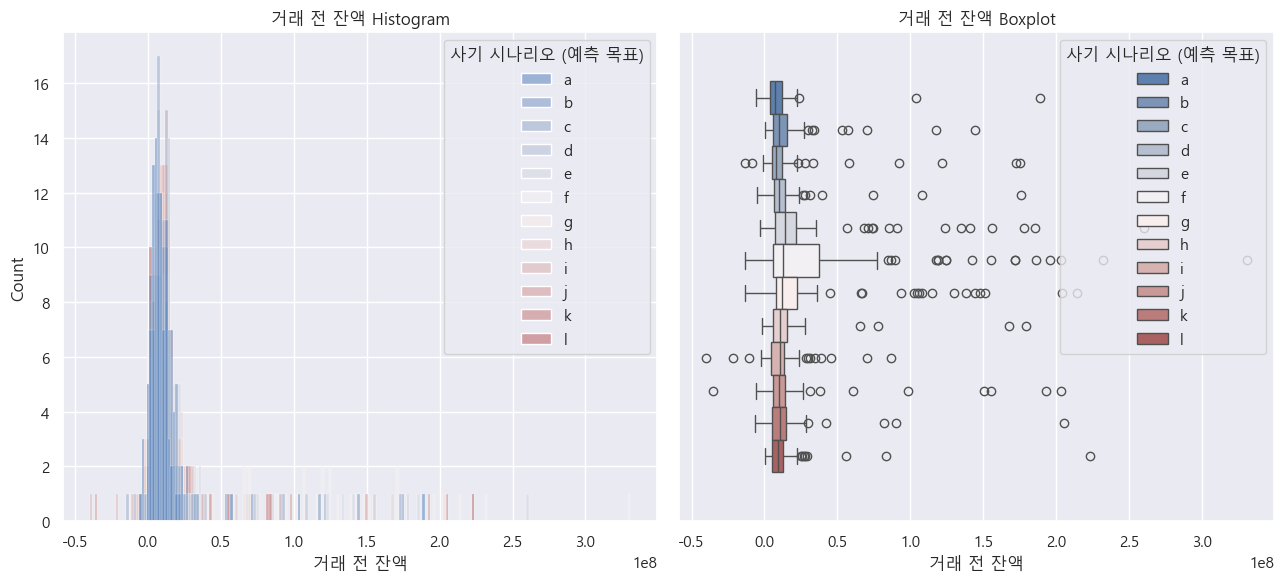

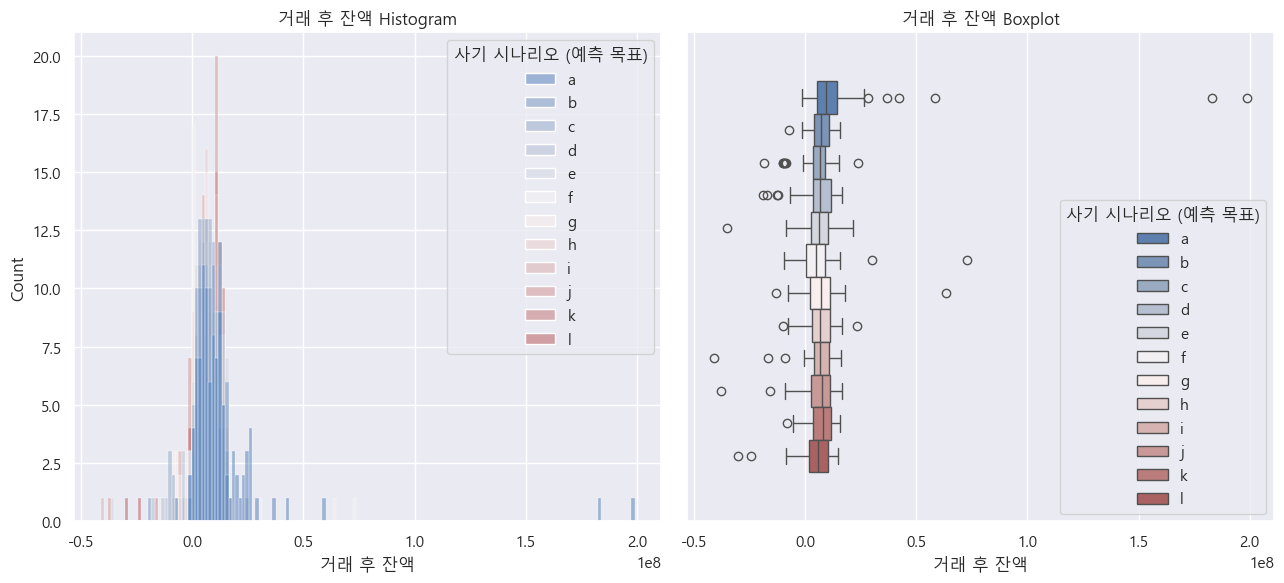

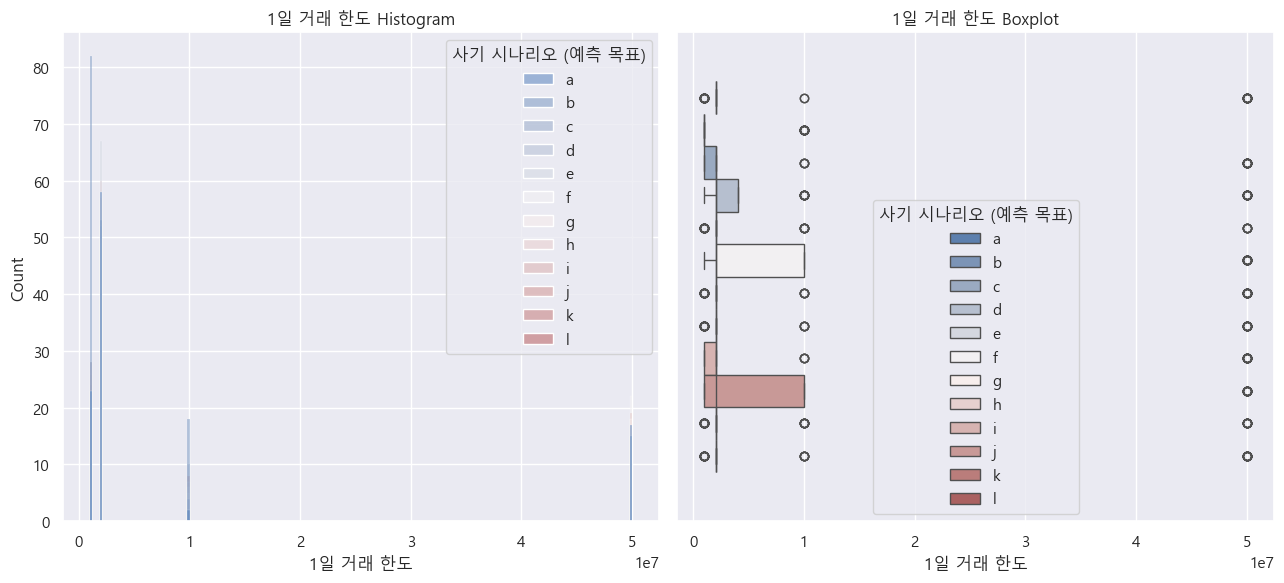

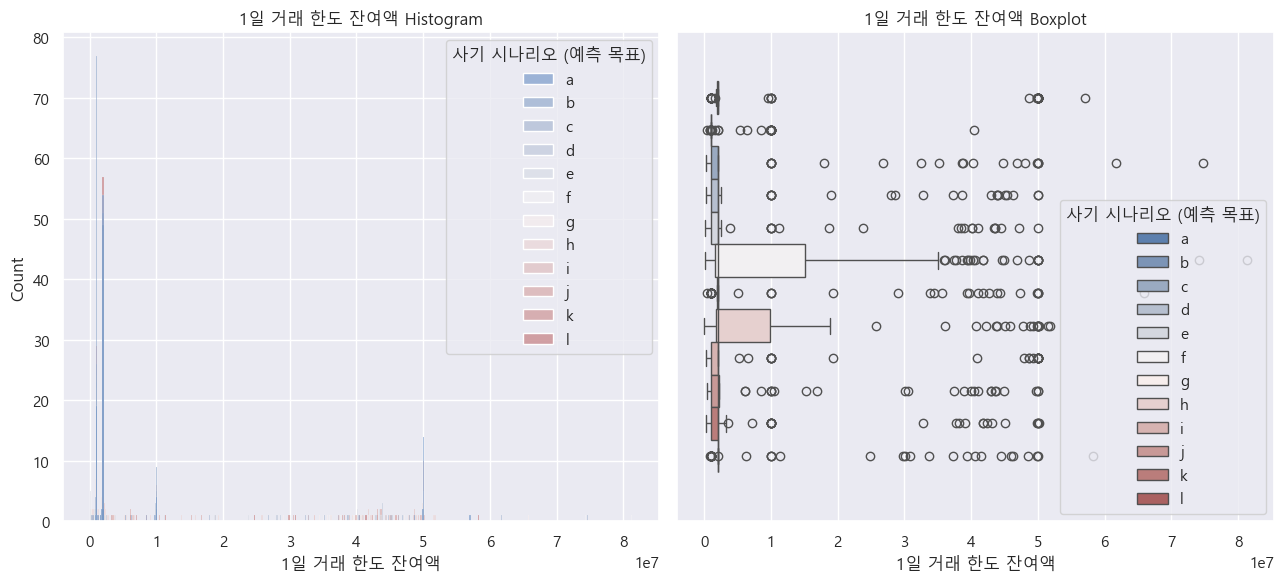

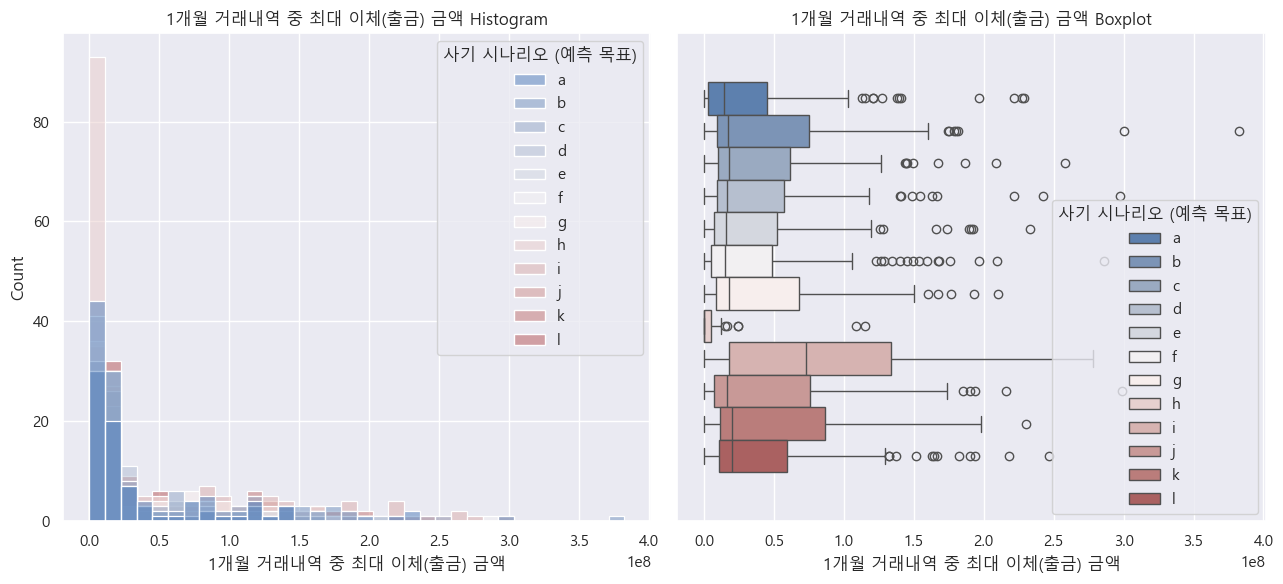

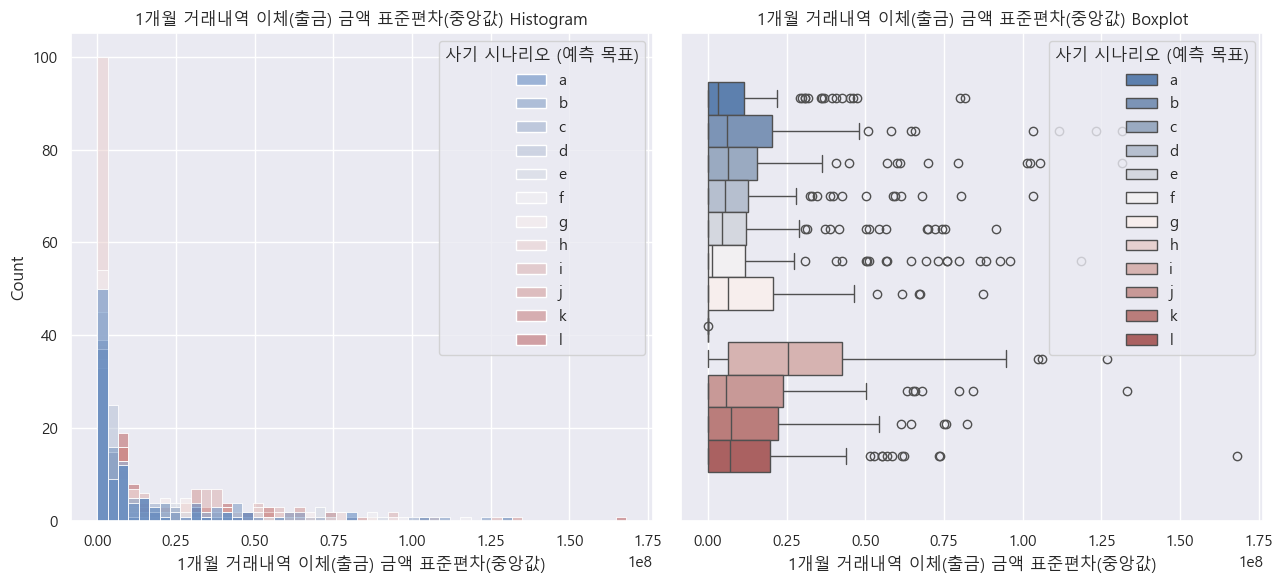

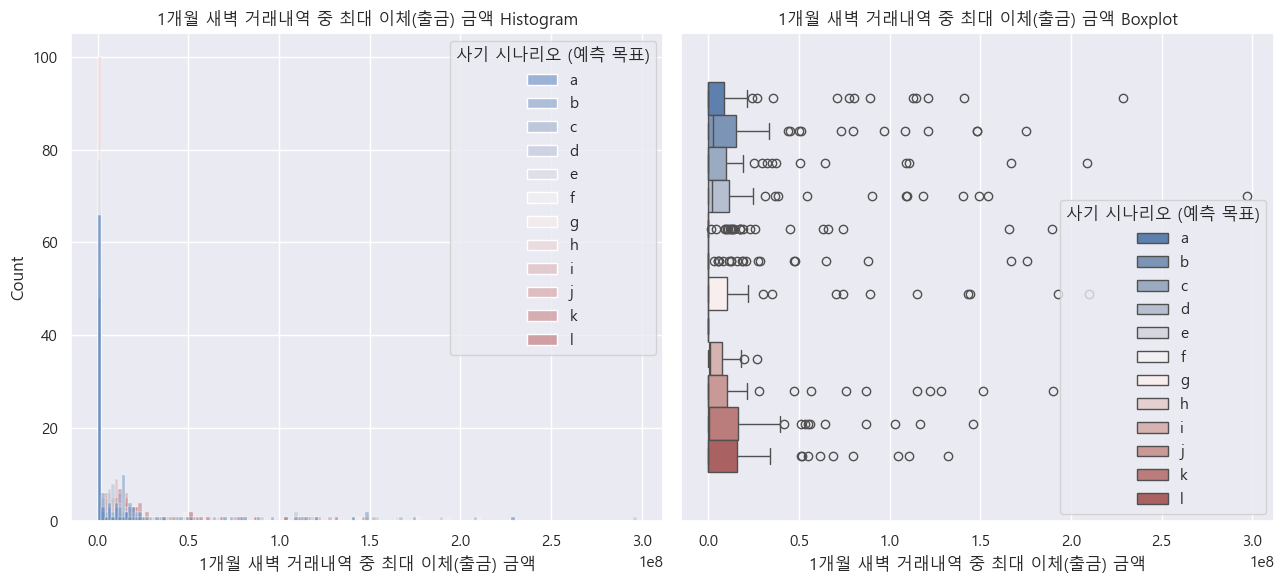

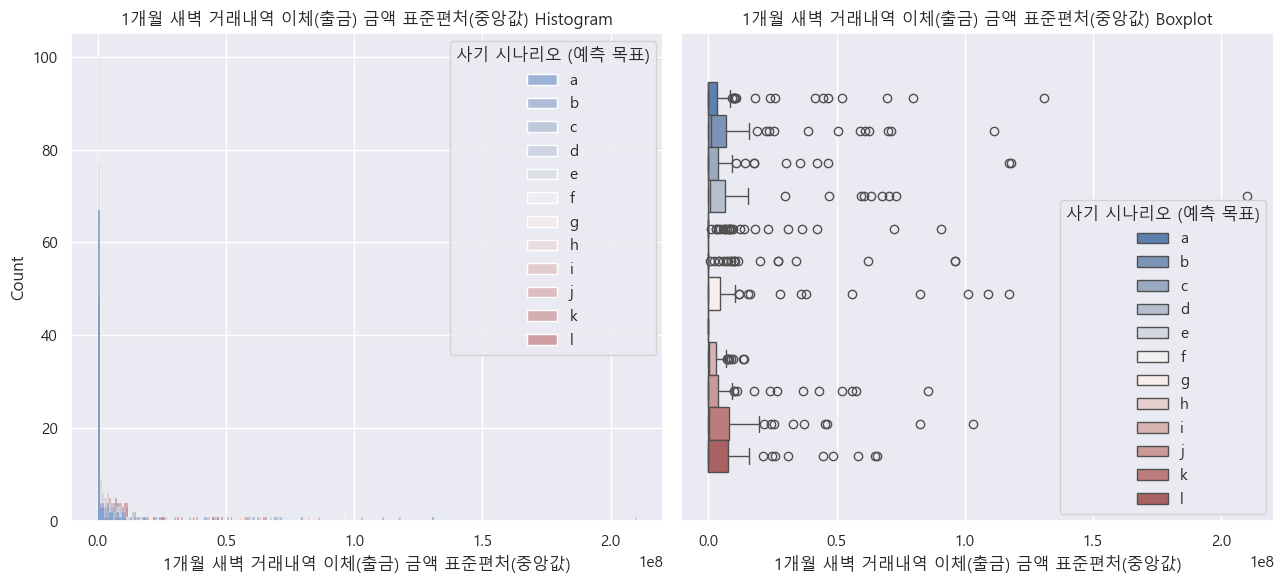

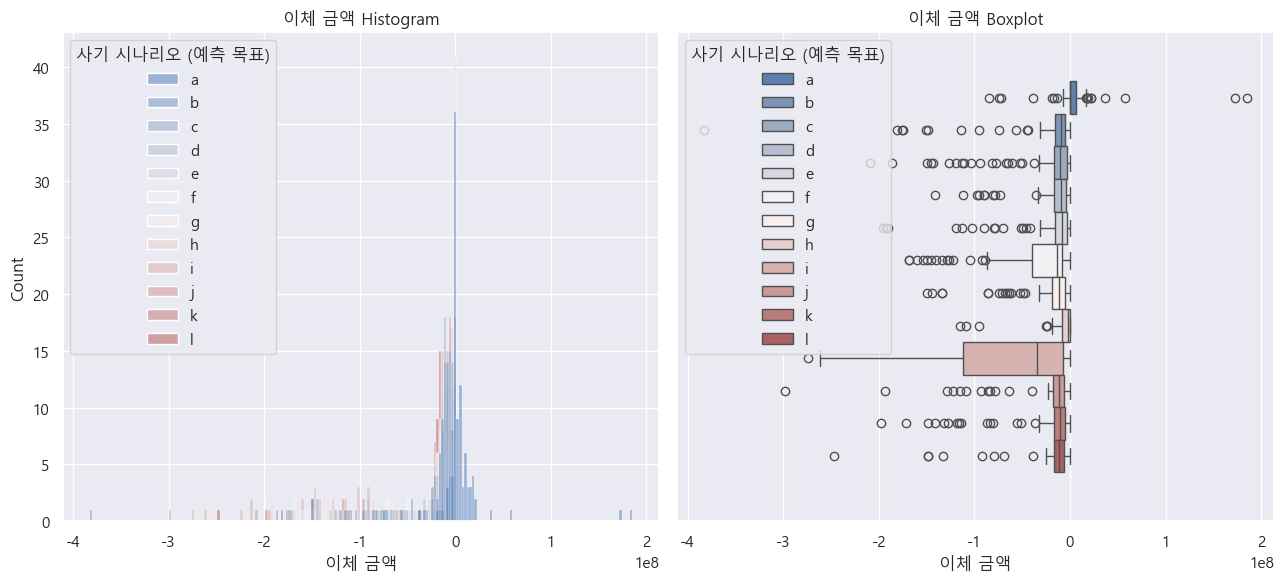

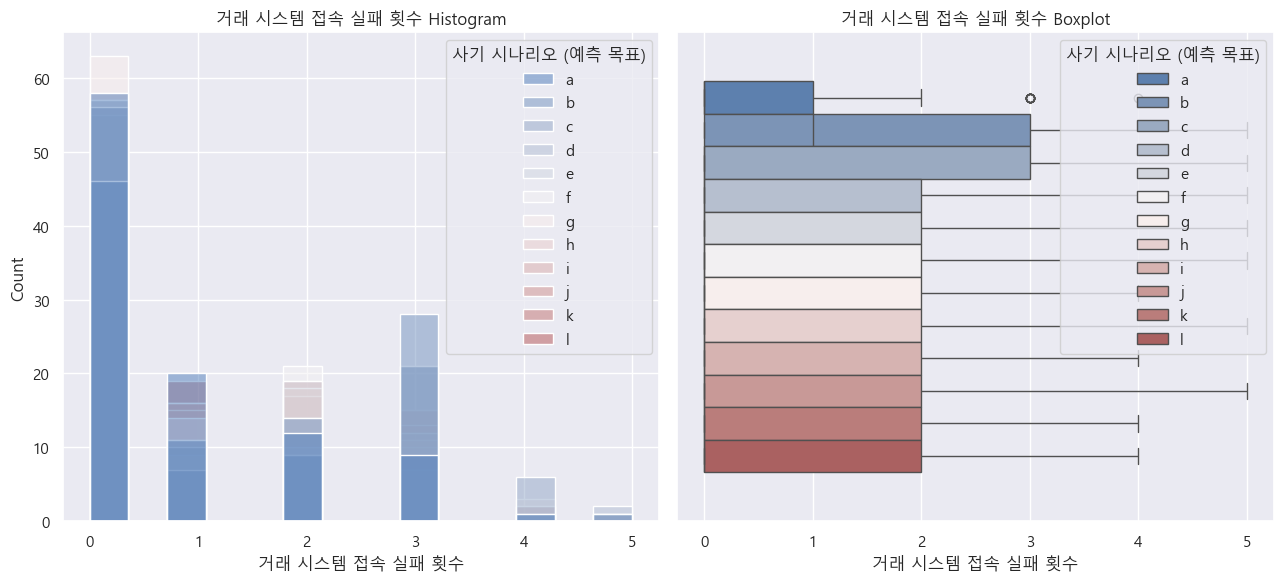

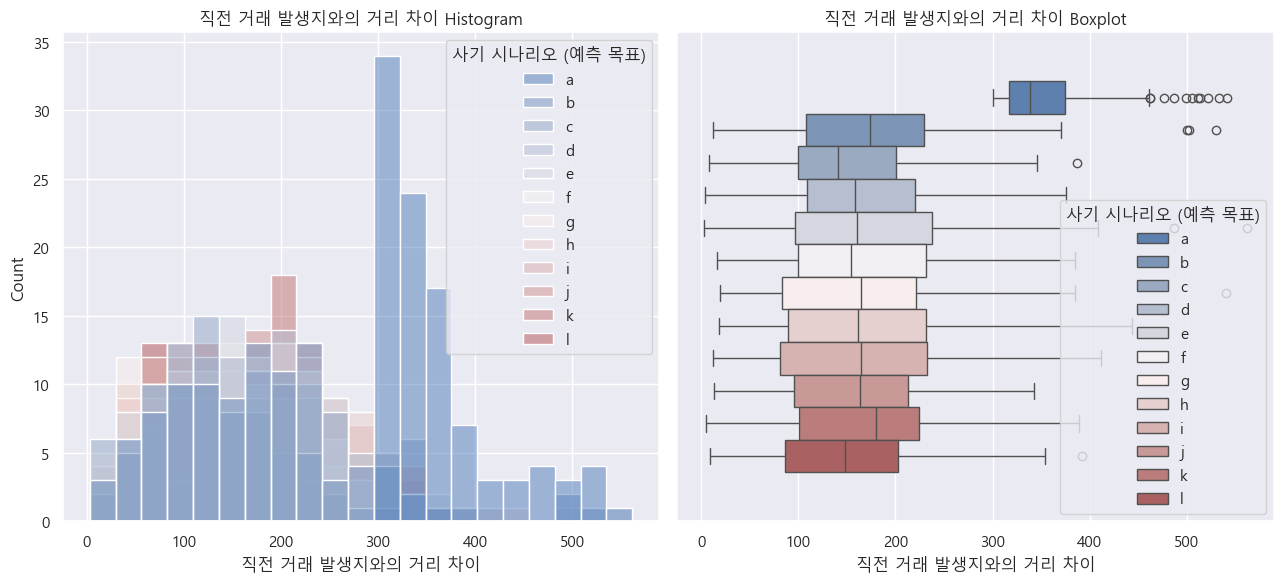

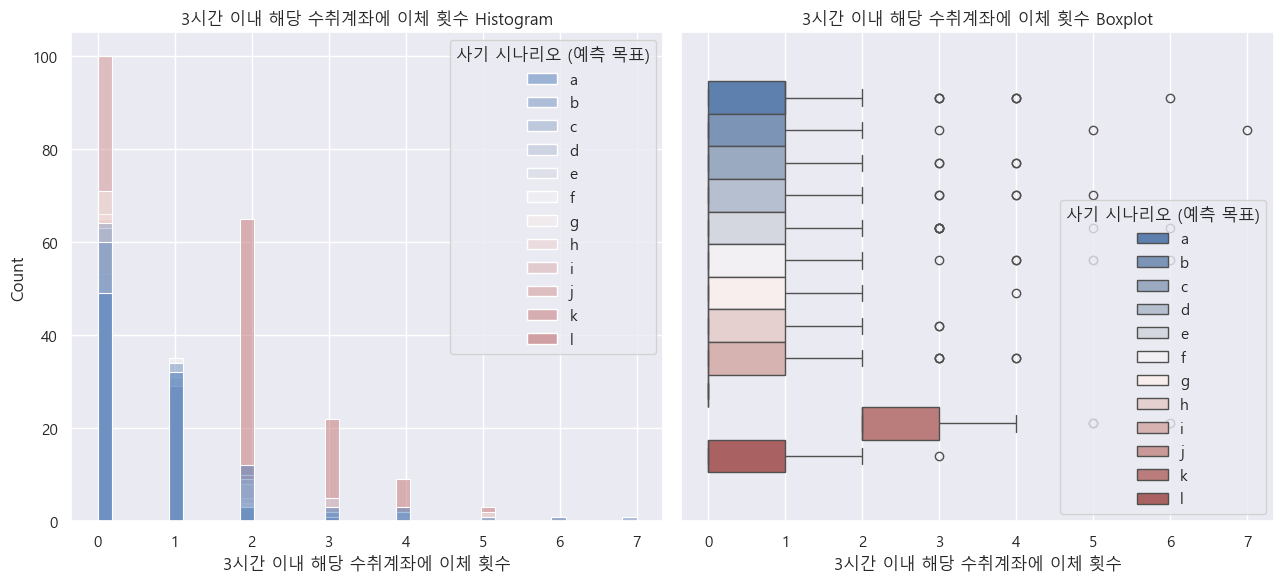

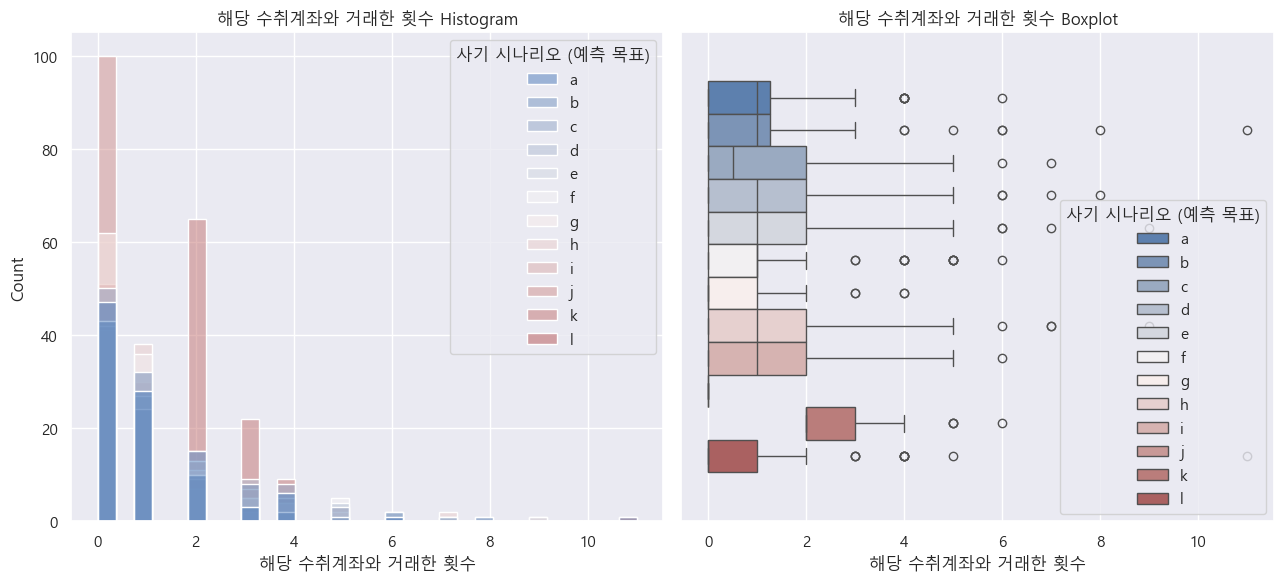

In [110]:
for column, col_type in zip(cond_all['항목 설명'], cond_all['데이터 형태']):

    if col_type == '수치형' and column != '직전 거래와의 시간 차이':

       fig, ax = plt.subplots(ncols=2, figsize=(13, 6))

       sns.histplot(data=train_all_re_non_m,
                    x=column,
                    hue='사기 시나리오 (예측 목표)',
                    palette='vlag',
                    hue_order=hue_order,
                    ax=ax[0])
       ax[0].set_title(f'{column} Histogram')

       sns.boxplot(data=train_all_re_non_m,
                   x=column,
                   hue='사기 시나리오 (예측 목표)',
                   palette='vlag',
                    hue_order=hue_order,
                   ax=ax[1])
       ax[1].set_title(f'{column} Boxplot')

       plt.tight_layout()
       plt.show()